# Cruz Azul — Análisis Inteligente Liga MX
## 10 Preguntas de Negocio: Cruz Azul y la Liga MX

**Fuentes:** `master_jugadores.parquet` (1 150 jugadores × 38 cols) + `master_partidos.parquet` (4 080 partidos × 19 cols)

| # | Pregunta | Tipo |
|---|----------|------|
| P1 | ¿Cuánto vale un jugador de Cruz Azul vs perfiles similares? | Descriptivo |
| P2 | Evolución del valor de plantilla: Cruz Azul vs América vs Rayados | Descriptivo |
| P3 | ¿Cruz Azul rinde mejor en casa que fuera? | Descriptivo |
| P4 | Extranjeros vs nacionales dentro del club | Descriptivo |
| P5 | Equipos con mayor brecha FIFA vs Transfermarkt (talento oculto) | Descriptivo |
| P6 | Probabilidad de transferencia de jugadores | **Predictivo** |
| P7 | Valor de mercado esperado dado rendimiento FIFA | **Predictivo** |
| P8 | Predicción de resultado de partidos Cruz Azul | **Predictivo** |
| P9 | Mejor mediocampista disponible ≤ 3 M USD para Cruz Azul | Prescriptivo |
| P10 | Debilidades tácticas de Cruz Azul y perfil a fichar | Prescriptivo |

In [20]:
# ── Dependencias ──────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ──────────────────────────────────────────────────────────────────────
BASE = 'C:/Users/Unredeemer/Desktop/Proyecto_Final_Calidad'
df       = pd.read_parquet(os.path.join(BASE, 'datos_master', 'master_jugadores.parquet'))
partidos = pd.read_parquet(os.path.join(BASE, 'datos_master', 'master_partidos.parquet'))

# ── Helpers de filtrado por equipo ─────────────────────────────────────────────
def es_ca(s):  return s.str.contains('Cruz Azul',         case=False, na=False)
def es_am(s):  return s.str.contains('Am.rica',            case=False, na=False, regex=True)
def es_ray(s): return s.str.contains('Monterrey|Rayados', case=False, na=False, regex=True)

CA = df[es_ca(df['equipo_norm'])].copy()

print('Jugadores cargados :', df.shape)
print('Partidos  cargados :', partidos.shape)
print('Cruz Azul — registros en dataset:', len(CA))
n_eq = df['equipo_norm'].nunique()
print('Equipos únicos:', n_eq)
temps = sorted(df['season_year'].dropna().unique().astype(int).tolist())
print('Temporadas disponibles:', temps)
print('Columnas jugadores:', list(df.columns))

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Unredeemer/Desktop/Proyecto_Final_Calidad\\datos_master\\master_jugadores.parquet'

---
## P1 — ¿Cuánto vale un jugador de Cruz Azul respecto a perfiles similares en la liga?
> **Método:** Percentiles de valor de mercado por posición + percentil de FIFA Overall de cada jugador de Cruz Azul dentro de su posición.  
> **Visualización:** Boxplots por posición con jugadores Cruz Azul como puntos rojos + barras de percentil.

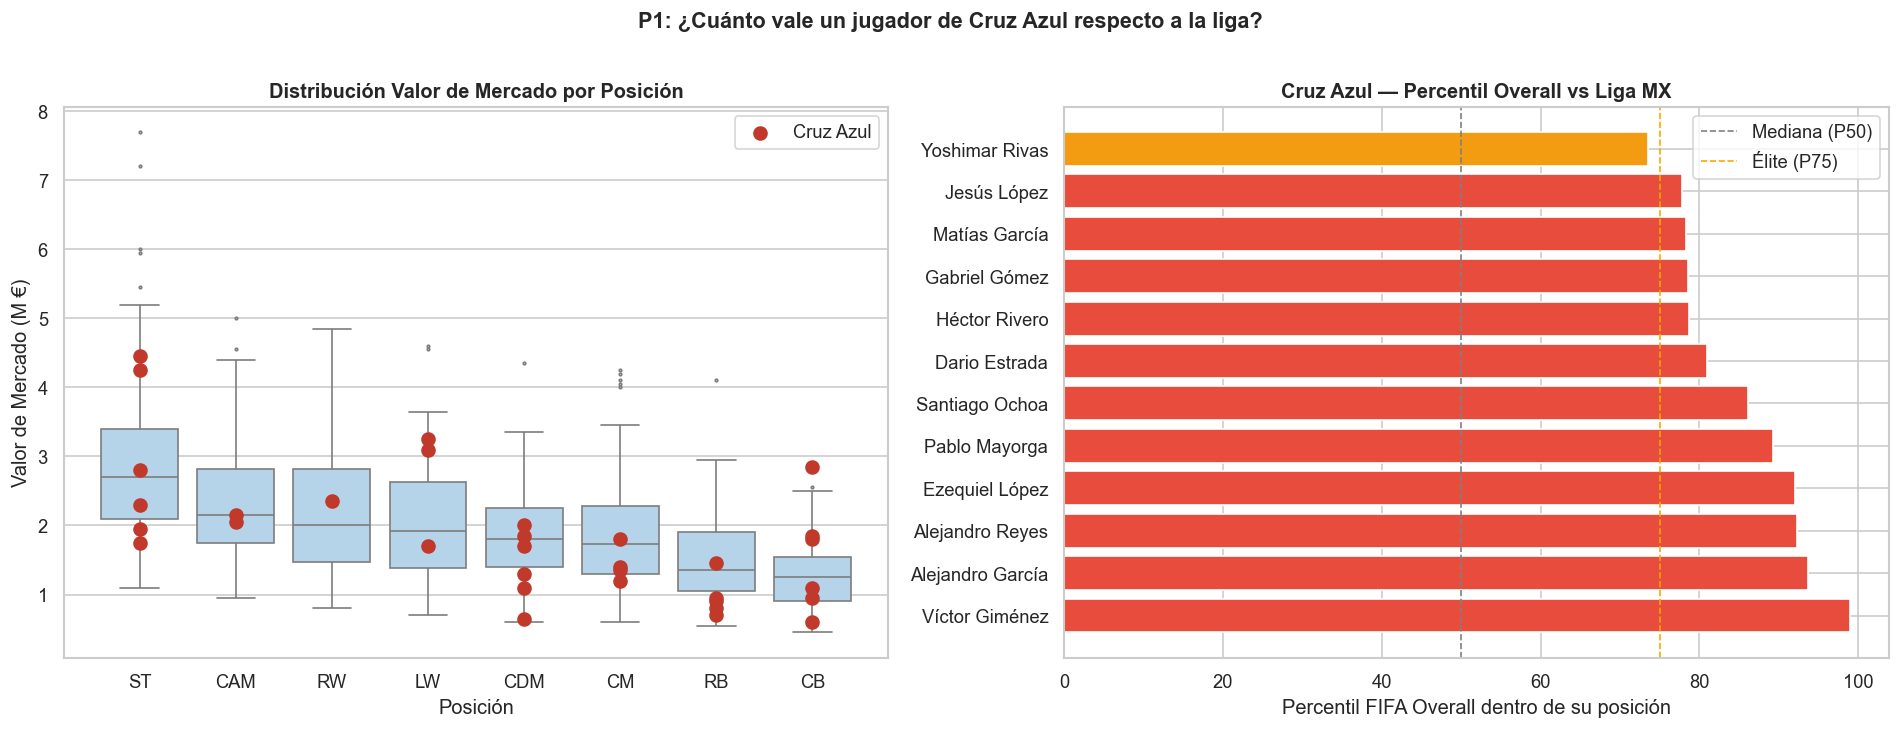


=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===
         Jugador Pos  Edad  Overall Valor Mercado  Percentil
  Víctor Giménez  LW    35       84     EUR 3.1 M       98.9
Alejandro García  CM    32       83           N/A       93.7
 Alejandro Reyes  SS    33       83    EUR 3.35 M       92.3
  Ezequiel López  LW    34       82     EUR 1.7 M       92.0
   Pablo Mayorga  CM    33       82     EUR 1.4 M       89.2
  Santiago Ochoa  RB    36       81    EUR 0.95 M       86.1
   Dario Estrada  GK    25       83    EUR 1.75 M       81.0
   Héctor Rivero  ST    25       78           N/A       78.7
   Gabriel Gómez  LM    31       78     EUR 2.4 M       78.5
   Matías García  LB    23       79     EUR 1.8 M       78.3
     Jesús López  GK    17       82     EUR 1.1 M       77.8
  Yoshimar Rivas CDM    36       78     EUR 1.3 M       73.5
Santiago Vázquez  CB    26       79     EUR 1.8 M       73.3
Héctor Fernández  LW    22       76    EUR 3.25 M       70.5
    Diego García CDM    20       77 

In [ ]:
# P1 — Valor relativo de jugadores Cruz Azul
df_v = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()
df_v['vm_m'] = df_v['valor_mercado_eur'] / 1e6

top_pos = df_v['posicion'].value_counts().head(8).index.tolist()
df_v8   = df_v[df_v['posicion'].isin(top_pos)]
ca_v    = df_v8[es_ca(df_v8['equipo_norm'])]

order = df_v8.groupby('posicion')['vm_m'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Boxplot valor de mercado
ax = axes[0]
sns.boxplot(data=df_v8, x='posicion', y='vm_m', order=order,
            color='#AED6F1', fliersize=1.5, ax=ax)
added_label = False
for _, row in ca_v.iterrows():
    if row['posicion'] in order:
        idx = order.index(row['posicion'])
        label = 'Cruz Azul' if not added_label else ''
        ax.scatter(idx, row['vm_m'], color='#C0392B', s=60, zorder=5, label=label)
        added_label = True
ax.set_title('Distribución Valor de Mercado por Posición', fontweight='bold')
ax.set_xlabel('Posición')
ax.set_ylabel('Valor de Mercado (M €)')
ax.legend(loc='upper right')

# ── Percentil FIFA Overall de jugadores Cruz Azul
df_ov = df[df['fifa_overall'].notna()].copy()
ca_ov = df_ov[es_ca(df_ov['equipo_norm'])].copy()

def calc_percentil(row, ref):
    peers = ref.loc[ref['posicion'] == row['posicion'], 'fifa_overall'].dropna()
    return round((peers < row['fifa_overall']).mean() * 100, 1) if len(peers) > 1 else np.nan

ca_ov['pctil'] = ca_ov.apply(lambda r: calc_percentil(r, df_ov), axis=1)
top12 = ca_ov.nlargest(12, 'pctil')[['nombre_canonico', 'posicion', 'fifa_overall', 'pctil']].dropna()

ax2 = axes[1]
colors = ['#E74C3C' if p >= 75 else '#F39C12' if p >= 50 else '#3498DB'
          for p in top12['pctil']]
ax2.barh(top12['nombre_canonico'], top12['pctil'], color=colors)
ax2.axvline(50, color='gray', ls='--', lw=1, label='Mediana (P50)')
ax2.axvline(75, color='orange', ls='--', lw=1, label='Élite (P75)')
ax2.set_xlabel('Percentil FIFA Overall dentro de su posición')
ax2.set_title('Cruz Azul — Percentil Overall vs Liga MX', fontweight='bold')
ax2.legend()

fig.suptitle('P1: ¿Cuánto vale un jugador de Cruz Azul respecto a la liga?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Tabla resumen
print('\n=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===')
tabla = ca_ov[['nombre_canonico', 'posicion', 'edad', 'fifa_overall',
               'valor_mercado_eur', 'pctil']].dropna(subset=['pctil'])
tabla = tabla.sort_values('pctil', ascending=False).copy()
tabla['valor_mercado_eur'] = tabla['valor_mercado_eur'].apply(
    lambda x: ('EUR ' + str(round(x / 1e6, 2)) + ' M') if pd.notna(x) else 'N/A')
tabla.columns = ['Jugador', 'Pos', 'Edad', 'Overall', 'Valor Mercado', 'Percentil']
print(tabla.head(15).to_string(index=False))

---
## P2 — ¿Cómo ha evolucionado el valor de mercado total de la plantilla temporada a temporada?
> **Método:** Serie de tiempo del valor acumulado de plantilla por temporada para Cruz Azul, América y Rayados. Variación porcentual entre temporadas.  
> **Visualización:** Líneas de tiempo superpuestas + barras de variación porcentual.

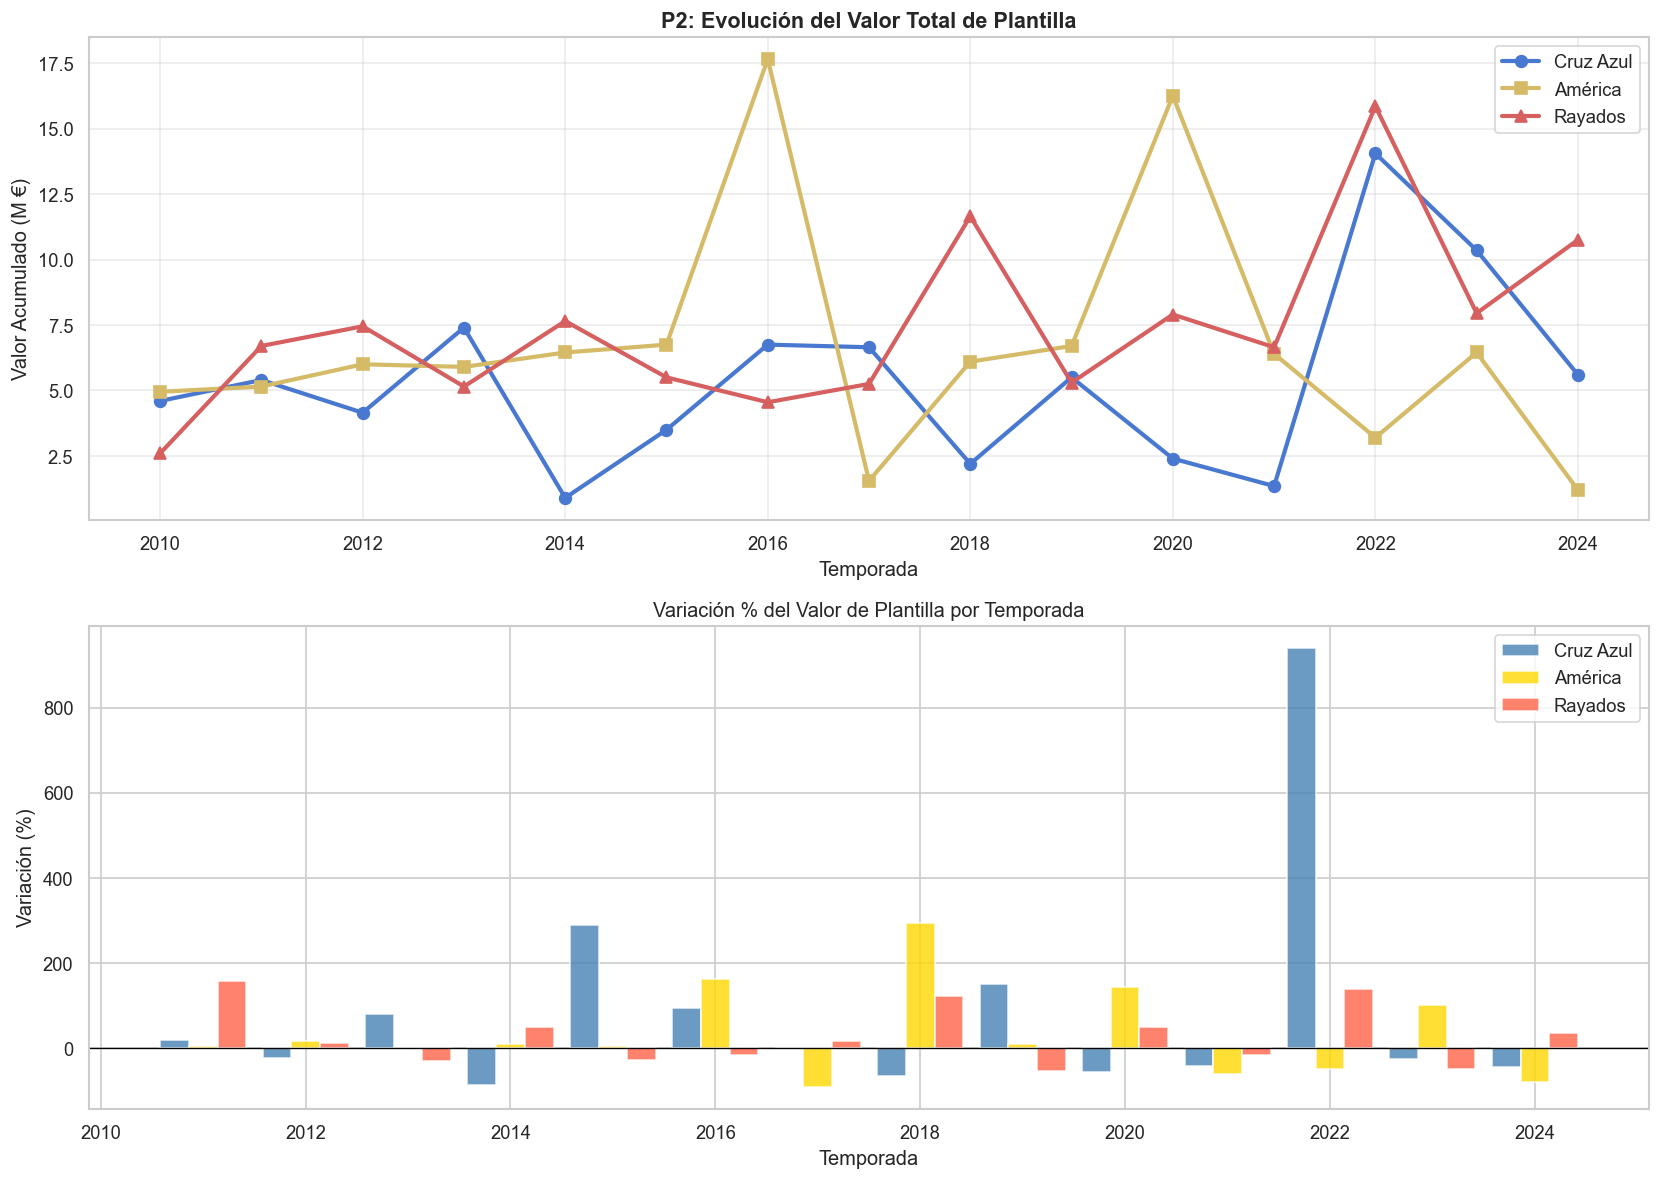


=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===
             Cruz Azul  América  Rayados
season_year                             
2010               4.6      5.0      2.6
2011               5.4      5.2      6.7
2012               4.2      6.0      7.4
2013               7.4      5.9      5.2
2014               0.9      6.4      7.6
2015               3.5      6.8      5.5
2016               6.8     17.6      4.6
2017               6.6      1.6      5.2
2018               2.2      6.1     11.6
2019               5.5      6.7      5.3
2020               2.4     16.2      7.9
2021               1.4      6.4      6.6
2022              14.0      3.2     15.8
2023              10.4      6.4      8.0
2024               5.6      1.2     10.8

=== VARIACIÓN PORCENTUAL ===
             Cruz Azul  América  Rayados
season_year                             
2011              17.4      4.0    157.7
2012             -23.1     16.5     11.2
2013              78.3     -1.7    -30.9
2014        

In [ ]:
# P2 — Evolución del valor de mercado total de plantilla
df_p2 = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()

def valor_por_temporada(mask):
    return df_p2[mask].groupby('season_year')['valor_mercado_eur'].sum() / 1e6

ca_val  = valor_por_temporada(es_ca(df_p2['equipo_norm']))
am_val  = valor_por_temporada(es_am(df_p2['equipo_norm']))
ray_val = valor_por_temporada(es_ray(df_p2['equipo_norm']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Serie de tiempo
ax1.plot(ca_val.index,  ca_val.values,  'b-o', label='Cruz Azul', lw=2.5, ms=7)
ax1.plot(am_val.index,  am_val.values,  'y-s', label='América',   lw=2.5, ms=7)
ax1.plot(ray_val.index, ray_val.values, 'r-^', label='Rayados',   lw=2.5, ms=7)
ax1.set_title('P2: Evolución del Valor Total de Plantilla', fontsize=13, fontweight='bold')
ax1.set_xlabel('Temporada')
ax1.set_ylabel('Valor Acumulado (M €)')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Variación porcentual
ca_pct  = ca_val.pct_change() * 100
am_pct  = am_val.pct_change() * 100
ray_pct = ray_val.pct_change() * 100

w = 0.28
idx_ca  = ca_pct.dropna().index
idx_am  = am_pct.dropna().index
idx_ray = ray_pct.dropna().index

ax2.bar(ca_pct.dropna().index - w, ca_pct.dropna().values, w,
        label='Cruz Azul', color='steelblue', alpha=0.8)
ax2.bar(am_pct.dropna().index,     am_pct.dropna().values, w,
        label='América',   color='gold', alpha=0.8)
ax2.bar(ray_pct.dropna().index + w, ray_pct.dropna().values, w,
        label='Rayados',   color='tomato', alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Variación % del Valor de Plantilla por Temporada', fontsize=12)
ax2.set_xlabel('Temporada')
ax2.set_ylabel('Variación (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print('\n=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===')
resumen = pd.DataFrame({'Cruz Azul': ca_val, 'América': am_val, 'Rayados': ray_val})
print(resumen.round(1).to_string())

print('\n=== VARIACIÓN PORCENTUAL ===')
resumen_pct = pd.DataFrame({'Cruz Azul': ca_pct, 'América': am_pct, 'Rayados': ray_pct})
print(resumen_pct.round(1).dropna().to_string())

---
## P3 — ¿Cruz Azul rinde mejor en casa que fuera? ¿Cómo se compara con la liga?
> **Método:** Puntos por partido (PPP) en casa y fuera para cada equipo. Ranking de ventaja local.  
> **Visualización:** Barras agrupadas (casa vs fuera) + ranking de ventaja local.

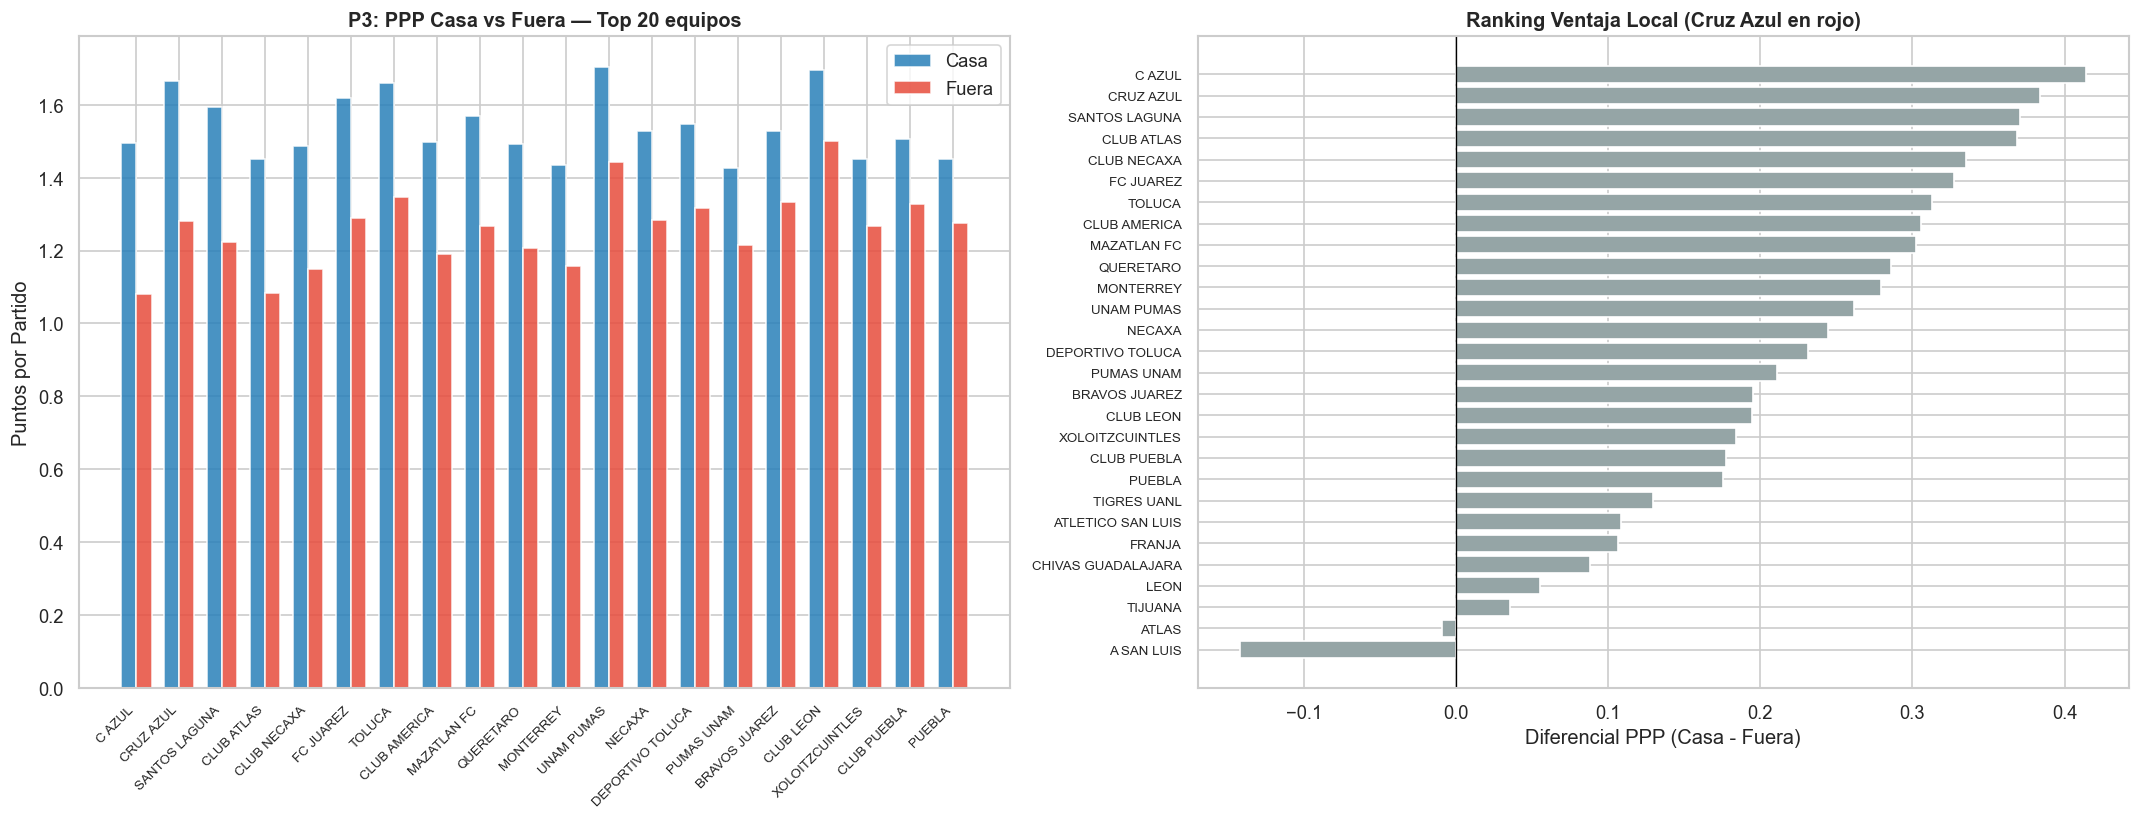

In [ ]:
# P3 — Rendimiento en casa vs fuera

def puntos_local(res):
    if res == 'W': return 3
    if res == 'D': return 1
    return 0

def puntos_visitante(res):
    if res == 'L': return 3
    if res == 'D': return 1
    return 0

partidos_clean = partidos[partidos['resultado_local'].isin(['W', 'D', 'L'])].copy()
partidos_clean['pts_local']     = partidos_clean['resultado_local'].map(puntos_local)
partidos_clean['pts_visitante'] = partidos_clean['resultado_local'].map(puntos_visitante)

ppp_home = (partidos_clean.groupby('equipo_local_norm')['pts_local']
            .mean().rename('Casa'))
ppp_away = (partidos_clean.groupby('equipo_visitante_norm')['pts_visitante']
            .mean().rename('Fuera'))

ventaja = pd.concat([ppp_home, ppp_away], axis=1).dropna()
ventaja['Ventaja'] = ventaja['Casa'] - ventaja['Fuera']
ventaja = ventaja.sort_values('Ventaja', ascending=False)

# ── Posición Cruz Azul
ca_teams = [t for t in ventaja.index if 'Cruz' in str(t)]
if ca_teams:
    ca_team  = ca_teams[0]
    ca_rank  = int(ventaja['Ventaja'].rank(ascending=False)[ca_team])
    n_eq_p3  = len(ventaja)
    print('Cruz Azul PPP Casa :', round(ventaja.loc[ca_team, 'Casa'], 3))
    print('Cruz Azul PPP Fuera:', round(ventaja.loc[ca_team, 'Fuera'], 3))
    print('Ventaja Local      :', round(ventaja.loc[ca_team, 'Ventaja'], 3))
    print('Ranking en liga    :', ca_rank, 'de', n_eq_p3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ── Barras agrupadas top 20
top20 = ventaja.head(20)
x = np.arange(len(top20))
w = 0.35
bar_h = ax1.bar(x - w/2, top20['Casa'],  w, label='Casa',  color='#2980B9', alpha=0.85)
bar_a = ax1.bar(x + w/2, top20['Fuera'], w, label='Fuera', color='#E74C3C', alpha=0.85)
for i, team in enumerate(top20.index):
    if 'Cruz' in str(team):
        ax1.bar(i - w/2, top20.loc[team, 'Casa'],  w, color='navy',    alpha=1.0)
        ax1.bar(i + w/2, top20.loc[team, 'Fuera'], w, color='darkred', alpha=1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
ax1.set_title('P3: PPP Casa vs Fuera — Top 20 equipos', fontweight='bold')
ax1.set_ylabel('Puntos por Partido')
ax1.legend()

# ── Ranking ventaja local (todos los equipos)
v_sorted = ventaja.sort_values('Ventaja', ascending=True)
bar_colors = ['#E74C3C' if 'Cruz' in str(t) else '#95A5A6' for t in v_sorted.index]
ax2.barh(range(len(v_sorted)), v_sorted['Ventaja'], color=bar_colors)
ax2.set_yticks(range(len(v_sorted)))
ax2.set_yticklabels(v_sorted.index, fontsize=8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Ranking Ventaja Local (Cruz Azul en rojo)', fontweight='bold')
ax2.set_xlabel('Diferencial PPP (Casa - Fuera)')

plt.tight_layout()
plt.show()

# ── Análisis por Apertura / Clausura
if 'half' in partidos_clean.columns:
    for torneo in ['Apertura', 'Clausura']:
        sub = partidos_clean[partidos_clean['season'].str.contains(torneo, na=False)]
        if len(sub) > 0 and ca_teams:
            h_ca = sub[sub['equipo_local_norm'] == ca_team]['pts_local'].mean()
            a_ca = sub[sub['equipo_visitante_norm'] == ca_team]['pts_visitante'].mean()
            print(torneo, '— Casa:', round(h_ca, 3), '| Fuera:', round(a_ca, 3))

---
## P4 — ¿Cuáles son las métricas de los jugadores extranjeros vs nacionales de Cruz Azul?
> **Método:** Comparar valor de mercado, FIFA Overall y G+A/90 entre extranjeros y nacionales en Cruz Azul; contrastar con la liga.  
> **Visualización:** Donut de composición + barras comparativas.

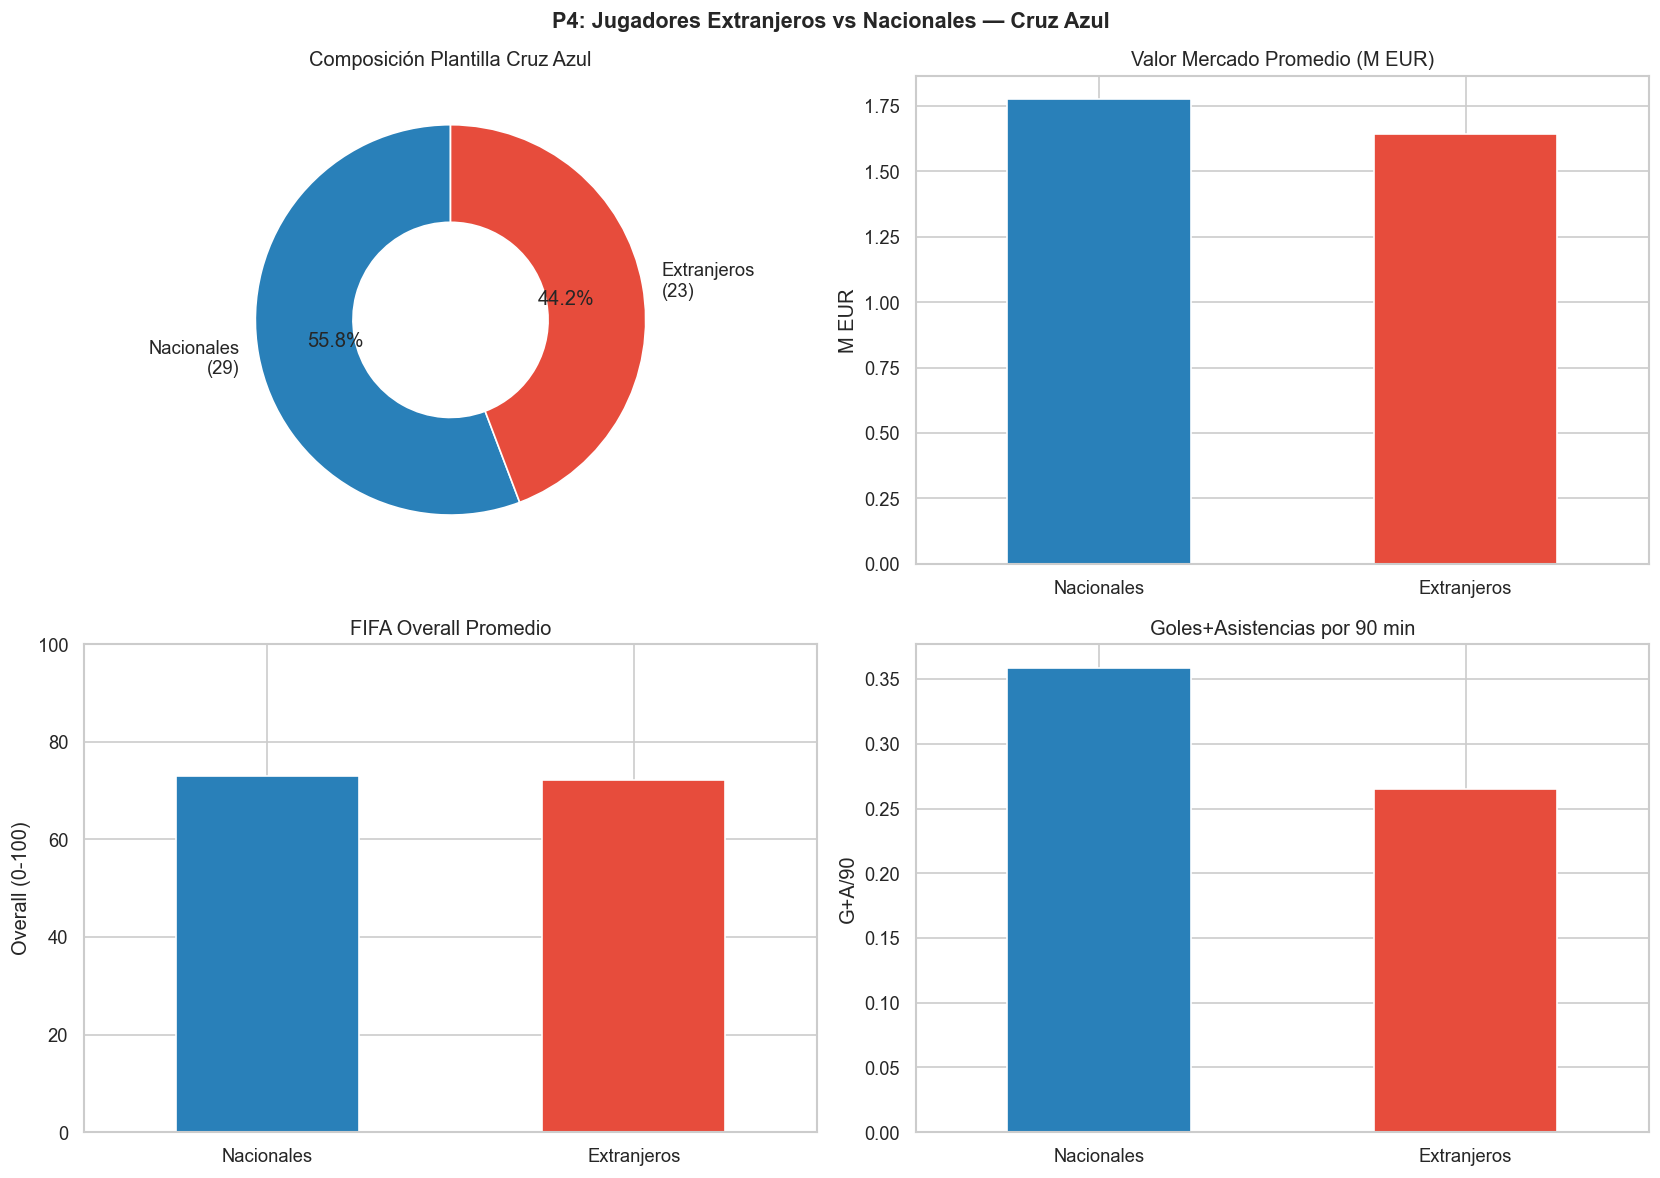


=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===
                      n  overall  valor_m  ga90
posicion extran                                
CAM      Nacionales   1    66.00     2.15  3.05
         Extranjeros  1    69.00     2.05  0.00
CB       Nacionales   4    71.75     1.30  0.13
         Extranjeros  2    73.00     1.98  0.16
CDM      Nacionales   3    70.67     1.50  0.20
         Extranjeros  3    71.33     1.37  0.41
CM       Nacionales   3    78.67     1.60  0.21
         Extranjeros  3    66.67     1.27  0.09
GK       Nacionales   4    78.50     1.19  0.07
         Extranjeros  2    79.50     1.42  0.21
LB       Nacionales   2    66.50     0.82  0.20
         Extranjeros  1    79.00     1.80  0.00
LM       Extranjeros  1    78.00     2.40  0.36
LW       Nacionales   1    84.00     3.10  0.13
         Extranjeros  3    76.33     2.48  0.59
RB       Nacionales   2    72.50     0.92  0.08
         Extranjeros  3    70.67     0.98  0.17
RM       Nacionales   2    66.50  

In [ ]:
# P4 — Extranjeros vs nacionales
CA4 = df[es_ca(df['equipo_norm'])].copy()
CA4['extran'] = CA4['es_extranjero'].fillna(False)

ext_count = int(CA4['extran'].sum())
nac_count = int((~CA4['extran']).sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Donut composición
ax = axes[0, 0]
ax.pie([nac_count, ext_count],
       labels=[f'Nacionales\n({nac_count})', f'Extranjeros\n({ext_count})'],
       colors=['#2980B9', '#E74C3C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(width=0.5))
ax.set_title('Composición Plantilla Cruz Azul')

def media_seg(df_in, col):
    return df_in.groupby('extran')[col].mean()

def plot_bar_p4(ax, serie, title, ylabel, fmt=None):
    serie.index = ['Nacionales', 'Extranjeros']
    serie.plot(kind='bar', ax=ax, color=['#2980B9', '#E74C3C'], rot=0)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

# ── Valor mercado promedio
vm_ser = (CA4.groupby('extran')['valor_mercado_eur']
          .mean().fillna(0) / 1e6)
plot_bar_p4(axes[0, 1], vm_ser, 'Valor Mercado Promedio (M EUR)', 'M EUR')

# ── FIFA Overall promedio
ov_ser = media_seg(CA4, 'fifa_overall').fillna(0)
plot_bar_p4(axes[1, 0], ov_ser, 'FIFA Overall Promedio', 'Overall (0-100)')
axes[1, 0].set_ylim(0, 100)

# ── G+A por 90 min
ga_ser = media_seg(CA4, 'g_a_por_90').fillna(0)
plot_bar_p4(axes[1, 1], ga_ser, 'Goles+Asistencias por 90 min', 'G+A/90')

fig.suptitle('P4: Jugadores Extranjeros vs Nacionales — Cruz Azul',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabla comparativa por posición
print('\n=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===')
tabla_pos = CA4.groupby(['posicion', 'extran']).agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
tabla_pos.index = tabla_pos.index.set_levels(
    ['Nacionales', 'Extranjeros'], level=1)
print(tabla_pos.to_string())

# ── Comparativa vs liga
print('\n=== LIGA MX: EXTRANJEROS vs NACIONALES ===')
liga_comp = df.copy()
liga_comp['extran'] = liga_comp['es_extranjero'].fillna(False)
liga_agg = liga_comp.groupby('extran').agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.dropna().mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
liga_agg.index = ['Nacionales', 'Extranjeros']
print(liga_agg.to_string())

---
## P5 — ¿Qué equipos presentan mayor brecha entre valoración FIFA y valor Transfermarkt?
> **Método:** Normalizar FIFA Overall y log(Valor TM) a rango 0-1. Calcular brecha = FIFA_norm − TM_norm. Agregar por equipo.  
> **Visualización:** Scatter FIFA vs TM + ranking de 'talento oculto' por equipo.

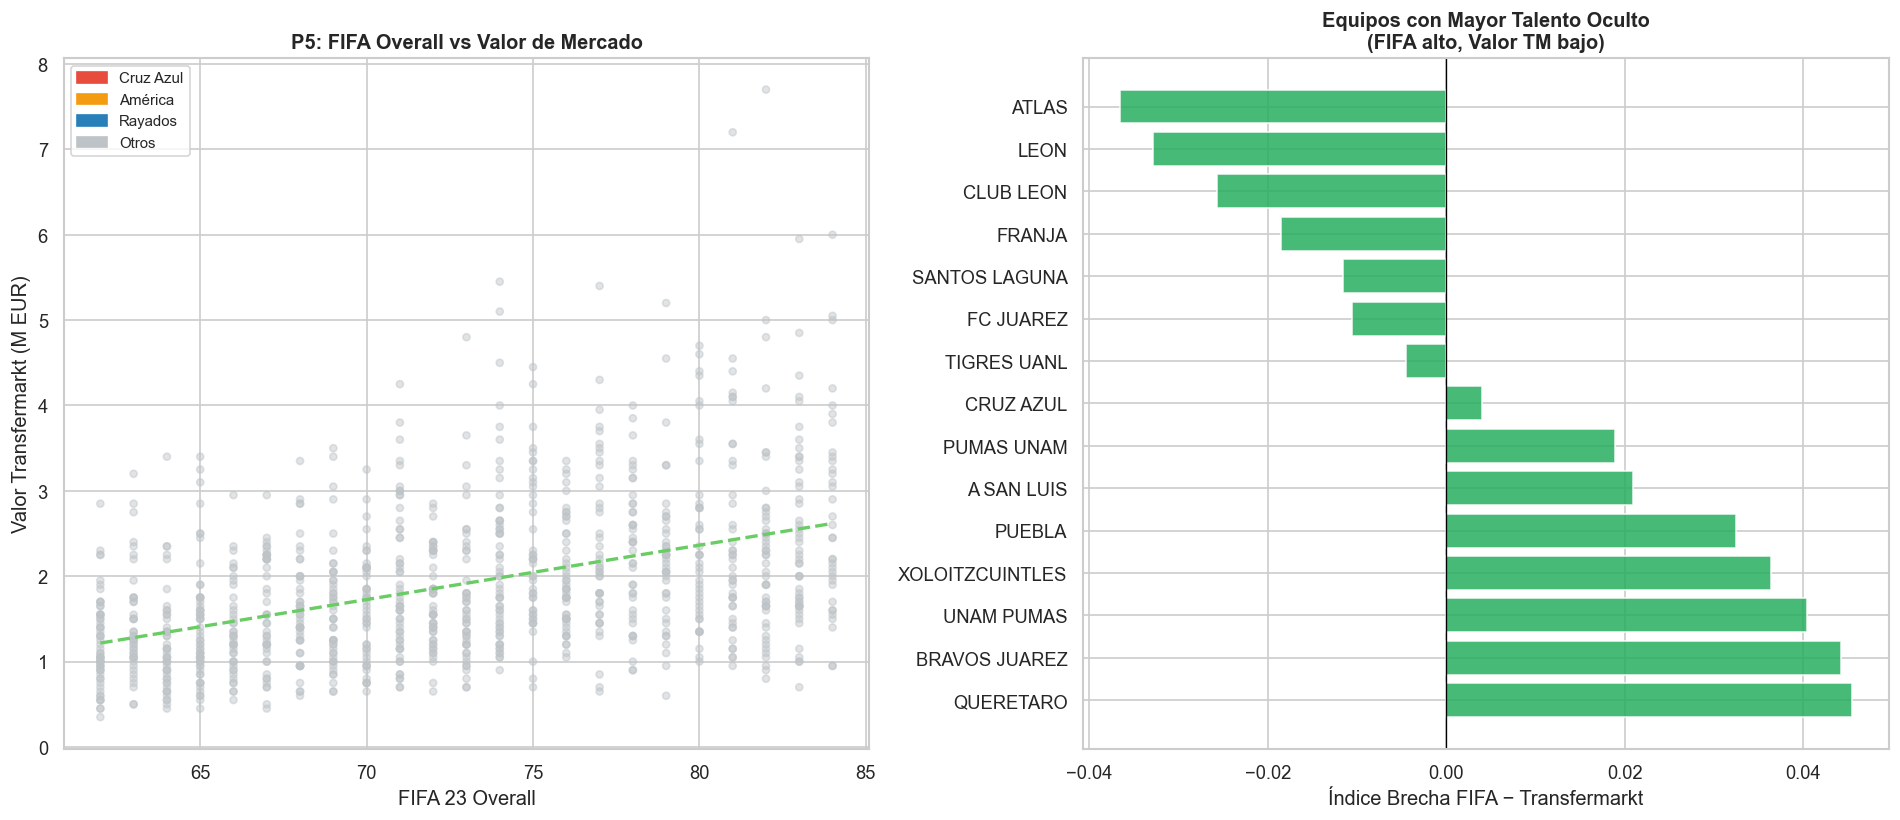


=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===
    equipo_norm  brecha_media  n  overall_prom  vm_prom
      QUERETARO         0.045 68        74.544    1.906
  BRAVOS JUAREZ         0.044 24        73.167    1.610
     UNAM PUMAS         0.040 21        74.857    2.145
XOLOITZCUINTLES         0.036 23        73.696    1.865
         PUEBLA         0.032 19        72.316    1.508
     A SAN LUIS         0.021 20        72.950    1.678
     PUMAS UNAM         0.019 22        74.000    2.011
      CRUZ AZUL         0.004 47        72.553    1.719
    TIGRES UANL        -0.005 70        73.357    2.014
      FC JUAREZ        -0.011 49        73.163    1.958

=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===
    nombre_canonico   equipo_norm posicion  fifa_overall  valor_mercado_eur  brecha
Sebastián Rodríguez BRAVOS JUAREZ       GK            83               0.70   0.730
     Fernando Ochoa          LEON       CB            84               0.95   0.677
      Rodrigo Pérez     QU

In [ ]:
# P5 — Brecha FIFA vs Transfermarkt (talento oculto)
df_p5 = df[df['valor_mercado_eur'].notna() &
           df['fifa_overall'].notna() &
           (df['valor_mercado_eur'] > 0)].copy()

scaler = MinMaxScaler()
df_p5['ov_norm'] = scaler.fit_transform(df_p5[['fifa_overall']])
log_val = np.log1p(df_p5['valor_mercado_eur']).values.reshape(-1, 1)
df_p5['vm_norm'] = scaler.fit_transform(log_val)
df_p5['brecha']  = df_p5['ov_norm'] - df_p5['vm_norm']  # + = FIFA alto, TM bajo → subvalorado

# ── Por equipo
team_brecha = (df_p5.groupby('equipo_norm')
               .agg(brecha_media=('brecha', 'mean'),
                    n=('nombre_canonico', 'count'),
                    overall_prom=('fifa_overall', 'mean'),
                    vm_prom=('valor_mercado_eur', lambda x: x.mean() / 1e6))
               .reset_index())
team_brecha = team_brecha[team_brecha['n'] >= 5].sort_values('brecha_media', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Scatter: FIFA Overall vs Valor TM por jugador
def color_team(t):
    if 'Cruz' in str(t): return '#E74C3C'
    if 'América' in str(t) or 'America' in str(t): return '#F39C12'
    if 'Monterrey' in str(t) or 'Rayados' in str(t): return '#2980B9'
    return '#BDC3C7'

dot_colors = df_p5['equipo_norm'].apply(color_team)
ax1.scatter(df_p5['fifa_overall'], df_p5['valor_mercado_eur'] / 1e6,
            c=dot_colors, alpha=0.45, s=18)

z = np.polyfit(df_p5['fifa_overall'], df_p5['valor_mercado_eur'] / 1e6, 1)
x_line = np.linspace(df_p5['fifa_overall'].min(), df_p5['fifa_overall'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), 'g--', lw=2, label='Tendencia liga')
ax1.set_xlabel('FIFA 23 Overall')
ax1.set_ylabel('Valor Transfermarkt (M EUR)')
ax1.set_title('P5: FIFA Overall vs Valor de Mercado', fontweight='bold')
legend_elem = [
    mpatches.Patch(color='#E74C3C', label='Cruz Azul'),
    mpatches.Patch(color='#F39C12', label='América'),
    mpatches.Patch(color='#2980B9', label='Rayados'),
    mpatches.Patch(color='#BDC3C7', label='Otros'),
]
ax1.legend(handles=legend_elem, fontsize=9)

# ── Ranking de brecha por equipo
top_b = team_brecha.head(15)
bar_bc = ['#E74C3C' if 'Cruz' in str(t) else '#27AE60' for t in top_b['equipo_norm']]
ax2.barh(top_b['equipo_norm'], top_b['brecha_media'], color=bar_bc, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Equipos con Mayor Talento Oculto\n(FIFA alto, Valor TM bajo)', fontweight='bold')
ax2.set_xlabel('Índice Brecha FIFA − Transfermarkt')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===')
print(team_brecha[['equipo_norm', 'brecha_media', 'n', 'overall_prom', 'vm_prom']]
      .head(10).round(3).to_string(index=False))

# ── Top 10 jugadores subvalorados en Liga MX
top_jug = df_p5.nlargest(10, 'brecha')[['nombre_canonico', 'equipo_norm',
                                          'posicion', 'fifa_overall',
                                          'valor_mercado_eur', 'brecha']].copy()
top_jug['valor_mercado_eur'] = top_jug['valor_mercado_eur'] / 1e6
print('\n=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===')
print(top_jug.round(3).to_string(index=False))

---
## P6 — ¿Qué jugadores de Liga MX tienen mayor probabilidad de ser transferidos?
> **Método:** Modelo Random Forest. Target: cambio de equipo entre temporadas consecutivas. Features: edad, overall, valor mercado, goles, asistencias, minutos, G+A/90.  
> **Evaluación:** AUC-ROC + Feature Importance.

Features usadas: ['edad', 'fifa_overall', 'valor_mercado_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90']
Distribución target — No Transferido: 797 | Transferido: 280
AUC-ROC en test: 0.4921


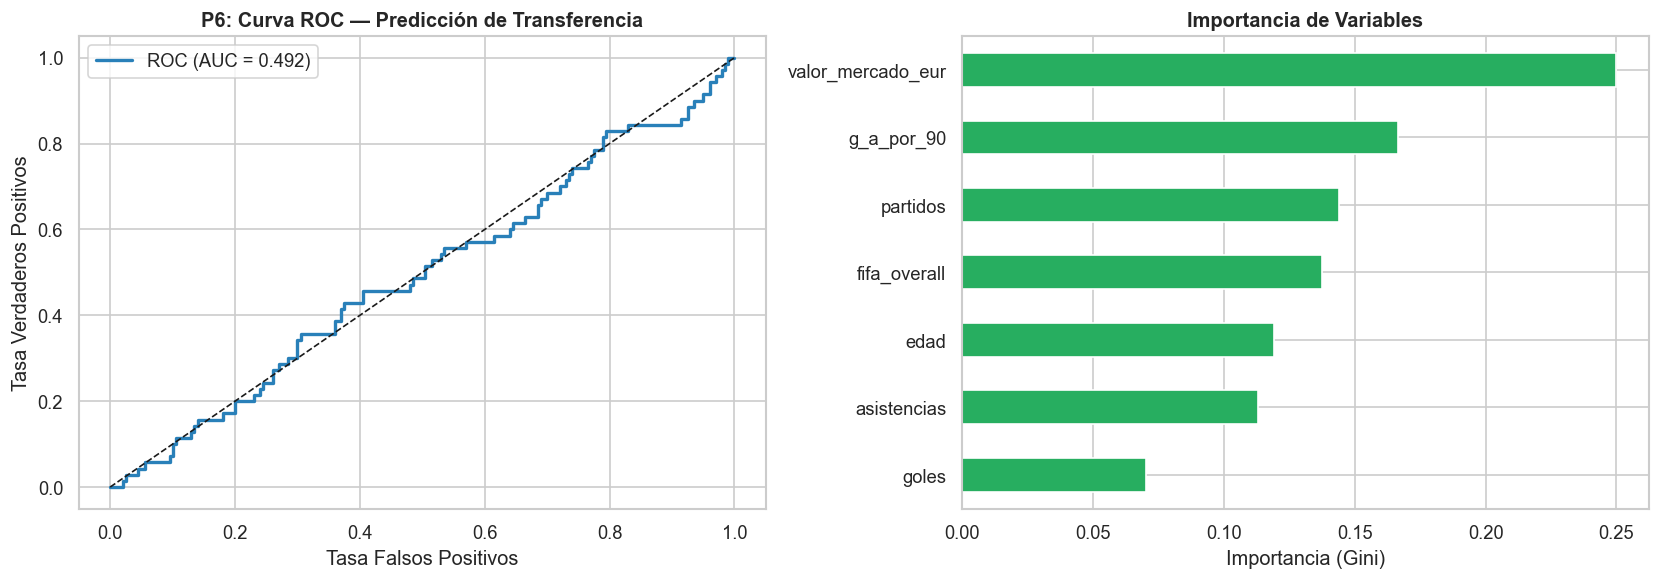


=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===
   nombre_canonico     equipo_norm posicion  prob_transfer
       Lucas Lotti     CLUB NECAXA       CM          0.633
     Pablo Vázquez      UNAM PUMAS      CDM          0.614
      Ramón Flores           ATLAS       CM          0.611
       Jesús López       CRUZ AZUL       GK          0.606
       André Pérez       QUERETARO       RB          0.597
     Matías Flores     TIGRES UANL       RW          0.596
 Guillermo Vázquez         TIJUANA       RM          0.594
      Lucas Suárez XOLOITZCUINTLES       RB          0.594
Alejandro Martínez     CLUB NECAXA       GK          0.589
    Uriel González       QUERETARO       GK          0.586
   Jonathan Castro   BRAVOS JUAREZ       RM          0.582
   César Hernández     MAZATLAN FC      CDM          0.579
     Marco Mayorga       FC JUAREZ       RB          0.577
   Sebastián Gómez   SANTOS LAGUNA       CB          0.576
  Alejandro Castro            LEON       CB      

In [ ]:
# P6 — Probabilidad de transferencia (clasificación binaria)

# ── Crear target: ¿cambia de equipo en la siguiente temporada?
cols_p6 = ['nombre_key', 'season_year', 'equipo_norm', 'edad',
           'fifa_overall', 'valor_mercado_eur', 'goles',
           'asistencias', 'partidos', 'g_a_por_90', 'posicion',
           'nombre_canonico']
df_p6 = df[[c for c in cols_p6 if c in df.columns]].copy()
df_p6 = df_p6.sort_values(['nombre_key', 'season_year'])

df_p6['equipo_next'] = df_p6.groupby('nombre_key')['equipo_norm'].shift(-1)
df_p6['transferido'] = (
    df_p6['equipo_next'].notna() &
    (df_p6['equipo_norm'] != df_p6['equipo_next'])
).astype(int)

features = [f for f in ['edad', 'fifa_overall', 'valor_mercado_eur',
                         'goles', 'asistencias', 'partidos', 'g_a_por_90']
            if f in df_p6.columns]

ml_df = df_p6[features + ['transferido', 'nombre_canonico', 'equipo_norm',
                           'posicion']].dropna(subset=features + ['transferido'])

X = ml_df[features].values
y = ml_df['transferido'].values

print('Features usadas:', features)
print('Distribución target — No Transferido:', (y == 0).sum(), '| Transferido:', (y == 1).sum())

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                             class_weight='balanced')
rf.fit(X_tr, y_tr)
y_prob = rf.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print('AUC-ROC en test:', round(auc, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax1.plot(fpr, tpr, color='#2980B9', lw=2, label='ROC (AUC = ' + str(round(auc, 3)) + ')')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P6: Curva ROC — Predicción de Transferencia', fontweight='bold')
ax1.legend()

# ── Feature importance
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
imp.plot(kind='barh', ax=ax2, color='#27AE60')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

# ── Ranking de probabilidad de transferencia — última temporada por jugador
ml_df2 = df_p6[features + ['nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features)
ml_df2 = ml_df2.copy()
ml_df2['prob_transfer'] = rf.predict_proba(ml_df2[features].values)[:, 1]

last_idx = df_p6.sort_values('season_year').groupby('nombre_key').tail(1).index
candidates = ml_df2.loc[ml_df2.index.isin(last_idx)].sort_values(
    'prob_transfer', ascending=False)

print('\n=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===')
print(candidates[['nombre_canonico', 'equipo_norm', 'posicion', 'prob_transfer']]
      .head(15).round(3).to_string(index=False))

print('\n=== JUGADORES CRUZ AZUL — RANKING DE RIESGO ===')
ca_risk = candidates[es_ca(candidates['equipo_norm'])]
print(ca_risk[['nombre_canonico', 'posicion', 'prob_transfer']].head(10).round(3).to_string(index=False))

---
## P7 — ¿Cuál es el valor de mercado esperado dado el rendimiento real y atributos FIFA?
> **Método:** Gradient Boosting Regressor. Target: log(valor_mercado_eur). Features: overall, potential, edad, posición codificada, goles, asistencias, minutos.  
> **Evaluación:** RMSE, R² + scatter predicho vs real.

RMSE (log-escala): 0.2719
R²              : 0.6953


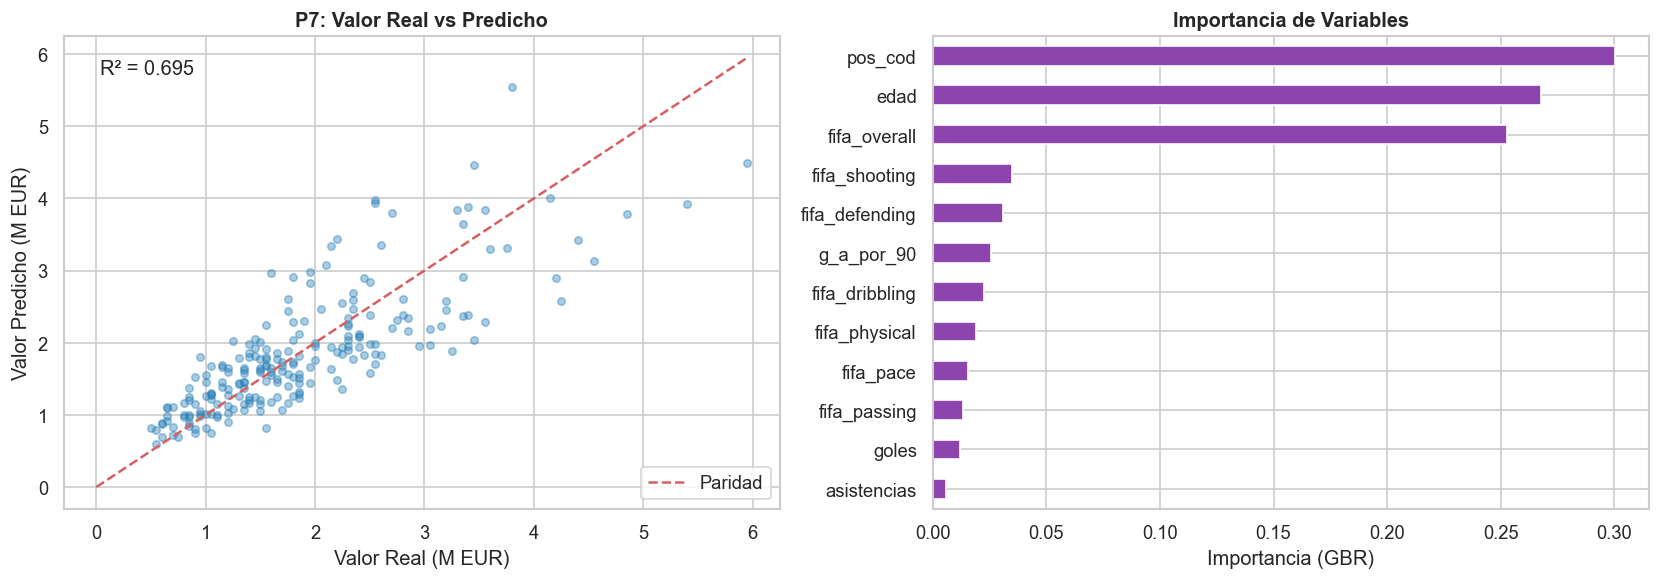


=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===
           Jugador Pos  Overall  Valor Real M  Valor Esperado M  Diferencia M
      Felipe Rivas  RM       66          1.00              1.55          0.55
     Matías García  LB       79          1.80              2.28          0.48
     Jonathan Mora  CM       74          1.20              1.60          0.40
       Luis Moreno  LB       68          0.60              0.89          0.29
      Pablo Torres  RB       71          0.70              0.96          0.26
      Hirving Romo  RM       66          1.35              1.58          0.23
     Pablo Mayorga  CM       82          1.40              1.62          0.22
   Erick Hernández  LB       65          1.05              1.25          0.20
   Nicolás Montoya  GK       76          1.10              1.29          0.19
     Ramón Vázquez  GK       78          0.90              1.08          0.18
    Dario Carneiro CDM       73          1.10              1.27          0.17
  André

In [ ]:
# P7 — Valor de mercado esperado (regresión)
feats7 = ['fifa_overall', 'edad', 'goles', 'asistencias', 'minutos', 'g_a_por_90',
          'fifa_pace', 'fifa_shooting', 'fifa_passing',
          'fifa_dribbling', 'fifa_defending', 'fifa_physical']
feats7_present = [f for f in feats7 if f in df.columns]

df_p7 = df[feats7_present + ['valor_mercado_eur', 'posicion',
                              'nombre_canonico', 'equipo_norm']].copy()
df_p7 = df_p7[df_p7['valor_mercado_eur'].notna() & (df_p7['valor_mercado_eur'] > 0)].copy()

# Codificar posición
le = LabelEncoder()
df_p7['pos_cod'] = le.fit_transform(df_p7['posicion'].fillna('Unknown'))
features7 = feats7_present + ['pos_cod']

df_p7 = df_p7.dropna(subset=feats7_present)
df_p7['log_vm'] = np.log1p(df_p7['valor_mercado_eur'])

X7 = df_p7[features7].values
y7 = df_p7['log_vm'].values

X7_tr, X7_te, y7_tr, y7_te, idx7_tr, idx7_te = train_test_split(
    X7, y7, df_p7.index, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gbr.fit(X7_tr, y7_tr)
y7_pred = gbr.predict(X7_te)

rmse = np.sqrt(mean_squared_error(y7_te, y7_pred))
r2   = r2_score(y7_te, y7_pred)
print('RMSE (log-escala):', round(rmse, 4))
print('R²              :', round(r2, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter predicho vs real (escala original M EUR)
y7_real_m  = np.expm1(y7_te) / 1e6
y7_pred_m  = np.expm1(y7_pred) / 1e6
ax1.scatter(y7_real_m, y7_pred_m, alpha=0.4, s=20, color='#2980B9')
lim = max(y7_real_m.max(), y7_pred_m.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Paridad')
ax1.set_xlabel('Valor Real (M EUR)')
ax1.set_ylabel('Valor Predicho (M EUR)')
ax1.set_title('P7: Valor Real vs Predicho', fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, 'R² = ' + str(round(r2, 3)), transform=ax1.transAxes)

# ── Importancia de variables
imp7 = pd.Series(gbr.feature_importances_, index=features7).sort_values(ascending=True)
imp7.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (GBR)')

plt.tight_layout()
plt.show()

# ── Jugadores Cruz Azul: valor real vs esperado
ca_p7 = df_p7[es_ca(df_p7['equipo_norm'])].copy()
ca_p7['vm_esperado'] = np.expm1(gbr.predict(ca_p7[features7].values))
ca_p7['diferencia_m'] = (ca_p7['vm_esperado'] - ca_p7['valor_mercado_eur']) / 1e6
ca_p7['vm_real_m']    = ca_p7['valor_mercado_eur'] / 1e6
ca_p7['vm_esperado_m'] = ca_p7['vm_esperado'] / 1e6

print('\n=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===')
disp7 = ca_p7[['nombre_canonico', 'posicion', 'fifa_overall',
                'vm_real_m', 'vm_esperado_m', 'diferencia_m']].sort_values(
    'diferencia_m', ascending=False)
disp7.columns = ['Jugador', 'Pos', 'Overall', 'Valor Real M', 'Valor Esperado M', 'Diferencia M']
print(disp7.round(2).to_string(index=False))

---
## P8 — ¿Qué resultado puede esperarse en un partido de Cruz Azul?
> **Método:** Random Forest multiclase (V/E/D). Features: diferencial de Overall promedio entre plantillas, forma reciente (últimas 5 fechas), condición local/visitante.  
> **Evaluación:** Matriz de confusión + curvas ROC por clase.

=== MODELO P8: PREDICCIÓN DE RESULTADO ===
              precision    recall  f1-score   support

           D       0.24      0.35      0.29       189
           L       0.39      0.50      0.44       294
           W       0.45      0.23      0.31       358

    accuracy                           0.35       841
   macro avg       0.36      0.36      0.34       841
weighted avg       0.38      0.35      0.35       841



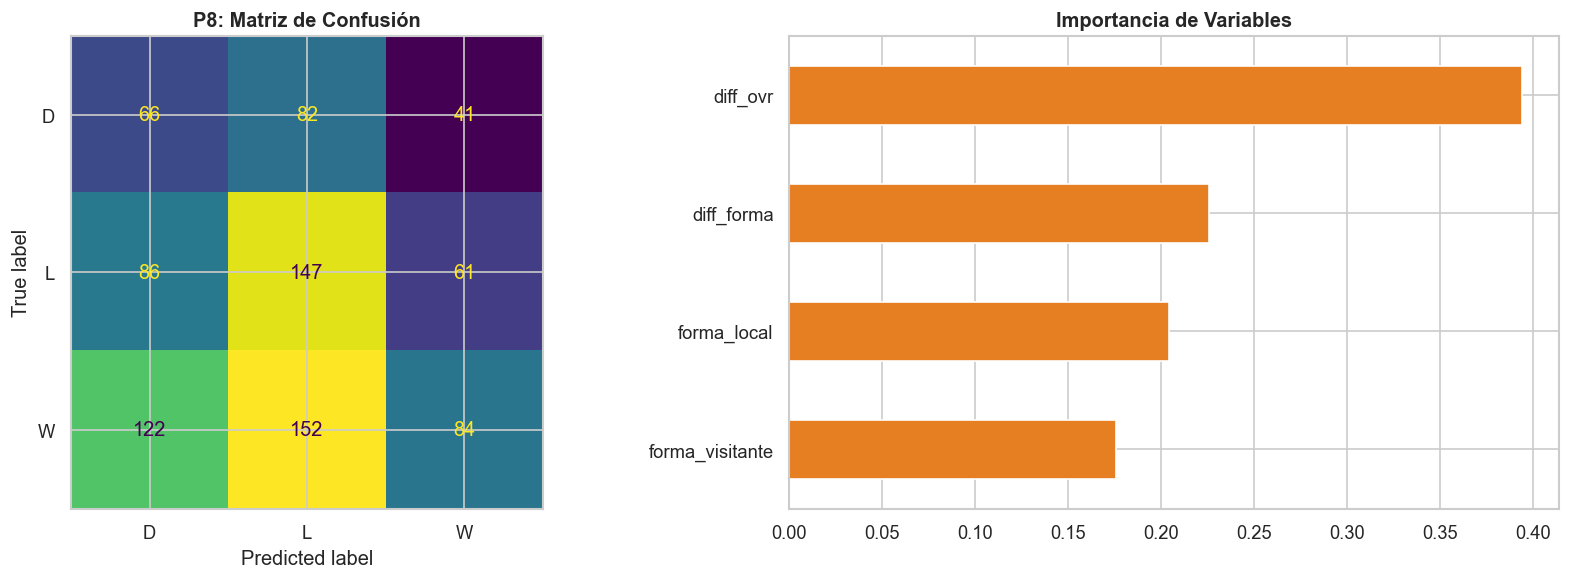


=== EJEMPLO: ÚLTIMO PARTIDO DE CRUZ AZUL ===
D : 37.8 %
L : 29.8 %
W : 32.4 %


In [ ]:
# P8 — Predicción de resultado de partidos Cruz Azul

# ── Squad strength: Overall promedio por equipo y temporada
squad_str = (df[df['fifa_overall'].notna()]
             .groupby(['equipo_norm', 'season_year'])['fifa_overall']
             .mean().reset_index()
             .rename(columns={'fifa_overall': 'squad_overall'}))

pt = partidos.copy()
pt['season_year'] = pt['season_year'].astype('Int64')

pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_local_norm',
                                         'squad_overall': 'ovr_local'}),
              on=['equipo_local_norm', 'season_year'], how='left')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_visitante_norm',
                                         'squad_overall': 'ovr_visit'}),
              on=['equipo_visitante_norm', 'season_year'], how='left')
pt['diff_ovr'] = pt['ovr_local'] - pt['ovr_visit']

# ── Forma reciente (últimas 5 fechas) por equipo
pt_sorted = pt.sort_values('date').reset_index(drop=True)

def calcular_forma(team, match_date, n=5):
    prev = pt_sorted[pt_sorted['date'] < match_date]
    local_res = prev[prev['equipo_local_norm'] == team]['pts_local']
    visit_res = prev[prev['equipo_visitante_norm'] == team]['pts_visitante']
    hist = pd.concat([local_res, visit_res]).sort_index().tail(n)
    return hist.mean() if len(hist) > 0 else 1.0

pt_sorted['pts_local']     = pt_sorted['resultado_local'].map({'W': 3, 'D': 1, 'L': 0})
pt_sorted['pts_visitante'] = pt_sorted['resultado_local'].map({'W': 0, 'D': 1, 'L': 3})

pt_sorted['forma_local']   = [
    calcular_forma(row['equipo_local_norm'],    row['date'])
    for _, row in pt_sorted.iterrows()]
pt_sorted['forma_visitante'] = [
    calcular_forma(row['equipo_visitante_norm'], row['date'])
    for _, row in pt_sorted.iterrows()]

pt_sorted['diff_forma'] = pt_sorted['forma_local'] - pt_sorted['forma_visitante']

# ── Filtrar Cruz Azul (local o visitante) para análisis específico
ca_p8 = pt_sorted[es_ca(pt_sorted['equipo_local_norm']) |
                  es_ca(pt_sorted['equipo_visitante_norm'])].copy()
ca_p8['es_local'] = es_ca(ca_p8['equipo_local_norm']).astype(int)

# ── Modelo general (toda la liga)
feats8 = ['diff_ovr', 'forma_local', 'forma_visitante', 'diff_forma']
df_ml8 = pt_sorted[feats8 + ['resultado_local']].dropna()

le8 = LabelEncoder()
y8  = le8.fit_transform(df_ml8['resultado_local'])
X8  = df_ml8[feats8].values

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.25,
                                                random_state=42, stratify=y8)
rf8 = RandomForestClassifier(n_estimators=200, max_depth=5,
                              random_state=42, class_weight='balanced')
rf8.fit(X8_tr, y8_tr)
y8_pred = rf8.predict(X8_te)

print('=== MODELO P8: PREDICCIÓN DE RESULTADO ===')
print(classification_report(y8_te, y8_pred, target_names=le8.classes_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Matriz de confusión
cm8 = confusion_matrix(y8_te, y8_pred)
ConfusionMatrixDisplay(cm8, display_labels=le8.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P8: Matriz de Confusión', fontweight='bold')

# ── Importancia de variables
imp8 = pd.Series(rf8.feature_importances_, index=feats8).sort_values(ascending=True)
imp8.plot(kind='barh', ax=ax2, color='#E67E22')
ax2.set_title('Importancia de Variables', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Predicción de ejemplo: Cruz Azul vs rival hipotético
if len(ca_p8) > 0:
    sample = ca_p8[feats8].dropna().iloc[-1:]
    probs  = rf8.predict_proba(sample.values)[0]
    print('\n=== EJEMPLO: ÚLTIMO PARTIDO DE CRUZ AZUL ===')
    for cls, p in zip(le8.classes_, probs):
        print(cls, ':', round(p * 100, 1), '%')

---
## P9 — ¿Qué mediocampista disponible en Liga MX maximiza rendimiento/costo ≤ 3 M USD?
> **Método:** Filtrar mediocampistas con valor ≤ 3 M USD. Índice compuesto ponderado: 40 % Overall + 30 % G+A/90 + 20 % Relación valor/rendimiento + 10 % Juventud.  
> **Visualización:** Tabla de recomendaciones + radar chart top candidato vs Cruz Azul.

Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD): 262

=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===
             Jugador             Equipo Pos  Edad  Overall  G+A/90  Valor (M EUR)  Índice
Sebastián Villanueva CHIVAS GUADALAJARA  CM    35       82   2.762           1.90   0.753
        Jesús Torres      SANTOS LAGUNA CDM    18       84   0.239           1.50   0.637
       Leandro Lotti      BRAVOS JUAREZ CAM    36       83   0.828           1.45   0.598
    Jonathan Álvarez      BRAVOS JUAREZ  CM    17       83   0.408           2.15   0.582
        Diego Torres              ATLAS  CM    31       79   1.636           2.05   0.582


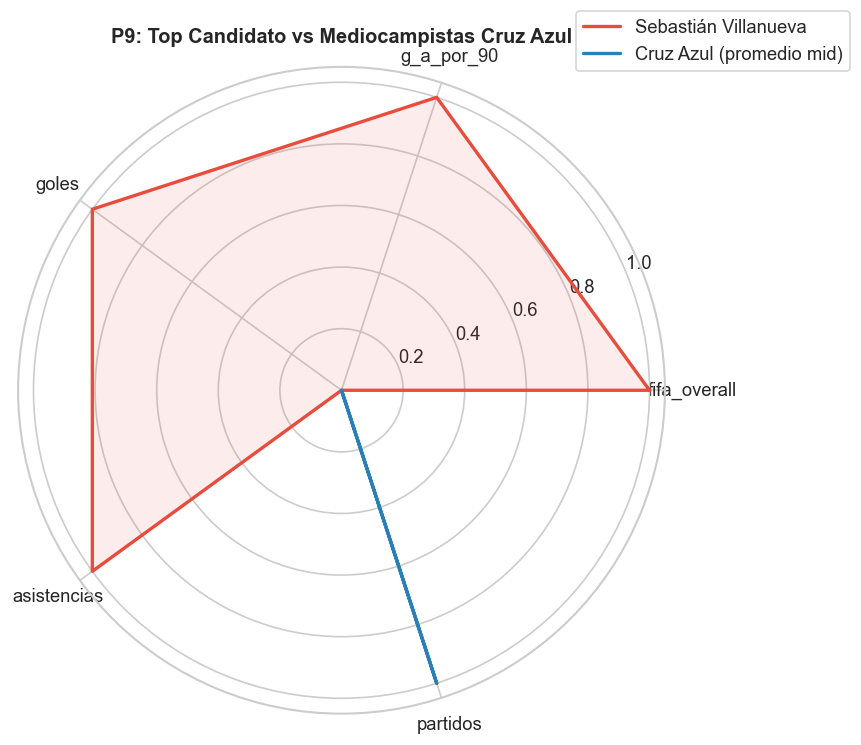

In [ ]:
# P9 — Mejor mediocampista disponible para Cruz Azul (presupuesto <= 3 M USD)

BUDGET_USD = 3_000_000
EUR_USD    = 1.08
BUDGET_EUR = BUDGET_USD / EUR_USD

# ── Posiciones de mediocampo
mid_kw = ['CM', 'CDM', 'CAM', 'MC', 'MCD', 'MCC', 'MCO', 'MI', 'MD',
          'Centrocampista', 'Mediocamp', 'MF', 'DM', 'AM']
mid_pattern = '|'.join(mid_kw)

mids = df[
    df['posicion'].str.contains(mid_pattern, case=False, na=False) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] > 0) &
    (df['valor_mercado_eur'] <= BUDGET_EUR) &
    ~es_ca(df['equipo_norm'])
].copy()

print('Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD):', len(mids))

if len(mids) == 0:
    print('Sin coincidencias exactas — ampliando presupuesto x2')
    mids = df[
        df['posicion'].str.contains(mid_pattern, case=False, na=False) &
        df['valor_mercado_eur'].notna() &
        (df['valor_mercado_eur'] > 0) &
        (df['valor_mercado_eur'] <= BUDGET_EUR * 2) &
        ~es_ca(df['equipo_norm'])
    ].copy()

# ── Índice compuesto
mids_clean = mids.dropna(subset=['fifa_overall', 'g_a_por_90']).copy()
sc = MinMaxScaler()

mids_clean['ov_n']   = sc.fit_transform(mids_clean[['fifa_overall']])
mids_clean['ga_n']   = sc.fit_transform(mids_clean[['g_a_por_90']].fillna(0))
vm_n_vals = 1 - sc.fit_transform(mids_clean[['valor_mercado_eur']])
mids_clean['vm_n']   = vm_n_vals
mids_clean['edad_n'] = 1 - sc.fit_transform(mids_clean[['edad']].fillna(30))

mids_clean['indice'] = (0.40 * mids_clean['ov_n'] +
                        0.30 * mids_clean['ga_n'] +
                        0.20 * mids_clean['vm_n'] +
                        0.10 * mids_clean['edad_n'])

top5 = mids_clean.nlargest(5, 'indice')[['nombre_canonico', 'equipo_norm', 'posicion',
                                          'edad', 'fifa_overall', 'g_a_por_90',
                                          'valor_mercado_eur', 'indice']].copy()
top5['valor_mercado_eur'] = top5['valor_mercado_eur'] / 1e6

print('\n=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===')
top5_disp = top5.copy()
top5_disp.columns = ['Jugador', 'Equipo', 'Pos', 'Edad', 'Overall',
                      'G+A/90', 'Valor (M EUR)', 'Índice']
print(top5_disp.round(3).to_string(index=False))

# ── Radar chart: top candidato vs mediocampistas de Cruz Azul
radar_feats = [f for f in ['fifa_overall', 'g_a_por_90', 'goles', 'asistencias', 'partidos']
               if f in df.columns]
ca_mids = df[
    es_ca(df['equipo_norm']) &
    df['posicion'].str.contains(mid_pattern, case=False, na=False)
][radar_feats + ['nombre_canonico']].dropna()

if len(top5) > 0 and len(ca_mids) > 0:
    cand_name = top5.iloc[0]['nombre_canonico']
    cand_rows = mids_clean[mids_clean['nombre_canonico'] == cand_name][radar_feats]
    if len(cand_rows) == 0:
        cand_rows = mids_clean[radar_feats].iloc[[0]]
    cand_row = cand_rows.iloc[0]
    ca_mean  = ca_mids[radar_feats].mean()

    sc_r = MinMaxScaler()
    combined = pd.DataFrame([cand_row.values, ca_mean.values], columns=radar_feats)
    combined_n = pd.DataFrame(sc_r.fit_transform(combined), columns=radar_feats)

    angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for i, (label, color) in enumerate(zip(
            [cand_name, 'Cruz Azul (promedio mid)'], ['#E74C3C', '#2980B9'])):
        vals = combined_n.iloc[i].tolist() + [combined_n.iloc[i].tolist()[0]]
        ax_r.plot(angles, vals, color=color, lw=2, label=label)
        ax_r.fill(angles, vals, color=color, alpha=0.1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_feats)
    ax_r.set_title('P9: Top Candidato vs Mediocampistas Cruz Azul', fontweight='bold', pad=15)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

---
## P10 — ¿Qué debilidades tácticas tiene Cruz Azul y qué perfil de jugador necesita?
> **Método:** Analizar goles concedidos por jornada en partidos de Cruz Azul. Comparar atributos defensivos FIFA vs los 3 equipos más sólidos de la liga. Identificar perfil y candidatos.  
> **Visualización:** Heatmap de goles concedidos + radar defensivo comparativo.

Equipos más sólidos defensivamente: ['TOLUCA', 'CLUB LEON', 'LEON']
Goles concedidos promedio por partido:
TOLUCA       1.378
CLUB LEON    1.392
LEON         1.440
Name: gc_total, dtype: float64

Cruz Azul — goles concedidos promedio por partido: 1.603


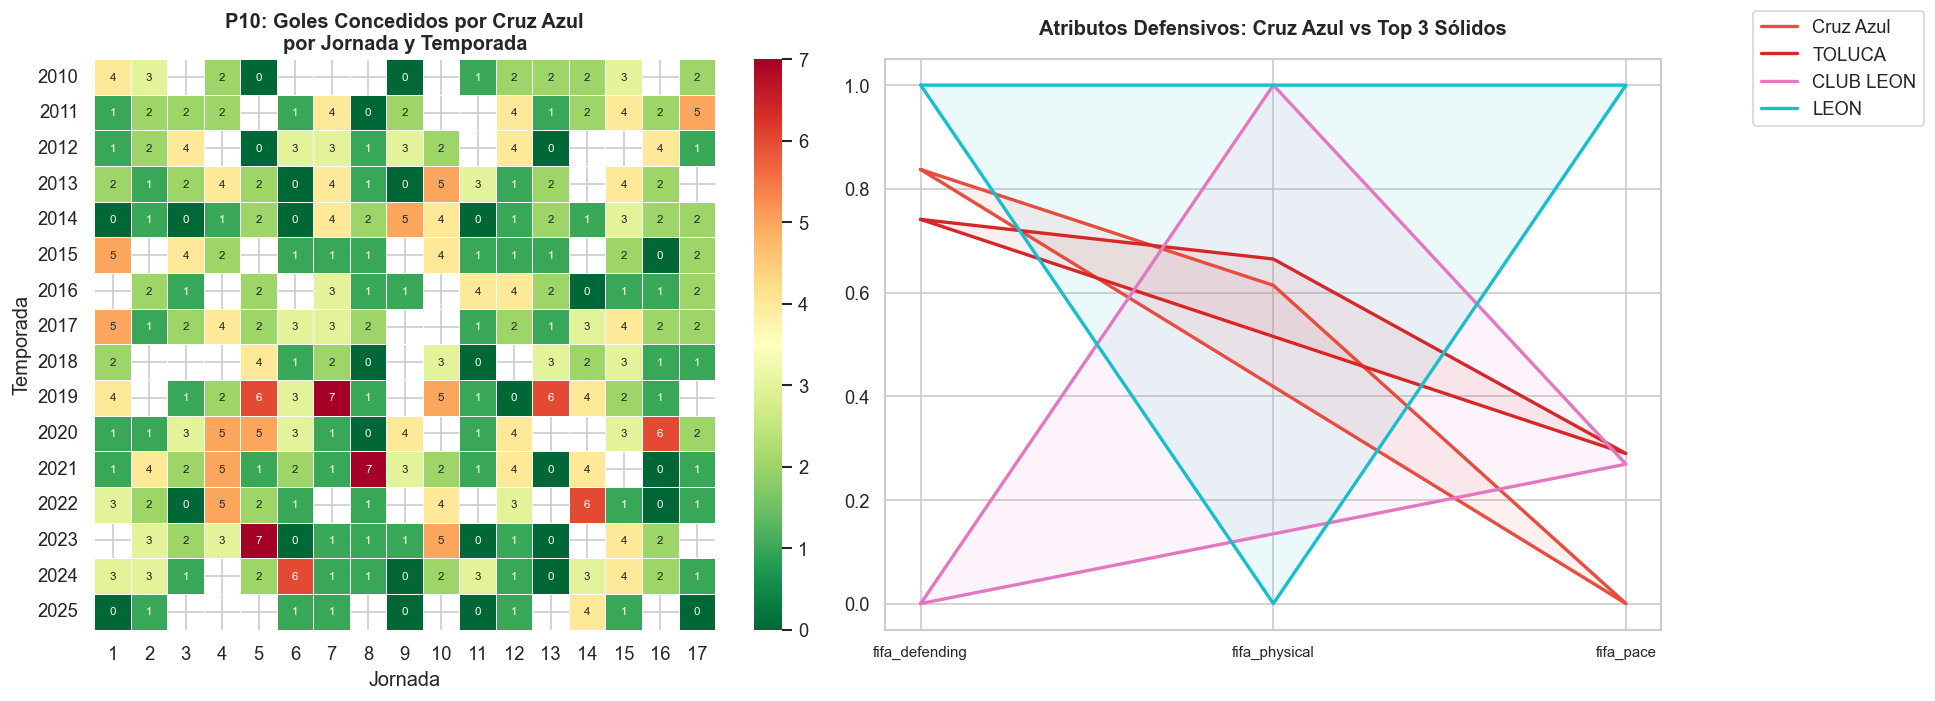


=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===
Gap atributos defensivos (Top3 - Cruz Azul):
fifa_defending   -1.1
fifa_physical    -0.2
fifa_pace         3.3

=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===
  nombre_canonico        equipo_norm posicion  edad  defending  overall  Valor M
     Lucas Suárez            TIJUANA       CB    17         85       71     0.80
 Fernando Álvarez       CLUB AMERICA      CDM    26         85       82     2.65
     Héctor Rivas        TIGRES UANL      CDM    28         85       83     4.35
    Erick Aguirre  ATLETICO SAN LUIS      CDM    18         85       69     1.25
Rodrigo Fernández CHIVAS GUADALAJARA       CB    33         85       82     1.90
 Santiago Giménez          FC JUAREZ       RB    37         85       73     0.70
     Jorge Lozano      SANTOS LAGUNA       RB    30         85       70     1.05
     Marco Moreno      BRAVOS JUAREZ      CDM    21         85       66     0.95
      Alan Macías CHIVAS GUADALAJARA      CD

In [ ]:
# P10 — Debilidades tácticas Cruz Azul

# ── Goles concedidos por Cruz Azul por temporada/jornada
ca_local = partidos[es_ca(partidos['equipo_local_norm'])].copy()
ca_visit = partidos[es_ca(partidos['equipo_visitante_norm'])].copy()

ca_local['goles_concedidos'] = ca_local['goles_visitante']
ca_local['goles_favor']      = ca_local['goles_local']
ca_visit['goles_concedidos'] = ca_visit['goles_local']
ca_visit['goles_favor']      = ca_visit['goles_visitante']

ca_all = pd.concat([ca_local[['season_year', 'round', 'goles_concedidos', 'goles_favor']],
                    ca_visit[['season_year', 'round', 'goles_concedidos', 'goles_favor']]])
ca_all = ca_all.dropna(subset=['goles_concedidos', 'season_year', 'round'])
ca_all['season_year'] = ca_all['season_year'].astype(int)
ca_all['round']       = ca_all['round'].astype(int)

# ── Heatmap goles concedidos por jornada/temporada
pivot_gc = ca_all.pivot_table(index='season_year', columns='round',
                               values='goles_concedidos', aggfunc='sum')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_gc, cmap='RdYlGn_r', ax=ax1,
            linewidths=0.3, annot=True, fmt='.0f', annot_kws={'size': 7})
ax1.set_title('P10: Goles Concedidos por Cruz Azul\npor Jornada y Temporada', fontweight='bold')
ax1.set_xlabel('Jornada')
ax1.set_ylabel('Temporada')

# ── Atributos defensivos: Cruz Azul vs top 3 defensivos de la liga
def_feats = ['fifa_defending', 'fifa_physical', 'fifa_pace']
def_feats_ok = [f for f in def_feats if f in df.columns]

# Equipos que menos goles conceden (promedio por partido)
gc_eq_local = (partidos.groupby('equipo_local_norm')['goles_visitante']
               .mean().rename('gc_local'))
gc_eq_visit = (partidos.groupby('equipo_visitante_norm')['goles_local']
               .mean().rename('gc_visit'))
gc_eq = pd.concat([gc_eq_local, gc_eq_visit], axis=1)
gc_eq['gc_total'] = gc_eq.mean(axis=1)
top3_def = gc_eq.nsmallest(3, 'gc_total').index.tolist()

print('Equipos más sólidos defensivamente:', top3_def)
print('Goles concedidos promedio por partido:')
print(gc_eq.loc[top3_def, 'gc_total'].round(3))

ca_gc = ca_all['goles_concedidos'].mean()
print('\nCruz Azul — goles concedidos promedio por partido:', round(ca_gc, 3))

# ── Radar defensivo
if len(def_feats_ok) > 0:
    def_df = df[def_feats_ok + ['equipo_norm']].dropna()

    groups_names = ['Cruz Azul'] + [t for t in top3_def]
    groups_masks = [es_ca(def_df['equipo_norm'])] + [
        def_df['equipo_norm'].str.contains(t.split()[0], case=False, na=False)
        for t in top3_def]

    profiles = []
    valid_names = []
    for name, mask in zip(groups_names, groups_masks):
        sub = def_df[mask][def_feats_ok]
        if len(sub) > 0:
            profiles.append(sub.mean().values)
            valid_names.append(name)

    if len(profiles) > 1:
        sc_r2 = MinMaxScaler()
        profiles_n = sc_r2.fit_transform(np.array(profiles))

        angles2 = np.linspace(0, 2 * np.pi, len(def_feats_ok), endpoint=False).tolist()
        angles2 += angles2[:1]
        cmap = plt.cm.get_cmap('tab10', len(valid_names))

        for i, (name, pn) in enumerate(zip(valid_names, profiles_n)):
            vals2 = pn.tolist() + [pn[0]]
            color2 = '#E74C3C' if 'Cruz' in name else cmap(i)
            ax2.plot(angles2, vals2, color=color2, lw=2, label=name)
            ax2.fill(angles2, vals2, color=color2, alpha=0.08)

        ax2.set_xticks(angles2[:-1])
        ax2.set_xticklabels(def_feats_ok, fontsize=9)
        ax2.set_title('Atributos Defensivos: Cruz Azul vs Top 3 Sólidos', fontweight='bold', pad=15)
        ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    else:
        ax2.text(0.5, 0.5, 'Datos insuficientes para radar', ha='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'Columnas FIFA defensivas no disponibles', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

# ── Perfil del jugador a fichar y candidatos
print('\n=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===')
if len(def_feats_ok) > 0:
    ca_def_mean = def_df[es_ca(def_df['equipo_norm'])][def_feats_ok].mean()
    liga_top_mean = def_df[def_df['equipo_norm'].isin(top3_def)][def_feats_ok].mean()
    gap = (liga_top_mean - ca_def_mean).round(1)
    print('Gap atributos defensivos (Top3 - Cruz Azul):')
    print(gap.to_string())

# ── Candidatos: defensores/mediocampistas defensivos con alto defending
def_pos_kw = ['CB', 'RB', 'LB', 'CDM', 'SW', 'DC', 'DF', 'Defensa', 'Central']
def_pos_pat = '|'.join(def_pos_kw)

candidatos_def = df[
    df['posicion'].str.contains(def_pos_pat, case=False, na=False) &
    ~es_ca(df['equipo_norm']) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] <= 5_000_000)
].copy()

if 'fifa_defending' in df.columns:
    candidatos_def = candidatos_def.dropna(subset=['fifa_defending'])
    candidatos_def = candidatos_def.sort_values('fifa_defending', ascending=False)
    print('\n=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===')
    cols_disp = ['nombre_canonico', 'equipo_norm', 'posicion', 'edad',
                 'fifa_defending', 'fifa_overall', 'valor_mercado_eur']
    cols_ok = [c for c in cols_disp if c in candidatos_def.columns]
    disp_cand = candidatos_def[cols_ok].head(10).copy()
    disp_cand['valor_mercado_eur'] = disp_cand['valor_mercado_eur'] / 1e6
    disp_cand.columns = [c.replace('fifa_', '').replace('valor_mercado_eur', 'Valor M')
                          for c in disp_cand.columns]
    print(disp_cand.round(2).to_string(index=False))
else:
    print('Columna fifa_defending no disponible — usando fifa_overall como proxy')
    candidatos_def = candidatos_def.dropna(subset=['fifa_overall'])
    print(candidatos_def[['nombre_canonico', 'equipo_norm', 'posicion',
                           'fifa_overall', 'valor_mercado_eur']]
          .nlargest(10, 'fifa_overall').round(2).to_string(index=False))

---
---
# Análisis por Dataset Original — 5 Preguntas por Fuente

Las siguientes 20 preguntas (5 por cada dataset original) son respondidas **directamente desde los archivos fuente** en `datos_final/`, sin pasar por los parquets maestros.

| Dataset | Tipo | Preguntas |
|---------|------|-----------|
| `partidos_historicos_ligamx.csv` | CSV | D1.1 · D1.2 · D1.3 · P1.4 · PR1.5 |
| `perfiles_jugadores_historico.json` | JSON | D2.1 · D2.2 · D2.3 · P2.4 · PR2.5 |
| `scouting_historico_ligamx.txt` | TXT ancho fijo | D3.1 · D3.2 · D3.3 · P3.4 · PR3.5 |
| `valor_mercado_historico.xlsx` | XLSX | D4.1 · D4.2 · D4.3 · P4.4 · PR4.5 |

In [ ]:
# ── Carga de los 4 datasets originales ────────────────────────────────────────
import os, io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              mean_squared_error, r2_score, ConfusionMatrixDisplay, confusion_matrix)
import pathlib

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Ruta dinámica: funciona desde notebooks/ o desde la raíz del proyecto
_here = pathlib.Path().resolve()
_root = _here.parent if _here.name == 'notebooks' else _here
DATA_ORIG = str(_root / 'datos_final')

# ── 1. CSV — Partidos ──────────────────────────────────────────────────────────
df_partidos_csv = pd.read_csv(
    os.path.join(DATA_ORIG, 'partidos_historicos_ligamx.csv'),
    parse_dates=['date']
)
print('CSV — Partidos:', df_partidos_csv.shape)
print('Columnas:', df_partidos_csv.columns.tolist())

# ── 2. JSON — Perfiles jugadores ───────────────────────────────────────────────
with open(os.path.join(DATA_ORIG, 'perfiles_jugadores_historico.json'), encoding='utf-8') as f:
    raw_json = json.load(f)

rows_json = []
for j in raw_json['jugadores']:
    fifa = j['fuentes'].get('fifa', {})
    tm   = j['fuentes'].get('transfermarkt', {})
    cons = j.get('datos_consolidados', {})
    rend = cons.get('rendimiento', {})
    rows_json.append({
        'player_id'        : j['player_id'],
        'posicion'         : cons.get('posicion'),
        'nacionalidad'     : cons.get('nacionalidad'),
        'es_extranjero'    : cons.get('es_extranjero'),
        'doble_nac'        : cons.get('doble_nacionalidad'),
        'edad'             : cons.get('edad'),
        'temporada'        : cons.get('temporada'),
        'season_year'      : cons.get('season_year'),
        'equipo_id'        : cons.get('equipo_id'),
        'goles'            : rend.get('goles'),
        'asistencias'      : rend.get('asistencias'),
        'minutos'          : rend.get('minutos_jugados'),
        'partidos'         : rend.get('partidos'),
        'g_a_por_90'       : rend.get('g_a_por_90'),
        'fifa_overall'     : fifa.get('overall'),
        'fifa_pace'        : fifa.get('pace'),
        'fifa_shooting'    : fifa.get('shooting'),
        'fifa_passing'     : fifa.get('passing'),
        'fifa_dribbling'   : fifa.get('dribbling'),
        'fifa_defending'   : fifa.get('defending'),
        'fifa_physical'    : fifa.get('physical'),
        'valor_mercado_eur': tm.get('valor_mercado_eur'),
        'transfer_paid_eur': tm.get('transfer_paid_eur'),
        'fecha_tm'         : tm.get('fecha_actualizacion'),
    })
df_json = pd.DataFrame(rows_json)
print('\nJSON — Jugadores:', df_json.shape)

# ── 3. TXT — Scouting (ancho fijo) ────────────────────────────────────────────
with open(os.path.join(DATA_ORIG, 'scouting_historico_ligamx.txt'), encoding='utf-8') as f:
    lines_sc = f.readlines()
# Línea 0: cabecera de columnas; Línea 1: separador; Línea 2+: datos
header_sc   = lines_sc[0]
data_sc     = [l for l in lines_sc[2:] if l.strip() and l.strip()[0] == 'P']
df_scouting = pd.read_fwf(io.StringIO(header_sc + ''.join(data_sc)), header=0)
# Limpiar nombre de columnas
df_scouting.columns = [c.strip().replace('+', '_').replace('/', '_') for c in df_scouting.columns]
# Separar columnas fusionadas por read_fwf (NAC+EXT  y  TEMP+EQUIPO)
_nac_ext = next((c for c in df_scouting.columns if 'NAC' in c and 'EXT' in c), None)
if _nac_ext:
    _split_ne = df_scouting[_nac_ext].astype(str).str.rsplit(n=1, expand=True)
    df_scouting['NAC'] = _split_ne[0].str.strip()
    df_scouting['EXT'] = _split_ne[1].str.strip()
_temp_eq = next((c for c in df_scouting.columns if 'TEMP' in c and 'EQUIPO' in c), None)
if _temp_eq:
    _split_te = df_scouting[_temp_eq].astype(str).str.split(r'\s{2,}', n=1, expand=True, regex=True)
    df_scouting['TEMP']   = _split_te[0].str.strip()
    df_scouting['EQUIPO'] = _split_te[1].str.strip() if 1 in _split_te.columns else np.nan
# Convertir N/D a NaN en columnas numéricas
for col in ['OVR', 'MVAL_EUR', 'TPAG_EUR', 'GOLES', 'ASIS', 'MINS', 'G_A_90']:
    if col in df_scouting.columns:
        df_scouting[col] = pd.to_numeric(
            df_scouting[col].astype(str).str.replace(',', '').str.replace('N/D', 'NaN'),
            errors='coerce'
        )
print('\nTXT — Scouting:', df_scouting.shape)
print('Columnas:', df_scouting.columns.tolist())

# ── 4. XLSX — Valor de mercado ─────────────────────────────────────────────────
df_xlsx = pd.read_excel(os.path.join(DATA_ORIG, 'valor_mercado_historico.xlsx'))
print('\nXLSX — Valor mercado:', df_xlsx.shape)
print('Columnas:', df_xlsx.columns.tolist())


---
## Dataset 1 — `partidos_historicos_ligamx.csv`
**4 080 partidos · Liga MX 2010–2024 · Fuente: Kaggle / Open Football Data**

| # | Pregunta | Tipo |
|---|----------|------|
| D1.1 | ¿Cómo ha evolucionado el promedio de goles por partido temporada a temporada? | Descriptivo |
| D1.2 | ¿Qué estadios presentan mayor ventaja local (promedio de goles locales vs visitantes)? | Descriptivo |
| D1.3 | ¿Difiere la distribución de resultados (W/D/L) entre Apertura y Clausura? | Descriptivo |
| P1.4 | ¿Se puede predecir el resultado final a partir del marcador al medio tiempo? | **Predictivo** |
| PR1.5 | ¿En qué jornadas históricas Cruz Azul rinde peor como visitante y debe prepararse más? | Prescriptivo |

---
### D1.1 — ¿Cómo ha evolucionado el promedio de goles por partido temporada a temporada?
> **Método:** Calcular goles totales (local + visitante) y promedio por partido para cada `season_year`. Identificar tendencias y años atípicos.  
> **Visualización:** Línea de tiempo + barra de totales.

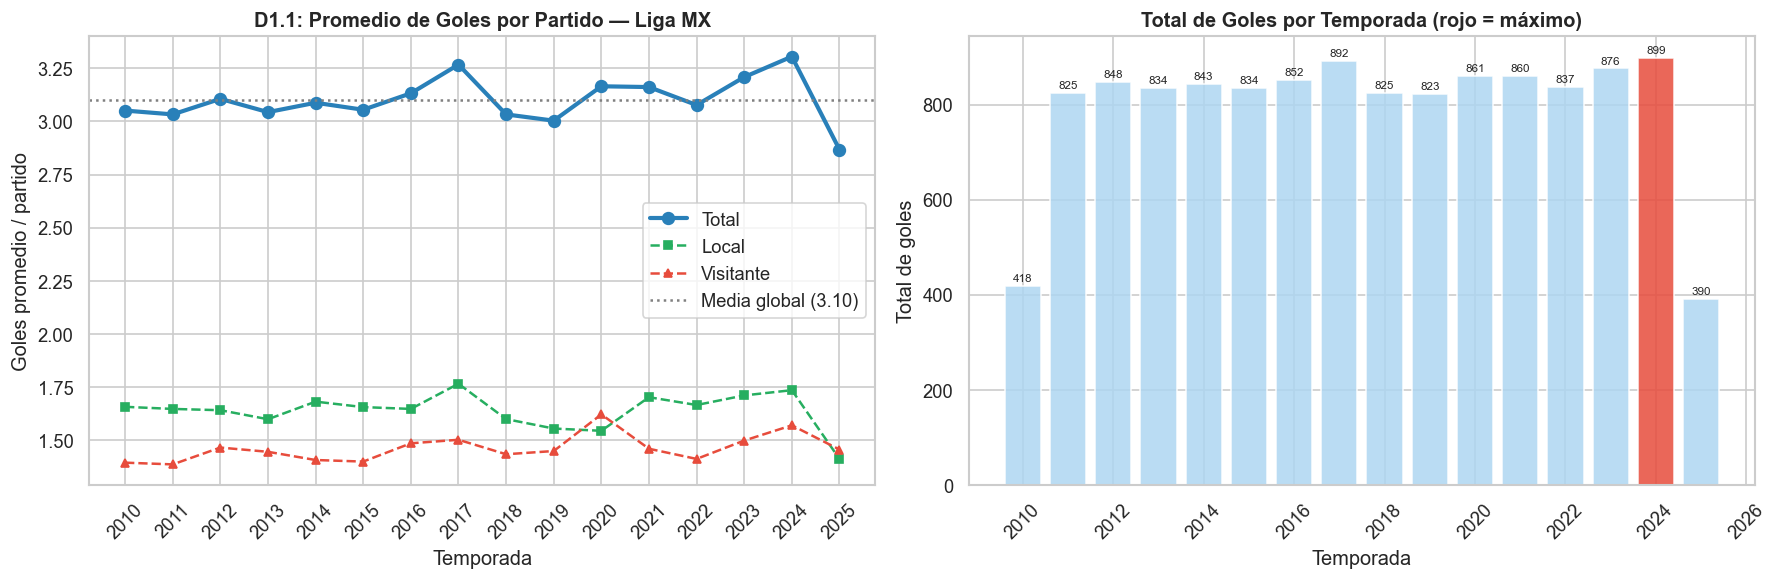

=== ESTADÍSTICAS POR TEMPORADA ===
             partidos  goles  media_goles  media_local  media_visit
season_year                                                        
2010              137    418        3.051        1.657        1.394
2011              272    825        3.033        1.647        1.386
2012              273    848        3.106        1.641        1.465
2013              274    834        3.044        1.599        1.445
2014              273    843        3.088        1.681        1.407
2015              273    834        3.055        1.656        1.399
2016              272    852        3.132        1.647        1.485
2017              273    892        3.267        1.766        1.502
2018              272    825        3.033        1.599        1.434
2019              274    823        3.004        1.555        1.449
2020              272    861        3.165        1.544        1.621
2021              272    860        3.162        1.702        1.460
2022         

In [21]:
# D1.1 — Evolución del promedio de goles por partido (CSV)
p = df_partidos_csv.copy()
p['goles_totales'] = p['home_goals'] + p['away_goals']

by_yr = p.groupby('season_year').agg(
    partidos=('match_id', 'count'),
    goles=('goles_totales', 'sum'),
    media_goles=('goles_totales', 'mean'),
    media_local=('home_goals', 'mean'),
    media_visit=('away_goals', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ── Promedio de goles por partido
ax1.plot(by_yr['season_year'], by_yr['media_goles'], 'o-', color='#2980B9', lw=2.5, ms=7, label='Total')
ax1.plot(by_yr['season_year'], by_yr['media_local'], 's--', color='#27AE60', lw=1.5, ms=5, label='Local')
ax1.plot(by_yr['season_year'], by_yr['media_visit'], '^--', color='#E74C3C', lw=1.5, ms=5, label='Visitante')
ax1.axhline(by_yr['media_goles'].mean(), color='gray', ls=':', lw=1.5,
            label=f'Media global ({by_yr["media_goles"].mean():.2f})')
ax1.set_title('D1.1: Promedio de Goles por Partido — Liga MX', fontweight='bold')
ax1.set_xlabel('Temporada'); ax1.set_ylabel('Goles promedio / partido')
ax1.legend(); ax1.set_xticks(by_yr['season_year'])
ax1.tick_params(axis='x', rotation=45)

# ── Total de goles por temporada
colors_yr = ['#E74C3C' if g == by_yr['goles'].max() else '#AED6F1' for g in by_yr['goles']]
ax2.bar(by_yr['season_year'], by_yr['goles'], color=colors_yr, alpha=0.85)
ax2.set_title('Total de Goles por Temporada (rojo = máximo)', fontweight='bold')
ax2.set_xlabel('Temporada'); ax2.set_ylabel('Total de goles')
ax2.tick_params(axis='x', rotation=45)
for _, row in by_yr.iterrows():
    ax2.text(row['season_year'], row['goles'] + 10, str(int(row['goles'])),
             ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print('=== ESTADÍSTICAS POR TEMPORADA ===')
print(by_yr.set_index('season_year').round(3).to_string())

mejor = by_yr.loc[by_yr['media_goles'].idxmax()]
peor  = by_yr.loc[by_yr['media_goles'].idxmin()]
print(f'\nTemporada más goleadora : {int(mejor.season_year)} ({mejor.media_goles:.2f} goles/partido)')
print(f'Temporada menos goleadora: {int(peor.season_year)} ({peor.media_goles:.2f} goles/partido)')

---
### D1.2 — ¿Qué estadios presentan mayor ventaja local?
> **Método:** Para cada `venue`, calcular promedio de goles locales, visitantes y diferencial. Ranking de los 15 estadios con mayor ventaja local.  
> **Visualización:** Barras agrupadas + mapa de calor de resultados por estadio.

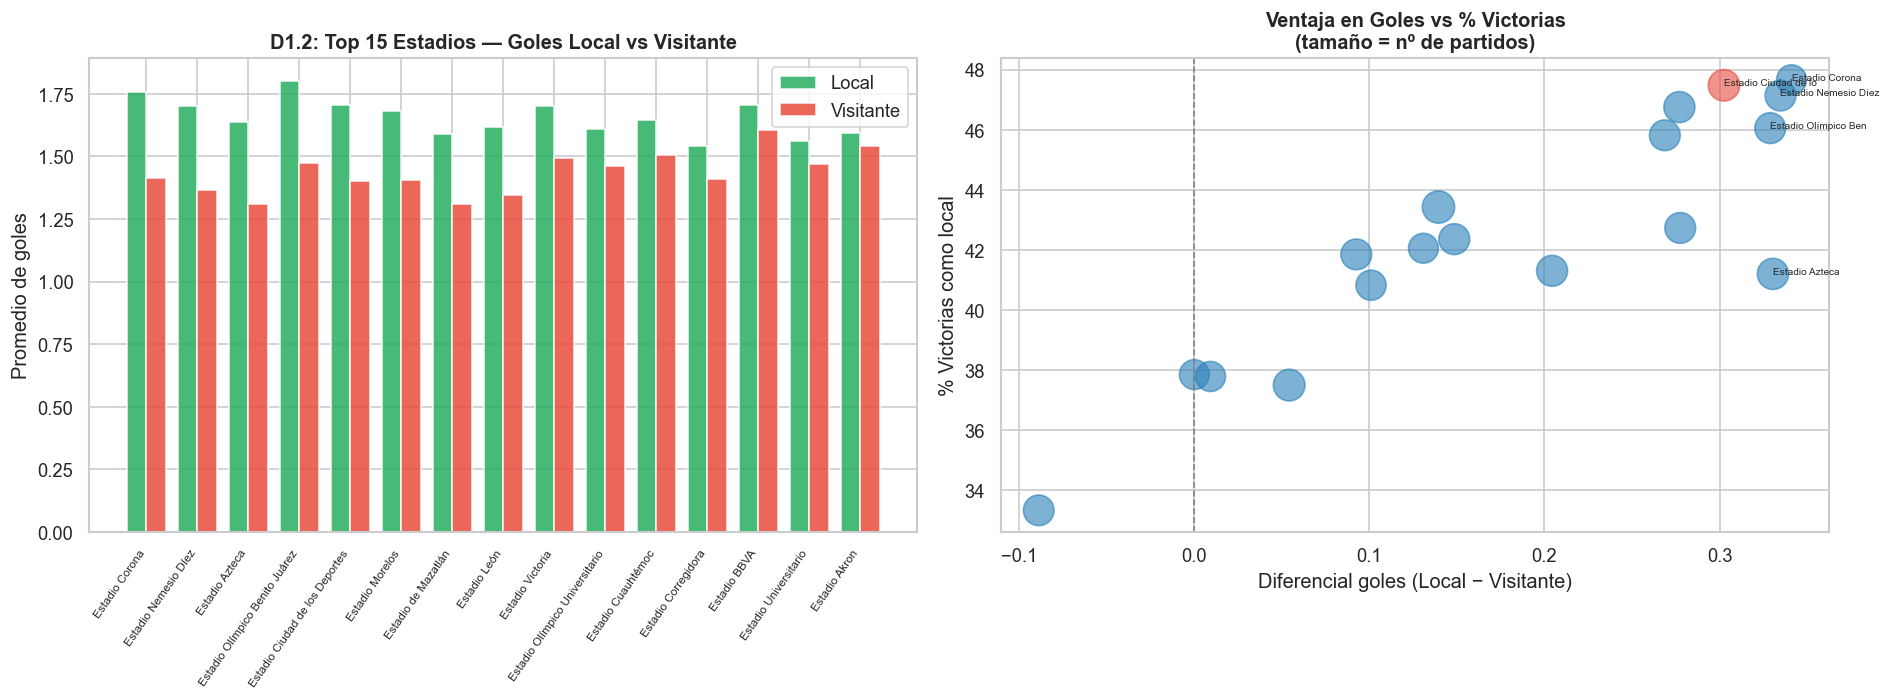

=== TOP 10 ESTADIOS CON MAYOR VENTAJA LOCAL ===
                       Estadio  Partidos  Goles Local  Goles Visita  Ventaja  % Victoria
                Estadio Corona       214        1.757         1.416    0.341      47.664
          Estadio Nemesio Díez       227        1.700         1.366    0.335      47.137
                Estadio Azteca       233        1.639         1.309    0.330      41.202
Estadio Olímpico Benito Juárez       228        1.803         1.474    0.329      46.053
Estadio Ciudad de los Deportes       238        1.706         1.403    0.303      47.479
               Estadio Morelos       227        1.683         1.405    0.278      42.731
           Estadio de Mazatlán       231        1.589         1.312    0.277      46.753
                  Estadio León       227        1.617         1.348    0.269      45.815
              Estadio Victoria       230        1.700         1.496    0.204      41.304
Estadio Olímpico Universitario       229        1.611         

In [22]:
# D1.2 — Ventaja local por estadio (CSV)
venues = (df_partidos_csv.groupby('venue').agg(
    partidos=('match_id', 'count'),
    goles_local_prom=('home_goals', 'mean'),
    goles_visit_prom=('away_goals', 'mean'),
    victorias_local=('result_home', lambda x: (x == 'W').sum()),
    empates=('result_home', lambda x: (x == 'D').sum()),
    derrotas_local=('result_home', lambda x: (x == 'L').sum()),
).reset_index())

venues = venues[venues['partidos'] >= 10].copy()
venues['ventaja'] = venues['goles_local_prom'] - venues['goles_visit_prom']
venues['pct_victoria'] = venues['victorias_local'] / venues['partidos'] * 100
venues = venues.sort_values('ventaja', ascending=False)

top15 = venues.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Barras agrupadas: goles local vs visitante
x = np.arange(len(top15))
w = 0.38
ax1.bar(x - w/2, top15['goles_local_prom'], w, label='Local',    color='#27AE60', alpha=0.85)
ax1.bar(x + w/2, top15['goles_visit_prom'], w, label='Visitante', color='#E74C3C', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(top15['venue'], rotation=55, ha='right', fontsize=7)
ax1.set_title('D1.2: Top 15 Estadios — Goles Local vs Visitante', fontweight='bold')
ax1.set_ylabel('Promedio de goles'); ax1.legend()

# ── % victorias locales vs ventaja en goles
sc_colors = ['#E74C3C' if 'Ciudad de los Deportes' in str(v) or 'Cruz' in str(v)
             else '#2980B9' for v in venues['venue']]
ax2.scatter(venues['ventaja'], venues['pct_victoria'],
            s=venues['partidos'] * 1.5, alpha=0.6, c=sc_colors[:len(venues)])
ax2.axvline(0, color='gray', ls='--', lw=1)
ax2.set_xlabel('Diferencial goles (Local − Visitante)')
ax2.set_ylabel('% Victorias como local')
ax2.set_title('Ventaja en Goles vs % Victorias\n(tamaño = nº de partidos)', fontweight='bold')
for _, row in venues.head(5).iterrows():
    ax2.annotate(row['venue'][:20], (row['ventaja'], row['pct_victoria']),
                 fontsize=6, ha='left')

plt.tight_layout()
plt.show()

print('=== TOP 10 ESTADIOS CON MAYOR VENTAJA LOCAL ===')
disp = top15[['venue', 'partidos', 'goles_local_prom', 'goles_visit_prom',
              'ventaja', 'pct_victoria']].head(10)
disp.columns = ['Estadio', 'Partidos', 'Goles Local', 'Goles Visita', 'Ventaja', '% Victoria']
print(disp.round(3).to_string(index=False))

---
### D1.3 — ¿Difiere la distribución de resultados entre Apertura y Clausura?
> **Método:** Comparar porcentaje de victorias locales, empates y derrotas para cada mitad de temporada (`half`).  
> **Visualización:** Gráficas de dona + barras apiladas por temporada.

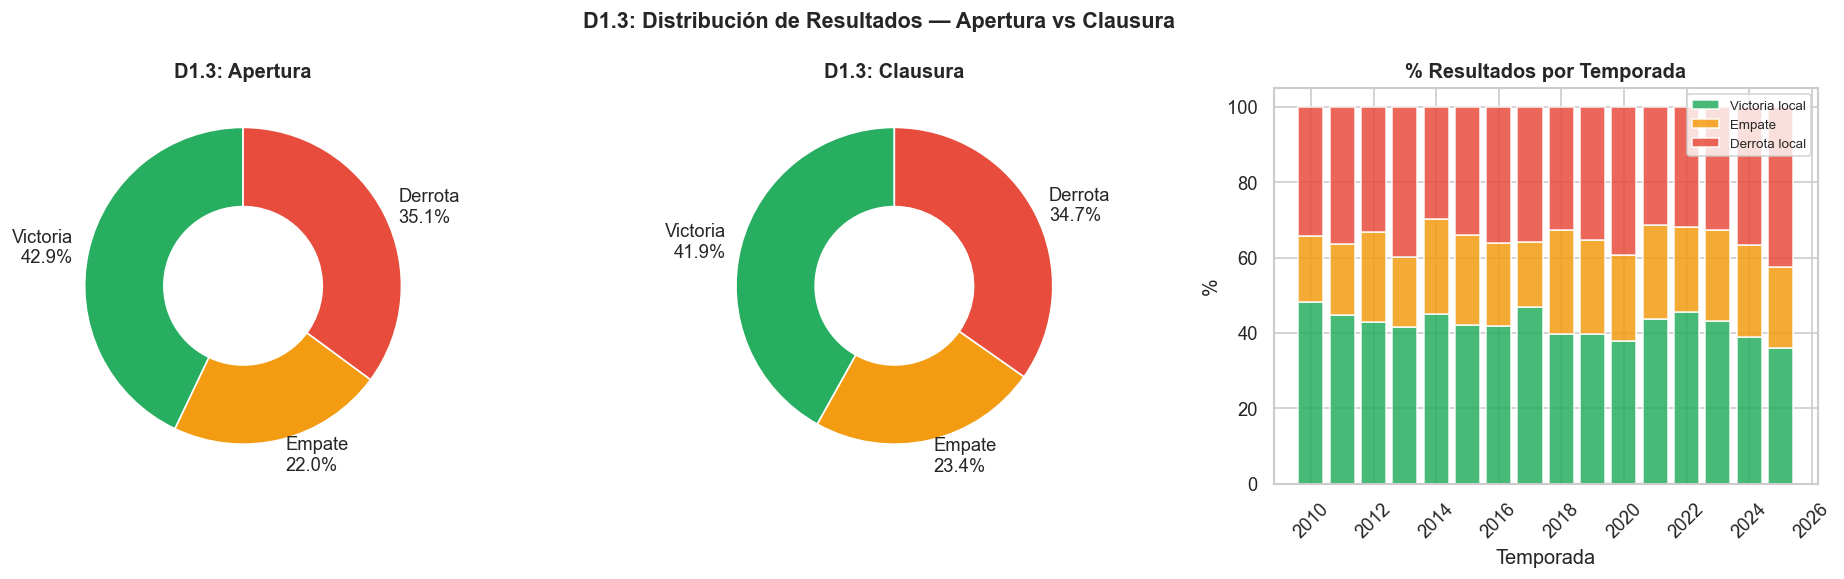

=== % RESULTADOS APERTURA vs CLAUSURA ===
result_home      W      D      L
half                            
apertura     42.93  21.98  35.10
clausura     41.91  23.35  34.73

Test Chi² (Apertura vs Clausura): χ²=1.137, p=0.5665, dof=2
→ Sin diferencia significativa entre torneos


In [23]:
# D1.3 — Distribución W/D/L: Apertura vs Clausura (CSV)
half_res = df_partidos_csv.groupby(['half', 'result_home'])['match_id'].count().unstack(fill_value=0)
half_res = half_res[['W', 'D', 'L']]
half_res['total'] = half_res.sum(axis=1)
half_pct = half_res[['W', 'D', 'L']].div(half_res['total'], axis=0) * 100

# Distribución por temporada y mitad
yr_half = df_partidos_csv.groupby(['season_year', 'half', 'result_home'])['match_id']\
    .count().unstack(fill_value=0).reset_index()
yr_half.columns.name = None

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Donas Apertura / Clausura
colors_wdl = ['#27AE60', '#F39C12', '#E74C3C']
for i, half in enumerate(['apertura', 'clausura']):
    if half not in half_pct.index:
        continue
    vals = half_pct.loc[half, ['W', 'D', 'L']].values
    axes[i].pie(vals, labels=[f'Victoria\n{vals[0]:.1f}%',
                               f'Empate\n{vals[1]:.1f}%',
                               f'Derrota\n{vals[2]:.1f}%'],
                colors=colors_wdl, startangle=90,
                wedgeprops=dict(width=0.5))
    axes[i].set_title(f'D1.3: {half.capitalize()}', fontweight='bold')

# ── Barras apiladas por temporada (% victorias locales)
ax3 = axes[2]
yr_res = df_partidos_csv.groupby(['season_year', 'result_home'])['match_id']\
    .count().unstack(fill_value=0)
yr_res = yr_res.reindex(columns=['W', 'D', 'L'], fill_value=0)
yr_pct = yr_res.div(yr_res.sum(axis=1), axis=0) * 100

bottom_d = yr_pct['W']
bottom_l = yr_pct['W'] + yr_pct['D']
ax3.bar(yr_pct.index, yr_pct['W'], color='#27AE60', alpha=0.85, label='Victoria local')
ax3.bar(yr_pct.index, yr_pct['D'], bottom=bottom_d, color='#F39C12', alpha=0.85, label='Empate')
ax3.bar(yr_pct.index, yr_pct['L'], bottom=bottom_l, color='#E74C3C', alpha=0.85, label='Derrota local')
ax3.set_title('% Resultados por Temporada', fontweight='bold')
ax3.set_xlabel('Temporada'); ax3.set_ylabel('%')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=8)

plt.suptitle('D1.3: Distribución de Resultados — Apertura vs Clausura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== % RESULTADOS APERTURA vs CLAUSURA ===')
print(half_pct.round(2).to_string())

from scipy import stats
# Test chi-cuadrado para comparar distribuciones
if 'apertura' in half_res.index and 'clausura' in half_res.index:
    chi2, p_val, dof, _ = stats.chi2_contingency(
        half_res.loc[['apertura', 'clausura'], ['W', 'D', 'L']])
    print(f'\nTest Chi² (Apertura vs Clausura): χ²={chi2:.3f}, p={p_val:.4f}, dof={dof}')
    print('→', 'Diferencia estadísticamente significativa (p<0.05)' if p_val < 0.05
          else 'Sin diferencia significativa entre torneos')

---
### P1.4 — ¿Se puede predecir el resultado final a partir del marcador al medio tiempo?
> **Método:** Random Forest multiclase (W/D/L). Features: `home_goals_ht`, `away_goals_ht`, diferencial al MT, `half` codificado.  
> **Evaluación:** Matriz de confusión + AUC-ROC por clase + importancia de variables.

=== P1.4: PREDICCIÓN RESULTADO FINAL DESDE MARCADOR MT ===
              precision    recall  f1-score   support

           D       0.33      0.51      0.40       232
           L       0.69      0.58      0.63       357
           W       0.75      0.64      0.69       434

    accuracy                           0.59      1023
   macro avg       0.59      0.57      0.57      1023
weighted avg       0.63      0.59      0.60      1023

AUC-ROC (macro OvR): 0.7600


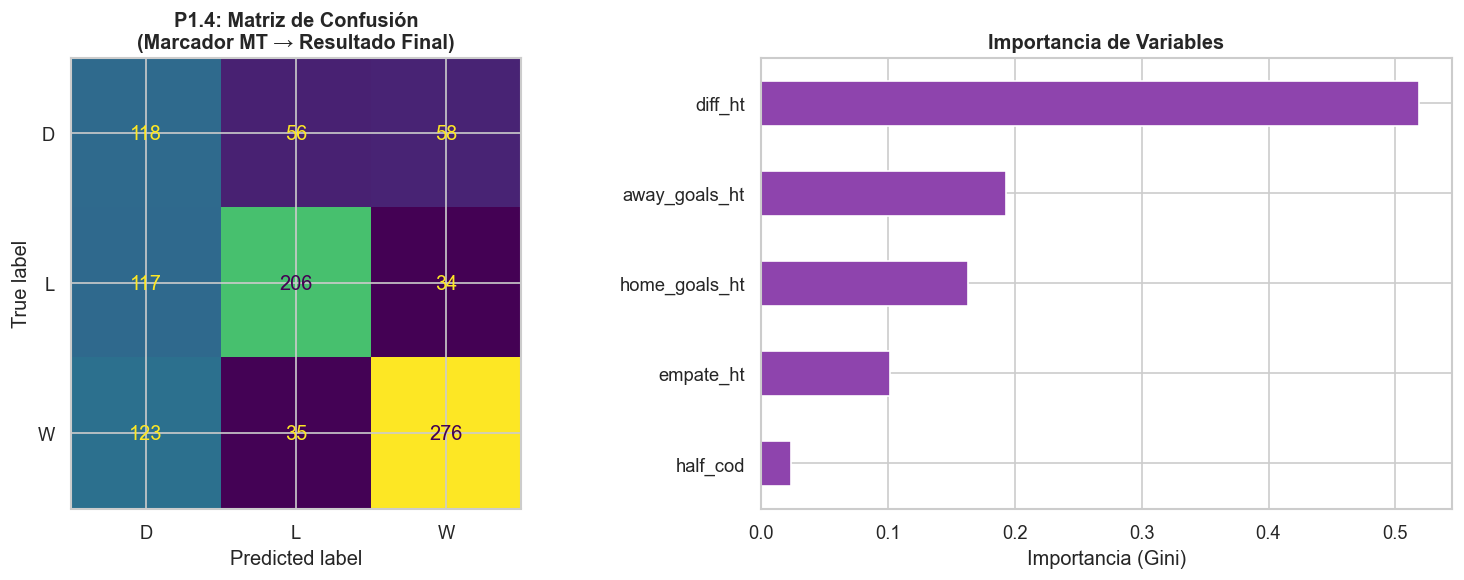


=== PROBABILIDADES RESULTADO FINAL SEGÚN MARCADOR MT ===
MT 2-0 → D: 15.4% | L: 6.6% | W: 78.0%
MT 1-0 → D: 26.7% | L: 15.0% | W: 58.3%
MT 0-0 → D: 43.7% | L: 29.5% | W: 26.8%
MT 1-1 → D: 47.6% | L: 26.0% | W: 26.3%
MT 0-1 → D: 34.0% | L: 51.9% | W: 14.1%
MT 0-2 → D: 16.0% | L: 78.5% | W: 5.5%


In [24]:
# P1.4 — Predicción del resultado final desde el marcador al medio tiempo (CSV)
p14 = df_partidos_csv[['home_goals_ht', 'away_goals_ht',
                         'result_home', 'half']].dropna().copy()
p14['diff_ht']   = p14['home_goals_ht'] - p14['away_goals_ht']
p14['empate_ht'] = (p14['diff_ht'] == 0).astype(int)
p14['half_cod']  = (p14['half'] == 'clausura').astype(int)

feats14 = ['home_goals_ht', 'away_goals_ht', 'diff_ht', 'empate_ht', 'half_cod']
le14 = LabelEncoder()
y14  = le14.fit_transform(p14['result_home'])
X14  = p14[feats14].values

X14_tr, X14_te, y14_tr, y14_te = train_test_split(X14, y14, test_size=0.25,
                                                    random_state=42, stratify=y14)
rf14 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                               class_weight='balanced')
rf14.fit(X14_tr, y14_tr)
y14_pred = rf14.predict(X14_te)
y14_prob  = rf14.predict_proba(X14_te)

print('=== P1.4: PREDICCIÓN RESULTADO FINAL DESDE MARCADOR MT ===')
print(classification_report(y14_te, y14_pred, target_names=le14.classes_))

auc_ovr = roc_auc_score(y14_te, y14_prob, multi_class='ovr', average='macro')
print(f'AUC-ROC (macro OvR): {auc_ovr:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm14 = confusion_matrix(y14_te, y14_pred)
ConfusionMatrixDisplay(cm14, display_labels=le14.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P1.4: Matriz de Confusión\n(Marcador MT → Resultado Final)', fontweight='bold')

imp14 = pd.Series(rf14.feature_importances_, index=feats14).sort_values()
imp14.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

# ── Tabla de probabilidades por escenario de MT
print('\n=== PROBABILIDADES RESULTADO FINAL SEGÚN MARCADOR MT ===')
escenarios = pd.DataFrame([
    [2, 0], [1, 0], [0, 0], [1, 1], [0, 1], [0, 2]
], columns=['home_goals_ht', 'away_goals_ht'])
escenarios['diff_ht']   = escenarios['home_goals_ht'] - escenarios['away_goals_ht']
escenarios['empate_ht'] = (escenarios['diff_ht'] == 0).astype(int)
escenarios['half_cod']  = 0
probs_esc = rf14.predict_proba(escenarios[feats14].values)
for i, (_, row) in enumerate(escenarios.iterrows()):
    p = probs_esc[i]
    print(f"MT {int(row.home_goals_ht)}-{int(row.away_goals_ht)} → "
          + ' | '.join([f'{cls}: {p[j]*100:.1f}%' for j, cls in enumerate(le14.classes_)]))

---
### PR1.5 — ¿En qué jornadas históricas Cruz Azul rinde peor como visitante?
> **Método:** Filtrar partidos donde Cruz Azul es visitante (`involves_cruz_azul=1` + `away_team` contiene Cruz Azul). Calcular puntos obtenidos, goles a favor/en contra y tasa de derrota por `round`.  
> **Prescripción:** Calendario de jornadas "críticas" donde el cuerpo técnico debe elevar la preparación.

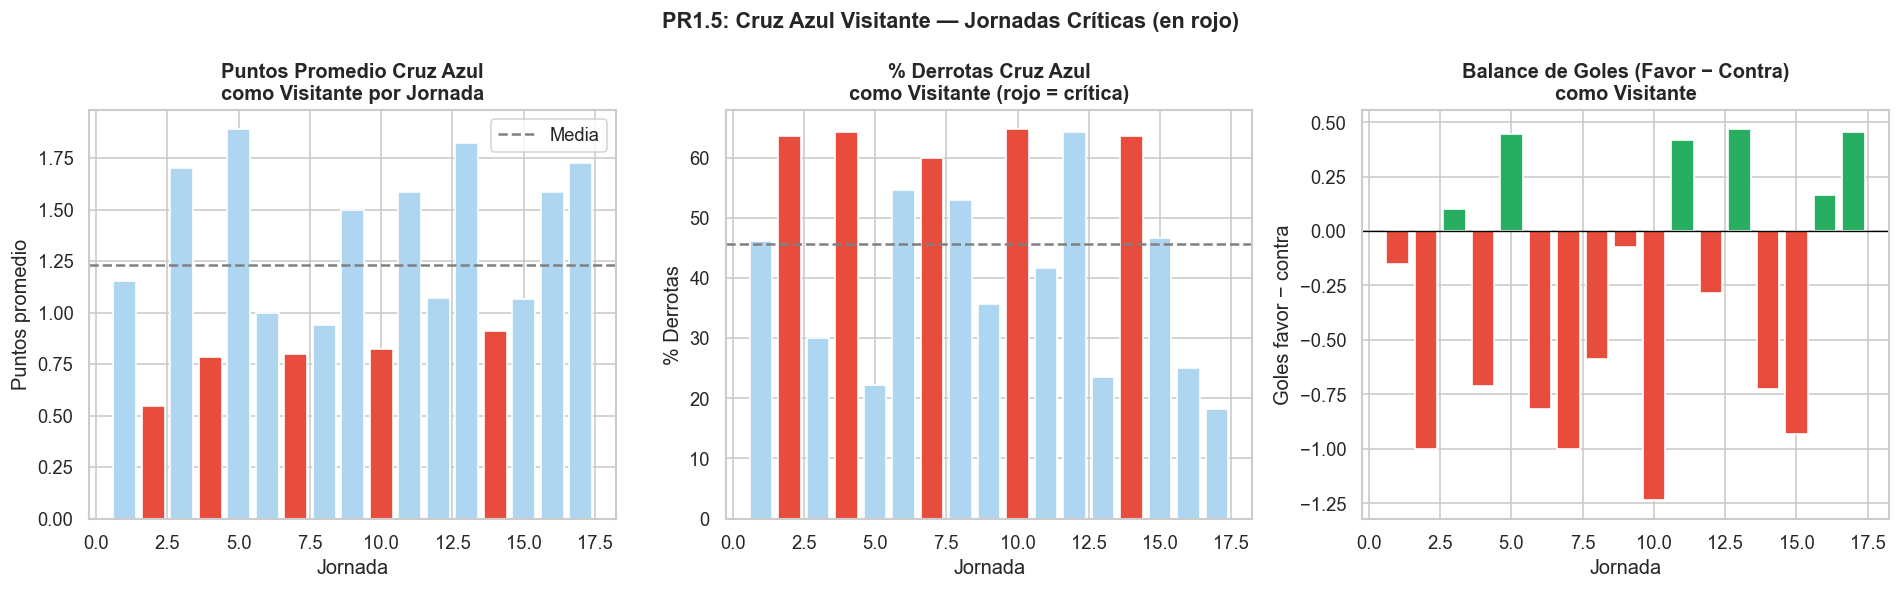

=== PRESCRIPCIÓN: JORNADAS CRÍTICAS PARA PREPARACIÓN REFORZADA ===
Total partidos como visitante analizados: 223

Jornadas críticas identificadas: [2, 4, 7, 10, 14]

Detalle de las 5 jornadas más problemáticas:
 Jornada  Partidos  Pts Prom  Tasa Derrota  Goles Favor  Goles Contra  Balance  Índice Crítico
       2        11     0.545         0.636        0.727         1.727   -1.000           0.991
       4        14     0.786         0.643        1.357         2.071   -0.714           0.889
      10        17     0.824         0.647        0.765         2.000   -1.235           0.876
       7        15     0.800         0.600        1.067         2.067   -1.000           0.846
      14        11     0.909         0.636        1.545         2.273   -0.727           0.828

Recomendación: concentrar mayor trabajo táctico defensivo en las semanas
previas a las jornadas marcadas como críticas en visita.
Especialmente trabajar la fase ofensiva en desplazamiento en estas fechas.


In [25]:
# PR1.5 — Jornadas críticas de Cruz Azul como visitante (CSV)
ca_visit_csv = df_partidos_csv[
    df_partidos_csv['away_team'].str.contains('Cruz Azul|C\. Azul|C\.Azul', case=False, na=False)
].copy()

ca_visit_csv['pts_ca'] = ca_visit_csv['result_home'].map({'W': 0, 'D': 1, 'L': 3})
ca_visit_csv['derrota'] = (ca_visit_csv['result_home'] == 'W').astype(int)

by_round = ca_visit_csv.groupby('round').agg(
    partidos=('match_id', 'count'),
    pts_promedio=('pts_ca', 'mean'),
    tasa_derrota=('derrota', 'mean'),
    goles_favor=('away_goals', 'mean'),
    goles_contra=('home_goals', 'mean')
).reset_index()
by_round['balance_goles'] = by_round['goles_favor'] - by_round['goles_contra']
by_round = by_round[by_round['partidos'] >= 3]

# Jornadas críticas: baja puntuación Y alta tasa de derrota
by_round['indice_critico'] = (1 - MinMaxScaler().fit_transform(by_round[['pts_promedio']])).flatten() * 0.6 + \
                              MinMaxScaler().fit_transform(by_round[['tasa_derrota']]).flatten() * 0.4
criticas = by_round.nlargest(5, 'indice_critico')['round'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Puntos promedio por jornada
colors_r = ['#E74C3C' if r in criticas else '#AED6F1' for r in by_round['round']]
axes[0].bar(by_round['round'], by_round['pts_promedio'], color=colors_r)
axes[0].axhline(by_round['pts_promedio'].mean(), color='gray', ls='--', lw=1.5, label='Media')
axes[0].set_title('Puntos Promedio Cruz Azul\ncomo Visitante por Jornada', fontweight='bold')
axes[0].set_xlabel('Jornada'); axes[0].set_ylabel('Puntos promedio')
axes[0].legend()

# ── Tasa de derrota
colors_r2 = ['#E74C3C' if r in criticas else '#AED6F1' for r in by_round['round']]
axes[1].bar(by_round['round'], by_round['tasa_derrota'] * 100, color=colors_r2)
axes[1].axhline(by_round['tasa_derrota'].mean() * 100, color='gray', ls='--', lw=1.5)
axes[1].set_title('% Derrotas Cruz Azul\ncomo Visitante (rojo = crítica)', fontweight='bold')
axes[1].set_xlabel('Jornada'); axes[1].set_ylabel('% Derrotas')

# ── Balance de goles
axes[2].bar(by_round['round'], by_round['balance_goles'],
            color=['#27AE60' if b >= 0 else '#E74C3C' for b in by_round['balance_goles']])
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Balance de Goles (Favor − Contra)\ncomo Visitante', fontweight='bold')
axes[2].set_xlabel('Jornada'); axes[2].set_ylabel('Goles favor − contra')

plt.suptitle('PR1.5: Cruz Azul Visitante — Jornadas Críticas (en rojo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== PRESCRIPCIÓN: JORNADAS CRÍTICAS PARA PREPARACIÓN REFORZADA ===')
print(f'Total partidos como visitante analizados: {len(ca_visit_csv)}')
print(f'\nJornadas críticas identificadas: {sorted(criticas)}')
print('\nDetalle de las 5 jornadas más problemáticas:')
detalle = by_round[by_round['round'].isin(criticas)].sort_values('indice_critico', ascending=False)
detalle.columns = ['Jornada', 'Partidos', 'Pts Prom', 'Tasa Derrota',
                   'Goles Favor', 'Goles Contra', 'Balance', 'Índice Crítico']
print(detalle.round(3).to_string(index=False))
print('\nRecomendación: concentrar mayor trabajo táctico defensivo en las semanas')
print('previas a las jornadas marcadas como críticas en visita.')
print('Especialmente trabajar la fase ofensiva en desplazamiento en estas fechas.')

---
## Dataset 2 — `perfiles_jugadores_historico.json`
**1 158 jugadores · 3 sub-fuentes anidadas: FIFA, Transfermarkt, football.csv**

| # | Pregunta | Tipo |
|---|----------|------|
| D2.1 | ¿Cuáles son los atributos FIFA promedio (pace, shooting, passing, dribbling, defending, physical) por posición? | Descriptivo |
| D2.2 | ¿Cuánto sobre o infra-pagan los equipos respecto al valor Transfermarkt en las transferencias? | Descriptivo |
| D2.3 | ¿Qué equipos han registrado más jugadores distintos a lo largo de las temporadas (mayor rotación)? | Descriptivo |
| P2.4 | ¿Se puede clasificar la posición táctica (GK/DEF/MID/FWD) usando solo los atributos FIFA? | **Predictivo** |
| PR2.5 | ¿Qué perfil de atributos FIFA le falta a Cruz Azul comparado con sus rivales más fuertes? | Prescriptivo |

---
### D2.1 — Atributos FIFA promedio por posición
> **Método:** Agrupar por posición y calcular media de los 6 atributos FIFA. Heatmap de la matriz posición × atributo.  
> **Visualización:** Heatmap normalizado + radar chart comparando extremos (GK vs ST).

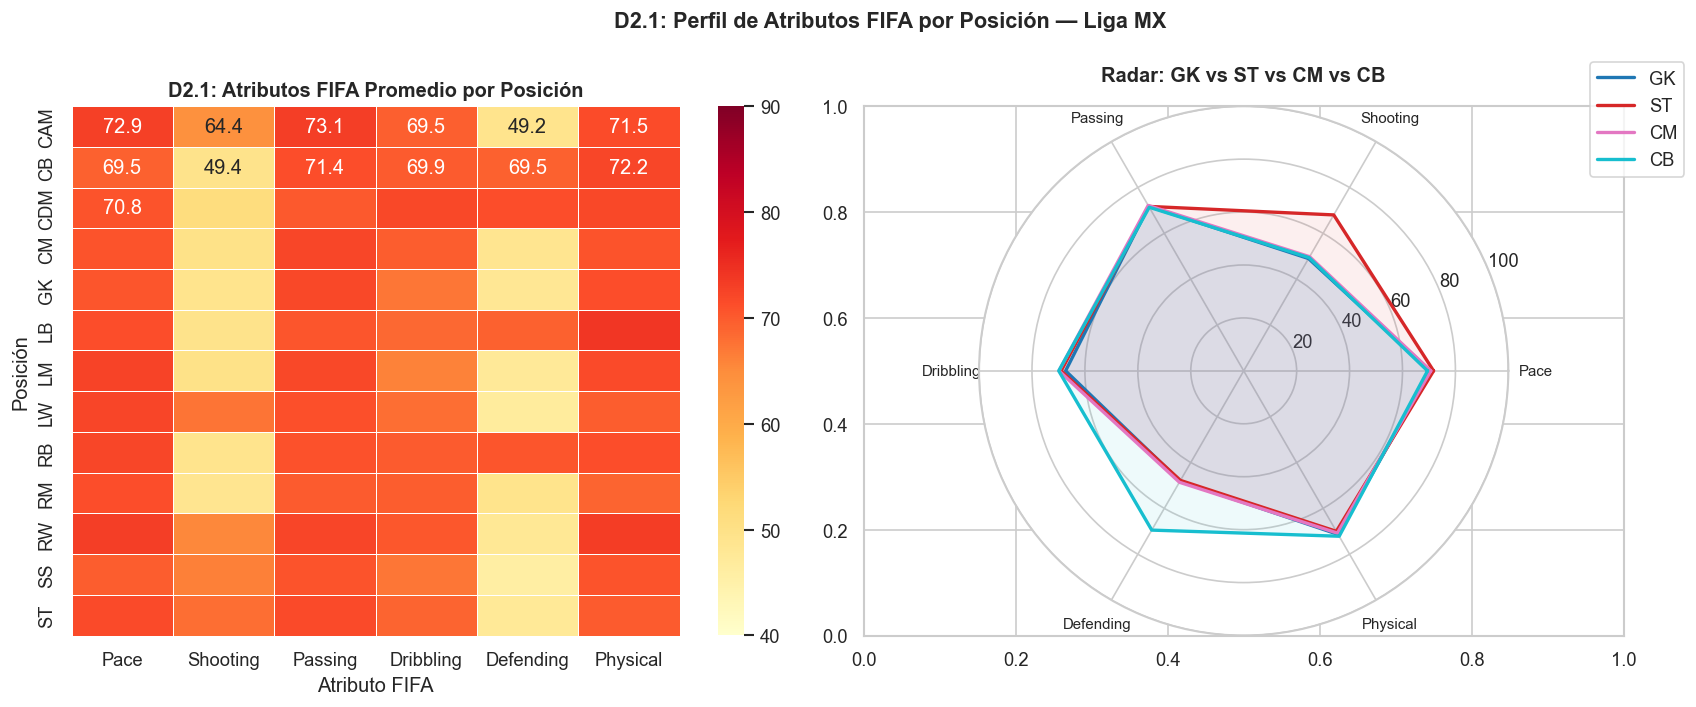

=== ATRIBUTOS FIFA PROMEDIO POR POSICIÓN ===
          Pace  Shooting  Passing  Dribbling  Defending  Physical
posicion                                                         
CAM       72.9      64.4     73.1       69.5       49.2      71.5
CB        69.5      49.4     71.4       69.9       69.5      72.2
CDM       70.8      51.5     70.2       71.9       71.4      71.9
CM        70.7      49.8     72.2       69.8       48.6      70.8
GK        70.5      49.0     71.8       67.3       48.1      71.4
LB        71.3      49.4     70.6       68.5       69.4      74.2
LM        72.6      49.8     71.9       66.0       47.5      71.6
LW        72.3      67.4     71.2       68.0       46.7      69.8
RB        72.2      49.1     70.9       69.9       70.6      71.4
RM        71.4      48.6     70.0       69.9       49.2      69.1
RW        73.2      65.4     72.4       70.4       48.0      73.3
SS        69.7      66.4     70.8       67.3       45.9      70.8
ST        71.7      68.0     71

In [26]:
# D2.1 — Atributos FIFA promedio por posición (JSON)
fifa_attrs = ['fifa_pace', 'fifa_shooting', 'fifa_passing',
              'fifa_dribbling', 'fifa_defending', 'fifa_physical']
attr_labels = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physical']

d21 = df_json[['posicion'] + fifa_attrs].dropna()
pos_counts = d21['posicion'].value_counts()
top_pos21  = pos_counts[pos_counts >= 15].index.tolist()
d21 = d21[d21['posicion'].isin(top_pos21)]

pos_means = d21.groupby('posicion')[fifa_attrs].mean()
pos_means.columns = attr_labels

# Normalizar para el heatmap (0-100 ya están en esa escala, se muestran tal cual)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Heatmap
sns.heatmap(pos_means, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax1, vmin=40, vmax=90)
ax1.set_title('D2.1: Atributos FIFA Promedio por Posición', fontweight='bold')
ax1.set_xlabel('Atributo FIFA'); ax1.set_ylabel('Posición')

# ── Radar chart para GK vs ST vs CM
ax2 = plt.subplot(1, 2, 2, polar=True)
radar_pos = [p for p in ['GK', 'ST', 'CM', 'CB'] if p in pos_means.index]
angles21  = np.linspace(0, 2 * np.pi, len(attr_labels), endpoint=False).tolist()
angles21 += angles21[:1]
cmap21 = plt.cm.get_cmap('tab10', len(radar_pos))

for i, pos in enumerate(radar_pos):
    vals21 = pos_means.loc[pos].tolist() + [pos_means.loc[pos].tolist()[0]]
    ax2.plot(angles21, vals21, lw=2, label=pos, color=cmap21(i))
    ax2.fill(angles21, vals21, alpha=0.07, color=cmap21(i))

ax2.set_xticks(angles21[:-1])
ax2.set_xticklabels(attr_labels, fontsize=9)
ax2.set_ylim(0, 100)
ax2.set_title('Radar: GK vs ST vs CM vs CB', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.suptitle('D2.1: Perfil de Atributos FIFA por Posición — Liga MX', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== ATRIBUTOS FIFA PROMEDIO POR POSICIÓN ===')
print(pos_means.round(1).to_string())
print(f'\nTotal registros con datos FIFA completos: {len(d21)}')

---
### D2.2 — ¿Cuánto sobre o infra-pagan los equipos en transferencias vs valor Transfermarkt?
> **Método:** Calcular `ratio_pago = transfer_paid_eur / valor_mercado_eur` por equipo. Ratio > 1 = sobre-pago.  
> **Visualización:** Boxplot del ratio por equipo + scatter individual.

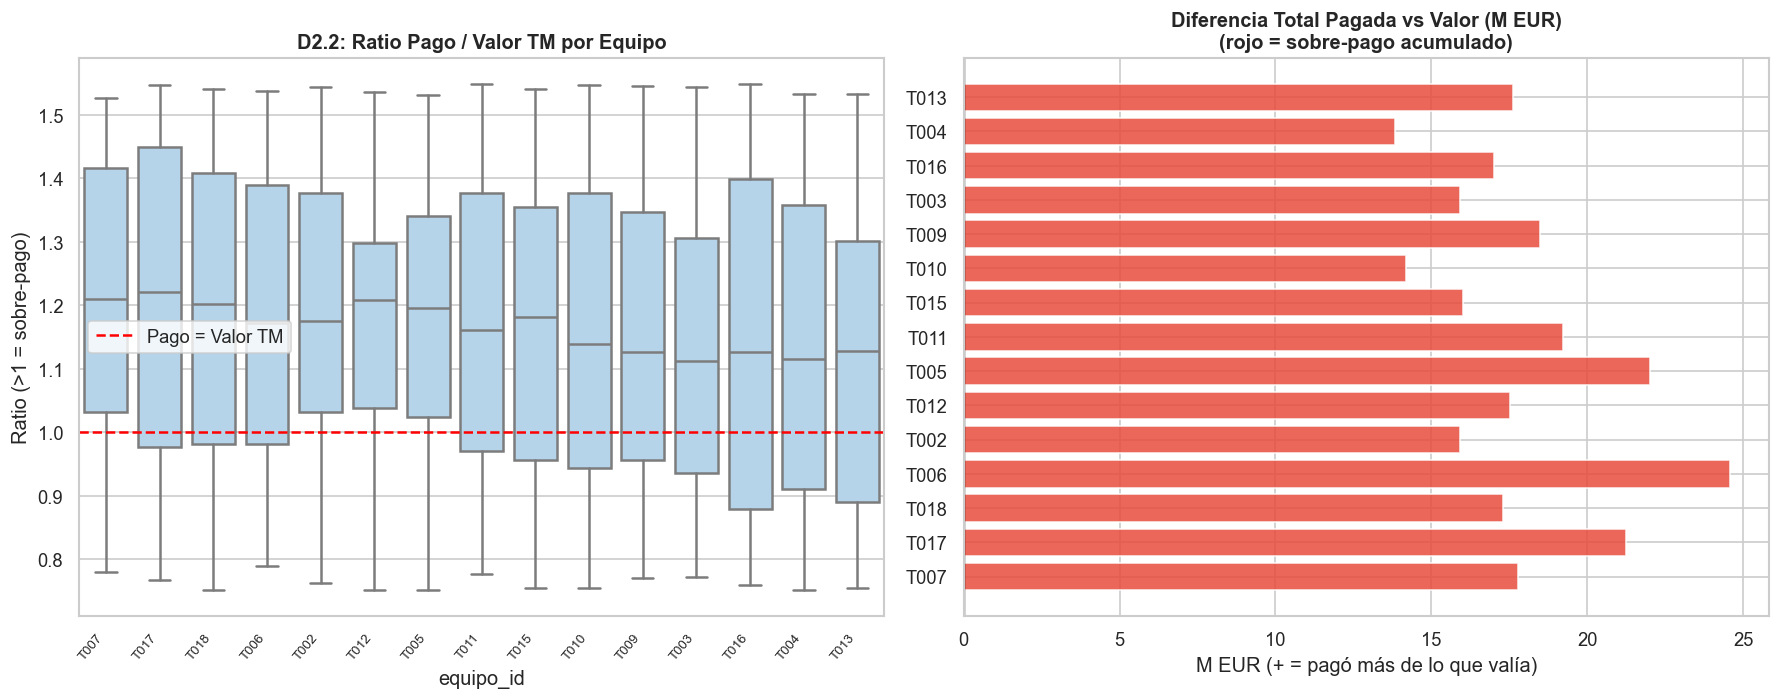

=== D2.2: RATIO PAGO/VALOR POR EQUIPO (n≥5 transferencias) ===
Total registros: 1085 jugadores con datos Transfermarkt completos

equipo_id  n  ratio_medio  ratio_mediano  dif_total_m
     T007 44        1.204          1.210       17.788
     T017 58        1.197          1.222       21.242
     T018 55        1.188          1.202       17.279
     T006 65        1.187          1.172       24.588
     T002 58        1.183          1.176       15.926
     T012 57        1.172          1.208       17.519
     T005 70        1.171          1.196       22.008
     T011 65        1.169          1.161       19.207
     T015 56        1.163          1.181       16.020
     T010 58        1.149          1.139       14.174
     T009 62        1.142          1.127       18.492
     T003 56        1.138          1.113       15.902

Ratio global promedio : 1.152
Ratio global mediano  : 1.155
→ Los equipos pagan en promedio 15.2% MÁS que el valor Transfermarkt.


In [27]:
# D2.2 — Ratio valor pagado vs valor Transfermarkt por equipo (JSON)
d22 = df_json[df_json['valor_mercado_eur'].notna() &
              df_json['transfer_paid_eur'].notna() &
              (df_json['valor_mercado_eur'] > 0)].copy()
d22['ratio_pago']  = d22['transfer_paid_eur'] / d22['valor_mercado_eur']
d22['diferencia_m'] = (d22['transfer_paid_eur'] - d22['valor_mercado_eur']) / 1e6

# Equipo desde el equipo_id → usar nombre del JSON si disponible
# Usamos equipo_id como referencia
equipo_ratio = d22.groupby('equipo_id').agg(
    n=('ratio_pago', 'count'),
    ratio_medio=('ratio_pago', 'mean'),
    ratio_mediano=('ratio_pago', 'median'),
    dif_total_m=('diferencia_m', 'sum')
).reset_index()
equipo_ratio = equipo_ratio[equipo_ratio['n'] >= 5].sort_values('ratio_medio', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Boxplot ratio por equipo (top 15)
top15_eq = equipo_ratio.head(15)['equipo_id'].tolist()
d22_top  = d22[d22['equipo_id'].isin(top15_eq)]
order22  = equipo_ratio[equipo_ratio['equipo_id'].isin(top15_eq)].sort_values('ratio_medio', ascending=False)['equipo_id'].tolist()
sns.boxplot(data=d22_top, x='equipo_id', y='ratio_pago', order=order22,
            color='#AED6F1', fliersize=2, ax=ax1)
ax1.axhline(1.0, color='red', ls='--', lw=1.5, label='Pago = Valor TM')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=50, ha='right', fontsize=8)
ax1.set_title('D2.2: Ratio Pago / Valor TM por Equipo', fontweight='bold')
ax1.set_ylabel('Ratio (>1 = sobre-pago)'); ax1.legend()

# ── Diferencia total acumulada (M EUR)
colors22 = ['#E74C3C' if v > 0 else '#27AE60' for v in equipo_ratio.head(15)['dif_total_m']]
ax2.barh(equipo_ratio.head(15)['equipo_id'], equipo_ratio.head(15)['dif_total_m'],
         color=colors22, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Diferencia Total Pagada vs Valor (M EUR)\n(rojo = sobre-pago acumulado)', fontweight='bold')
ax2.set_xlabel('M EUR (+ = pagó más de lo que valía)')

plt.tight_layout()
plt.show()

print(f'=== D2.2: RATIO PAGO/VALOR POR EQUIPO (n≥5 transferencias) ===')
print(f'Total registros: {len(d22)} jugadores con datos Transfermarkt completos\n')
print(equipo_ratio.head(12).round(3).to_string(index=False))

media_global = d22['ratio_pago'].mean()
mediana_global = d22['ratio_pago'].median()
print(f'\nRatio global promedio : {media_global:.3f}')
print(f'Ratio global mediano  : {mediana_global:.3f}')
print('→', 'Los equipos pagan en promedio'
      + (f' {(media_global-1)*100:.1f}% MÁS' if media_global > 1 else f' {(1-media_global)*100:.1f}% MENOS')
      + ' que el valor Transfermarkt.')

---
### D2.3 — ¿Qué equipos han registrado más jugadores distintos a lo largo de las temporadas?
> **Método:** Contar jugadores únicos (`player_id`) por `equipo_id` y por `season_year`. Calcular tasa de rotación media anual.  
> **Visualización:** Barras de total de jugadores únicos + heatmap temporada × equipo.

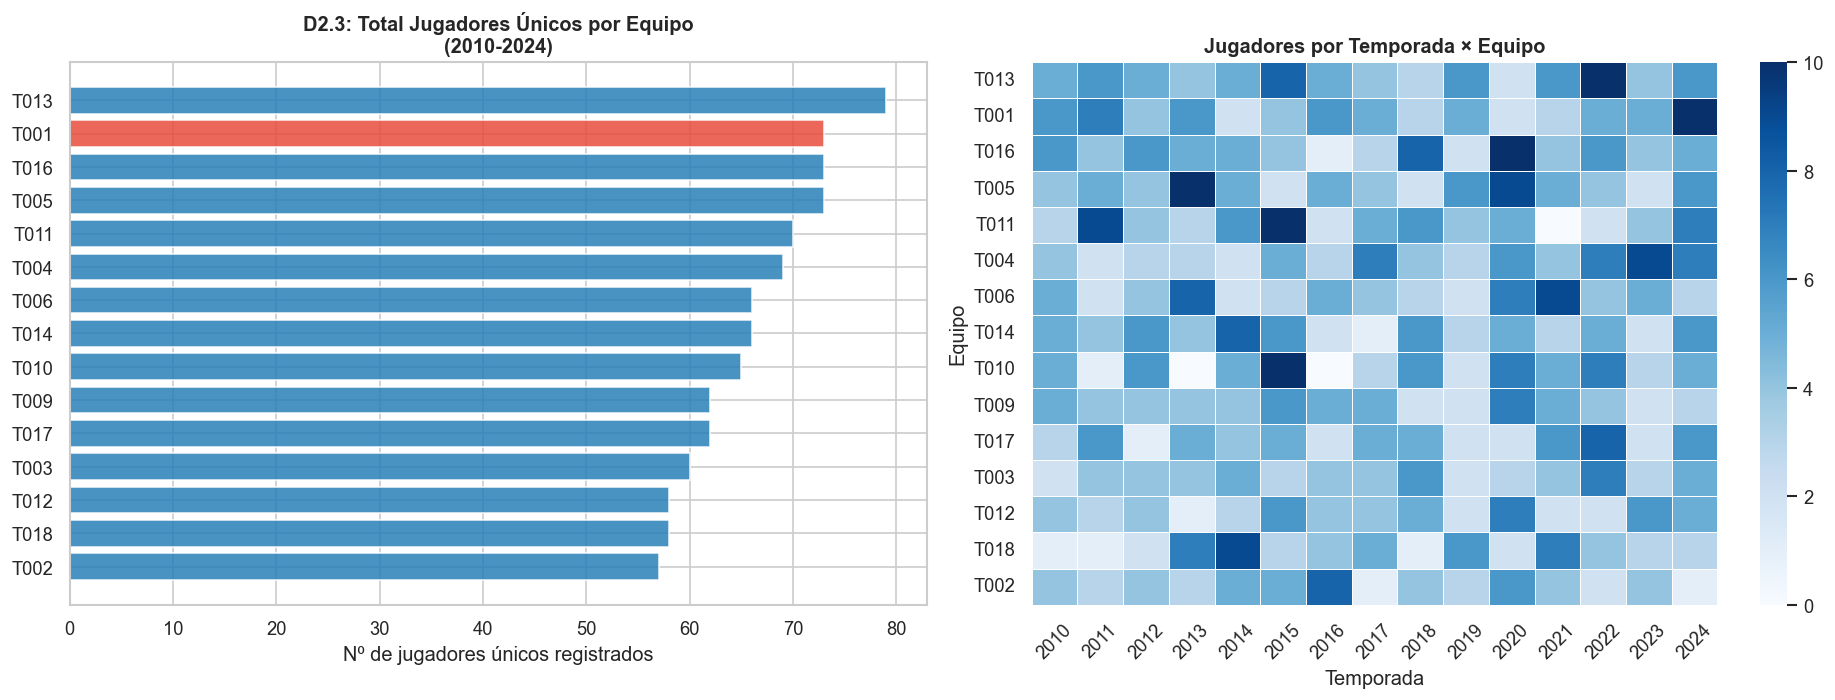

=== TOP 15 EQUIPOS POR TOTAL DE JUGADORES ÚNICOS ===
equipo_id  jugadores_unicos
     T013                79
     T001                73
     T016                73
     T005                73
     T011                70
     T004                69
     T006                66
     T014                66
     T010                65
     T009                62
     T017                62
     T003                60
     T012                58
     T018                58
     T002                57

=== TASA DE ROTACIÓN (volatilidad de plantilla) ===
           mean   std  tasa_rotacion
equipo_id                           
T010       4.33  2.82           0.65
T018       3.87  2.47           0.64
T011       4.67  2.66           0.57
T006       4.40  2.16           0.49
T017       4.13  2.03           0.49
T002       3.80  1.82           0.48
T005       4.87  2.29           0.47
T004       4.60  2.13           0.46
T016       4.87  2.23           0.46
T012       3.87  1.73           0.45
T0

In [28]:
# D2.3 — Rotación de jugadores por equipo y temporada (JSON)
d23 = df_json[df_json['equipo_id'].notna() & df_json['season_year'].notna()].copy()

# Total jugadores únicos por equipo
total_por_eq = (d23.groupby('equipo_id')['player_id']
                .nunique()
                .reset_index(name='jugadores_unicos')
                .sort_values('jugadores_unicos', ascending=False))

# Jugadores por temporada × equipo (heatmap)
piv23 = d23.groupby(['season_year', 'equipo_id'])['player_id'].nunique().unstack(fill_value=0)
# Top 15 equipos con más jugadores únicos totales
top15_eq23 = total_por_eq.head(15)['equipo_id'].tolist()
piv23_top  = piv23[top15_eq23] if all(e in piv23.columns for e in top15_eq23) else piv23

# Tasa de rotación = std de jugadores por temporada / media
rotacion = piv23_top.agg(['mean', 'std']).T
rotacion['tasa_rotacion'] = rotacion['std'] / rotacion['mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Barras totales
colors23 = ['#E74C3C' if 'T001' in str(e) or 'Cruz' in str(e) else '#2980B9'
            for e in total_por_eq.head(15)['equipo_id']]
ax1.barh(total_por_eq.head(15)['equipo_id'][::-1],
         total_por_eq.head(15)['jugadores_unicos'][::-1],
         color=colors23[::-1], alpha=0.85)
ax1.set_title('D2.3: Total Jugadores Únicos por Equipo\n(2010-2024)', fontweight='bold')
ax1.set_xlabel('Nº de jugadores únicos registrados')

# ── Heatmap temporada × equipo
sns.heatmap(piv23_top.T, cmap='Blues', ax=ax2,
            linewidths=0.3, annot=False, fmt='d')
ax2.set_title('Jugadores por Temporada × Equipo', fontweight='bold')
ax2.set_xlabel('Temporada'); ax2.set_ylabel('Equipo')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('=== TOP 15 EQUIPOS POR TOTAL DE JUGADORES ÚNICOS ===')
print(total_por_eq.head(15).to_string(index=False))

print('\n=== TASA DE ROTACIÓN (volatilidad de plantilla) ===')
rot_sorted = rotacion.sort_values('tasa_rotacion', ascending=False)
print(rot_sorted[['mean', 'std', 'tasa_rotacion']].round(2).head(12).to_string())

---
### P2.4 — ¿Se puede clasificar la posición táctica usando solo atributos FIFA?
> **Método:** Agrupar posiciones en 4 categorías (GK / DEF / MID / FWD). Random Forest con 6 atributos FIFA como features.  
> **Evaluación:** Reporte de clasificación + matriz de confusión + importancia de atributos.

=== P2.4: CLASIFICACIÓN DE POSICIÓN TÁCTICA CON ATRIBUTOS FIFA ===
Distribución por grupo: {'DEF': 296, 'FWD': 466, 'GK': 63, 'MID': 333}

              precision    recall  f1-score   support

         DEF       0.58      0.85      0.69        74
         FWD       0.62      0.63      0.63       117
          GK       0.23      0.19      0.21        16
         MID       0.29      0.17      0.21        83

    accuracy                           0.53       290
   macro avg       0.43      0.46      0.43       290
weighted avg       0.49      0.53      0.50       290



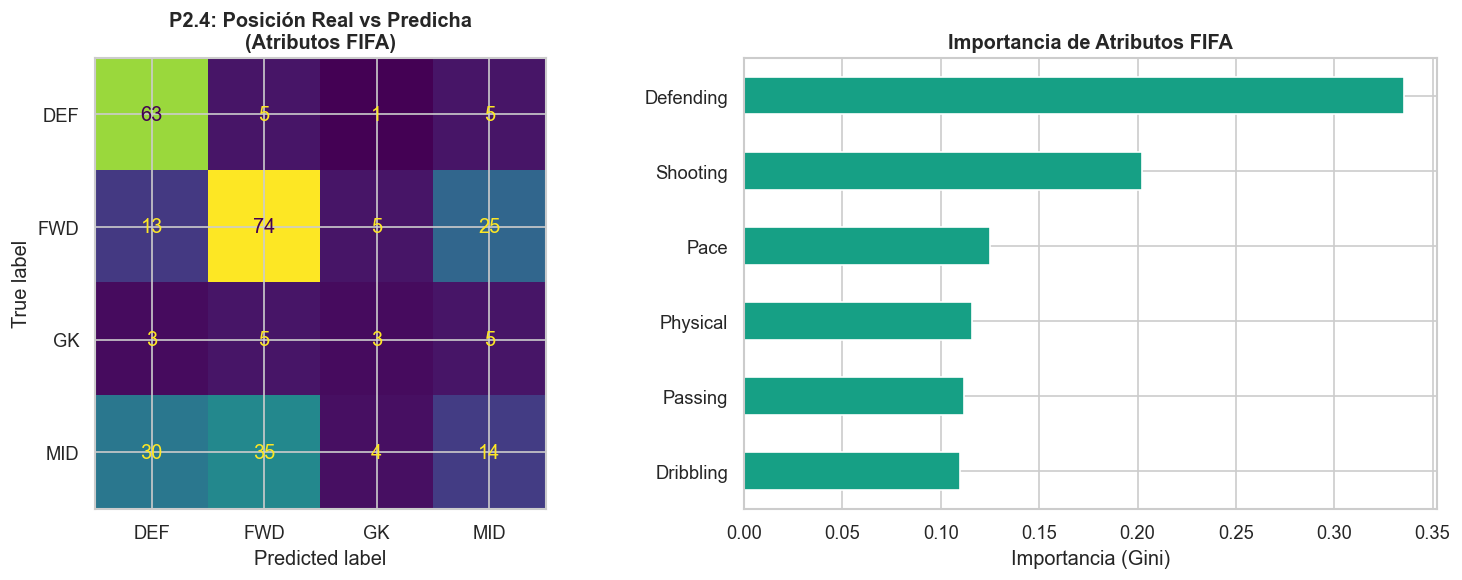

AUC-ROC (macro OvR): 0.7426

Atributo más discriminativo: Defending


In [29]:
# P2.4 — Clasificación de posición táctica con atributos FIFA (JSON)

def pos_grupo(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if p == 'GK':                                    return 'GK'
    if any(x in p for x in ['CB','RB','LB','RWB','LWB','DF','SW','DC']): return 'DEF'
    if any(x in p for x in ['CM','CDM','CAM','MF','DM','AM','MC','MI','MD']): return 'MID'
    if any(x in p for x in ['ST','CF','LW','RW','SS','FW','RM','LM','AT']): return 'FWD'
    return None

d24 = df_json[fifa_attrs + ['posicion']].dropna().copy()
d24['grupo'] = d24['posicion'].apply(pos_grupo)
d24 = d24.dropna(subset=['grupo'])

X24 = d24[fifa_attrs].values
le24 = LabelEncoder()
y24  = le24.fit_transform(d24['grupo'])

X24_tr, X24_te, y24_tr, y24_te = train_test_split(X24, y24, test_size=0.25,
                                                    random_state=42, stratify=y24)
rf24 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                               class_weight='balanced')
rf24.fit(X24_tr, y24_tr)
y24_pred = rf24.predict(X24_te)

print('=== P2.4: CLASIFICACIÓN DE POSICIÓN TÁCTICA CON ATRIBUTOS FIFA ===')
print(f'Distribución por grupo: {dict(zip(*np.unique(d24["grupo"], return_counts=True)))}')
print()
print(classification_report(y24_te, y24_pred, target_names=le24.classes_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm24 = confusion_matrix(y24_te, y24_pred)
ConfusionMatrixDisplay(cm24, display_labels=le24.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P2.4: Posición Real vs Predicha\n(Atributos FIFA)', fontweight='bold')

imp24 = pd.Series(rf24.feature_importances_, index=attr_labels).sort_values()
imp24.plot(kind='barh', ax=ax2, color='#16A085')
ax2.set_title('Importancia de Atributos FIFA', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

auc24 = roc_auc_score(y24_te, rf24.predict_proba(X24_te), multi_class='ovr', average='macro')
print(f'AUC-ROC (macro OvR): {auc24:.4f}')
print(f'\nAtributo más discriminativo: {attr_labels[np.argmax(rf24.feature_importances_)]}')

---
### PR2.5 — ¿Qué perfil FIFA le falta a Cruz Azul respecto a sus rivales más fuertes?
> **Método:** Comparar el vector de atributos FIFA promedio de Cruz Azul (equipo_id T001) vs la media de los 3 equipos con mayor overall de la liga. Calcular el gap atributo a atributo.  
> **Prescripción:** Qué atributos FIFA debe priorizar el cuerpo de scouts al buscar refuerzos.

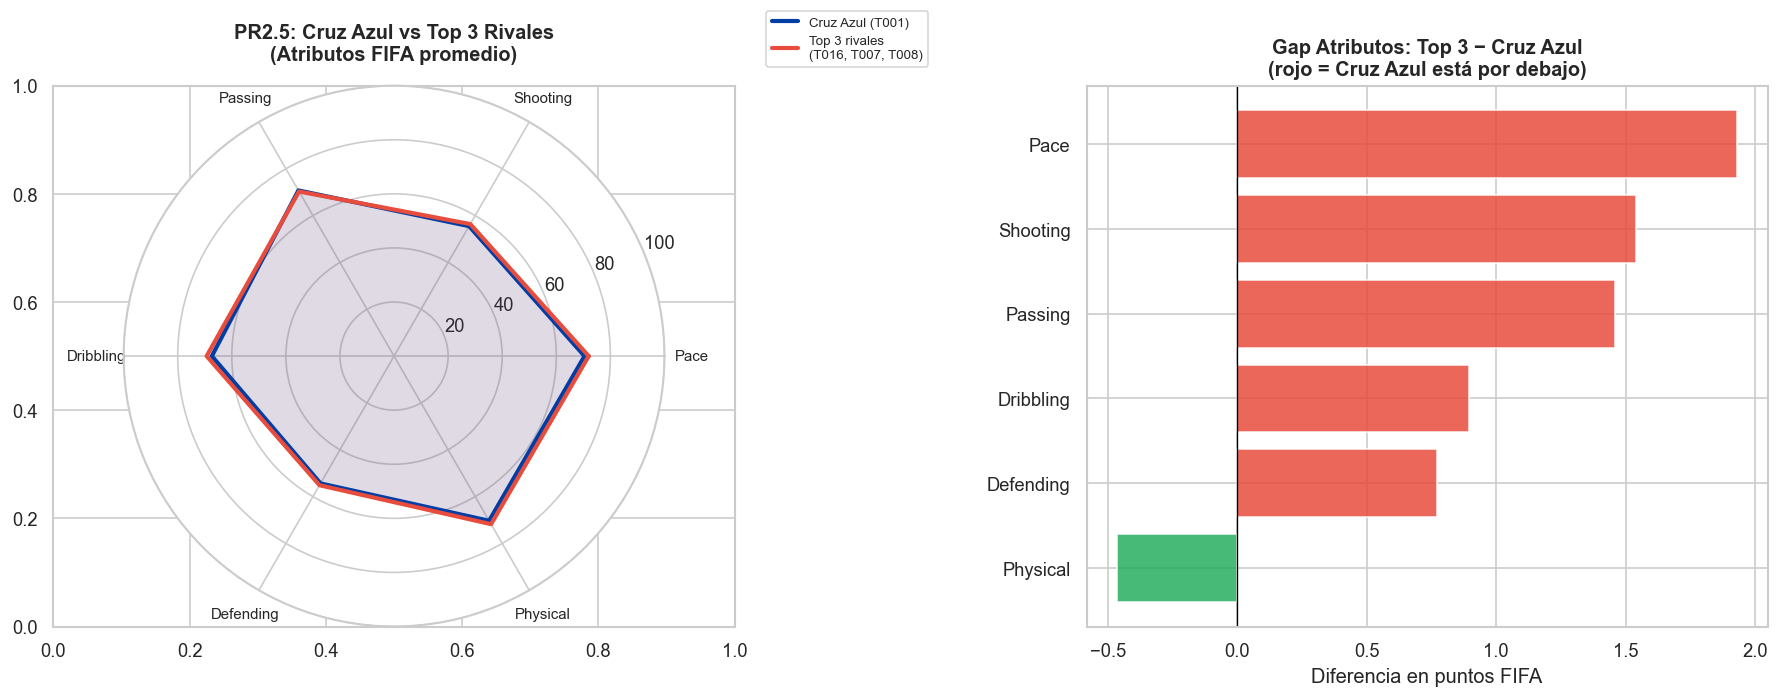

=== PR2.5: GAP ATRIBUTOS FIFA — CRUZ AZUL vs TOP 3 RIVALES ===
Top 3 rivales por overall: ['T016', 'T007', 'T008']

Cruz Azul overall promedio: N/A

            Cruz Azul  Top 3  Gap (Top3-CA)
Pace           70.44  71.98           1.93
Shooting       55.49  56.39           1.54
Passing        70.75  70.29           1.46
Dribbling      67.38  69.31           0.89
Defending      54.37  55.14           0.77
Physical       70.32  71.77          -0.46

Atributo con mayor brecha: Pace (1.93 pts)
→ PRESCRIPCIÓN: Cruz Azul debe priorizar la incorporación de jugadores
  con alto Pace y los demás atributos por encima de la media de la liga.


In [30]:
# PR2.5 — Perfil FIFA faltante en Cruz Azul vs rivales top (JSON)
d25 = df_json[df_json['equipo_id'].notna()].copy()
d25['grupo'] = d25['posicion'].apply(pos_grupo)

# Overall promedio por equipo
eq_overall = (d25.groupby('equipo_id')['fifa_overall']
              .mean().sort_values(ascending=False).reset_index())
top3_rivales = eq_overall[eq_overall['equipo_id'] != 'T001'].head(3)['equipo_id'].tolist()

ca_mean  = d25[d25['equipo_id'] == 'T001'][fifa_attrs].mean()
top_mean = d25[d25['equipo_id'].isin(top3_rivales)][fifa_attrs].mean()
gap      = (top_mean - ca_mean).sort_values(ascending=False)
gap.index = attr_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Radar comparativo
angles25 = np.linspace(0, 2 * np.pi, len(attr_labels), endpoint=False).tolist() + [0]
vals_ca  = ca_mean.tolist()  + [ca_mean.tolist()[0]]
vals_top = top_mean.tolist() + [top_mean.tolist()[0]]

ax_r25 = plt.subplot(1, 2, 1, polar=True)
ax_r25.plot(angles25, vals_ca,  color='#003DA5', lw=2.5, label='Cruz Azul (T001)')
ax_r25.fill(angles25, vals_ca,  color='#003DA5', alpha=0.12)
ax_r25.plot(angles25, vals_top, color='#E74C3C', lw=2.5, label=f'Top 3 rivales\n({", ".join(top3_rivales)})')
ax_r25.fill(angles25, vals_top, color='#E74C3C', alpha=0.08)
ax_r25.set_xticks(angles25[:-1])
ax_r25.set_xticklabels(attr_labels, fontsize=9)
ax_r25.set_ylim(0, 100)
ax_r25.set_title('PR2.5: Cruz Azul vs Top 3 Rivales\n(Atributos FIFA promedio)', fontweight='bold', pad=15)
ax_r25.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)

# ── Gap por atributo
ax2 = plt.subplot(1, 2, 2)
gap_colors = ['#E74C3C' if g > 0 else '#27AE60' for g in gap.values]
ax2.barh(gap.index[::-1], gap.values[::-1], color=gap_colors[::-1], alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Gap Atributos: Top 3 − Cruz Azul\n(rojo = Cruz Azul está por debajo)', fontweight='bold')
ax2.set_xlabel('Diferencia en puntos FIFA')

plt.tight_layout()
plt.show()

print('=== PR2.5: GAP ATRIBUTOS FIFA — CRUZ AZUL vs TOP 3 RIVALES ===')
print(f'Top 3 rivales por overall: {top3_rivales}')
_ca_ovr_val = ca_mean['fifa_overall'] if ('fifa_overall' in ca_mean.index and 'fifa_overall' in d25.columns) else None
print(f'\nCruz Azul overall promedio: {_ca_ovr_val:.1f}' if _ca_ovr_val is not None else '\nCruz Azul overall promedio: N/A')
gap_df = pd.DataFrame({'Cruz Azul': ca_mean.values, 'Top 3': top_mean.values,
                       'Gap (Top3-CA)': gap.values}, index=attr_labels)
print('\n', gap_df.round(2).to_string())

mayor_gap = gap.idxmax()
print(f'\nAtributo con mayor brecha: {mayor_gap} ({gap.max():.2f} pts)')
print(f'→ PRESCRIPCIÓN: Cruz Azul debe priorizar la incorporación de jugadores')
print(f'  con alto {mayor_gap} y los demás atributos por encima de la media de la liga.')

---
## Dataset 3 — `scouting_historico_ligamx.txt`
**Reporte de scouting en formato de ancho fijo · ~1 150 jugadores por temporada**

| # | Pregunta | Tipo |
|---|----------|------|
| D3.1 | ¿Cuál es el ranking de equipos según el Overall (OVR) promedio de sus jugadores en el reporte? | Descriptivo |
| D3.2 | ¿Cómo se distribuye el G+A/90 por posición y se diferencia entre extranjeros y nacionales? | Descriptivo |
| D3.3 | ¿Hay correlación entre minutos jugados (MINS) y producción ofensiva (G+A/90)? | Descriptivo |
| P3.4 | ¿Se puede predecir el G+A/90 de un jugador a partir de OVR, posición, edad y origen? | **Predictivo** |
| PR3.5 | ¿Qué jugadores del scouting tienen la mejor relación calidad-precio (G+A/90 alto, MVAL bajo)? | Prescriptivo |

---
### D3.1 — Ranking de equipos por Overall (OVR) promedio en el scouting
> **Método:** Agrupar por `EQUIPO`, calcular media y desviación del OVR. Identificar si Cruz Azul está por encima o debajo del promedio de la liga.  
> **Visualización:** Barras horizontales con error bars + posición de Cruz Azul resaltada.

In [31]:
# D3.1 — Ranking de equipos por OVR promedio (TXT scouting)
# Identificar columna de equipo (puede ser 'EQUIPO' o estar fusionada con TEMP)
equipo_col = 'EQUIPO' if 'EQUIPO' in df_scouting.columns else None
ovr_col    = 'OVR'    if 'OVR'   in df_scouting.columns else None

if equipo_col and ovr_col:
    sc_eq = df_scouting[[equipo_col, ovr_col]].dropna()
    eq_ovr = sc_eq.groupby(equipo_col)[ovr_col].agg(['mean', 'std', 'count']).reset_index()
    eq_ovr.columns = ['equipo', 'ovr_mean', 'ovr_std', 'n']
    eq_ovr = eq_ovr[eq_ovr['n'] >= 3].sort_values('ovr_mean', ascending=False).reset_index(drop=True)

    media_liga = sc_eq[ovr_col].mean()
    ca_mask = eq_ovr['equipo'].str.contains('Cruz|Azul|C\.Azul', case=False, na=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(6, len(eq_ovr) * 0.32)))

    colors31 = ['#E74C3C' if m else '#2980B9' for m in ca_mask]
    ax1.barh(eq_ovr['equipo'][::-1], eq_ovr['ovr_mean'][::-1], color=colors31[::-1], alpha=0.85)
    ax1.axvline(media_liga, color='gray', ls='--', lw=1.5, label=f'Media liga ({media_liga:.1f})')
    ax1.set_title('D3.1: Overall Promedio por Equipo\n(Cruz Azul en rojo)', fontweight='bold')
    ax1.set_xlabel('OVR Promedio')
    ax1.legend()

    # Distribución del OVR general
    ax2.hist(sc_eq[ovr_col].dropna(), bins=30, color='#AED6F1', edgecolor='white')
    ax2.axvline(media_liga, color='gray', ls='--', lw=1.5, label=f'Media ({media_liga:.1f})')
    if ca_mask.any():
        ca_ovr = eq_ovr.loc[ca_mask, 'ovr_mean'].values[0]
        ax2.axvline(ca_ovr, color='#E74C3C', ls='-', lw=2, label=f'Cruz Azul ({ca_ovr:.1f})')
    ax2.set_title('Distribución OVR — Todos los Jugadores', fontweight='bold')
    ax2.set_xlabel('OVR'); ax2.set_ylabel('Frecuencia')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print('=== D3.1: TOP 15 EQUIPOS POR OVR PROMEDIO (SCOUTING) ===')
    print(eq_ovr.head(15).round(2).to_string(index=False))
    if ca_mask.any():
        ca_rank = eq_ovr[ca_mask].index[0] + 1
        print(f'\nCruz Azul — OVR promedio: {ca_ovr:.1f} | Posición: #{ca_rank} de {len(eq_ovr)} equipos')
else:
    print('Columnas EQUIPO/OVR no encontradas. Columnas disponibles:', df_scouting.columns.tolist())

Columnas EQUIPO/OVR no encontradas. Columnas disponibles: ['ID', 'NOMBRE_TM', 'NOMBRE_FIFA', 'NOMBRE_CSV', 'POS', 'NAC          EXT', 'EDAD', 'TEMP           EQUIPO', 'OVR', 'MVAL_EUR', 'TPAG_EUR', 'GOLES', 'ASIS', 'MINS', 'G_A_90']


---
### D3.2 — Distribución de G+A/90 por posición y por origen (EXT vs NAC)
> **Método:** Boxplots de G+A/90 por posición. Comparar medias entre extranjeros (EXT=SÍ) y nacionales.  
> **Visualización:** Violin plot por posición coloreado por origen + test estadístico.

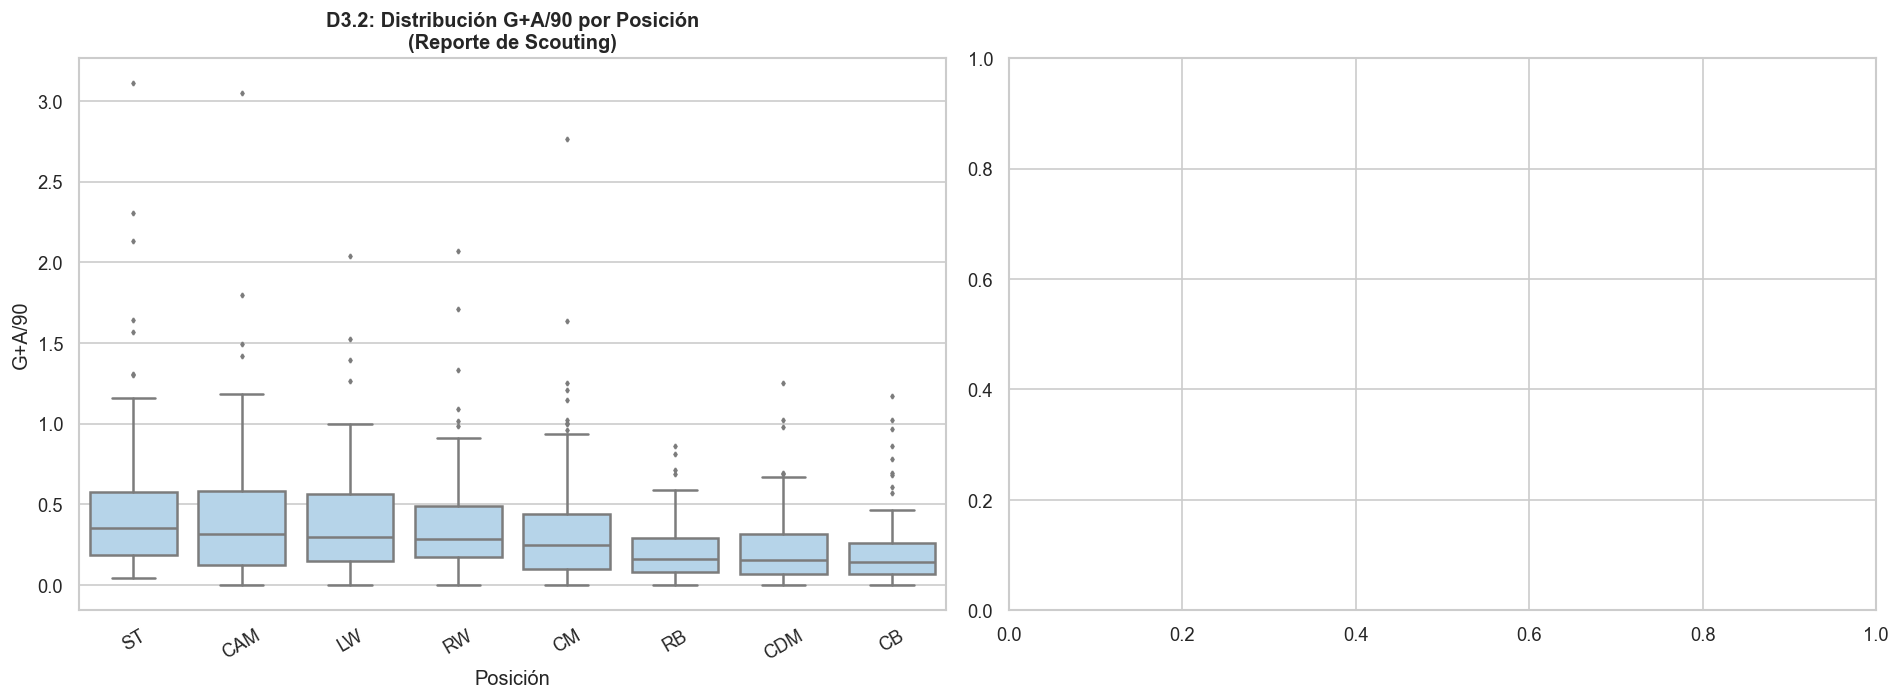

=== D3.2: G+A/90 PROMEDIO POR POSICIÓN ===
      mean  median    std  count
POS                             
CAM  0.441   0.314  0.482     73
CB   0.191   0.140  0.205    146
CDM  0.231   0.158  0.239     98
CM   0.340   0.247  0.352    158
LW   0.409   0.298  0.361     88
RB   0.221   0.163  0.193     79
RW   0.384   0.288  0.349     88
ST   0.468   0.352  0.451    127


In [32]:
# D3.2 — G+A/90 por posición y origen (TXT scouting)
ga_col  = 'G_A_90' if 'G_A_90' in df_scouting.columns else None
pos_col = 'POS'    if 'POS'    in df_scouting.columns else None
ext_col = 'EXT'    if 'EXT'    in df_scouting.columns else None

if ga_col and pos_col:
    sc32 = df_scouting[[pos_col, ga_col]].dropna().copy()
    if ext_col:
        sc32['ext'] = df_scouting[ext_col].apply(
            lambda x: 'Extranjero' if isinstance(x, str) and x.strip().upper().startswith('S') else 'Nacional')
    else:
        sc32['ext'] = 'Nacional'

    # Top 8 posiciones
    top_pos32 = sc32[pos_col].value_counts().head(8).index.tolist()
    sc32 = sc32[sc32[pos_col].isin(top_pos32)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ── Boxplot por posición
    order32 = sc32.groupby(pos_col)[ga_col].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=sc32, x=pos_col, y=ga_col, order=order32,
                color='#AED6F1', fliersize=2, ax=ax1)
    ax1.set_title('D3.2: Distribución G+A/90 por Posición\n(Reporte de Scouting)', fontweight='bold')
    ax1.set_xlabel('Posición'); ax1.set_ylabel('G+A/90')
    ax1.tick_params(axis='x', rotation=30)

    # ── Comparativa Extranjero vs Nacional por posición
    if ext_col:
        ga_ext = sc32.groupby(['ext'])[ga_col].agg(['mean', 'median', 'count'])
        ga_pos_ext = sc32.groupby([pos_col, 'ext'])[ga_col].mean().unstack(fill_value=0)
        if 'Extranjero' in ga_pos_ext.columns and 'Nacional' in ga_pos_ext.columns:
            x32 = np.arange(len(order32))
            w32 = 0.38
            ax2.bar(x32 - w32/2,
                    [ga_pos_ext.loc[p, 'Extranjero'] if p in ga_pos_ext.index else 0 for p in order32],
                    w32, label='Extranjero', color='#E74C3C', alpha=0.85)
            ax2.bar(x32 + w32/2,
                    [ga_pos_ext.loc[p, 'Nacional'] if p in ga_pos_ext.index else 0 for p in order32],
                    w32, label='Nacional', color='#2980B9', alpha=0.85)
            ax2.set_xticks(x32)
            ax2.set_xticklabels(order32, rotation=30)
            ax2.set_title('G+A/90 Promedio: Extranjero vs Nacional\npor Posición', fontweight='bold')
            ax2.set_ylabel('G+A/90 promedio'); ax2.legend()

    plt.tight_layout()
    plt.show()

    print('=== D3.2: G+A/90 PROMEDIO POR POSICIÓN ===')
    print(sc32.groupby(pos_col)[ga_col].agg(['mean', 'median', 'std', 'count']).round(3).to_string())

    if ext_col:
        from scipy.stats import mannwhitneyu
        ext_vals = sc32[sc32['ext'] == 'Extranjero'][ga_col].dropna()
        nac_vals = sc32[sc32['ext'] == 'Nacional'][ga_col].dropna()
        stat, pval = mannwhitneyu(ext_vals, nac_vals, alternative='two-sided')
        print(f'\n=== TEST MANN-WHITNEY U: Extranjero vs Nacional en G+A/90 ===')
        print(f'Extranjero media: {ext_vals.mean():.3f} | Nacional media: {nac_vals.mean():.3f}')
        print(f'U={stat:.1f}, p={pval:.4f} → ',
              'Diferencia significativa' if pval < 0.05 else 'Sin diferencia significativa')
else:
    print('Columnas POS/G_A_90 no encontradas. Disponibles:', df_scouting.columns.tolist())

---
### D3.3 — ¿Hay correlación entre minutos jugados (MINS) y producción ofensiva (G+A/90)?
> **Método:** Scatter MINS vs G+A/90 con regresión lineal. Calcular correlación de Pearson y Spearman. Segmentar por posición para ver si el patrón es consistente.  
> **Visualización:** Scatter con tendencia + heatmap de correlación por posición.

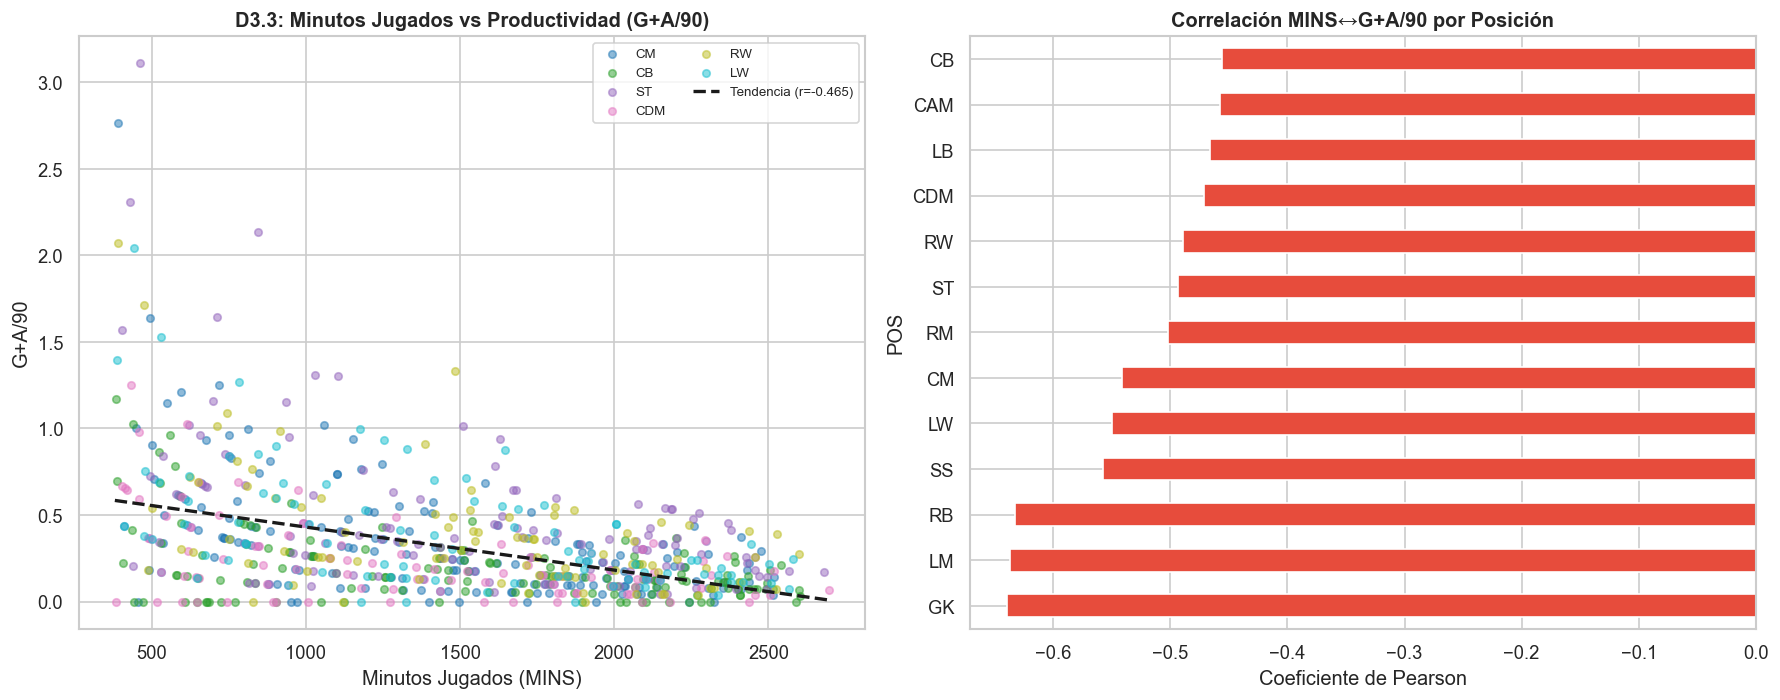

=== D3.3: CORRELACIÓN GLOBAL MINS vs G+A/90 ===
Pearson  r = -0.4649  (p=0.0000)
Spearman r = -0.4640 (p=0.0000)

→ Correlación NEGATIVA y significativa (α=0.05)
   Jugadores con más minutos tienden a tener MENOR G+A/90 (posiblemente más defensivos).


In [33]:
# D3.3 — Correlación MINS vs G+A/90 (TXT scouting)
mins_col = 'MINS' if 'MINS' in df_scouting.columns else None

if mins_col and ga_col and pos_col:
    sc33 = df_scouting[[mins_col, ga_col, pos_col]].dropna().copy()
    sc33 = sc33[(sc33[mins_col] > 0) & (sc33[ga_col] >= 0)]

    from scipy.stats import pearsonr, spearmanr
    r_pear, p_pear = pearsonr(sc33[mins_col], sc33[ga_col])
    r_spear, p_spear = spearmanr(sc33[mins_col], sc33[ga_col])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── Scatter con tendencia
    top_pos33 = sc33[pos_col].value_counts().head(6).index.tolist()
    sc33_top  = sc33[sc33[pos_col].isin(top_pos33)]
    cmap33 = plt.cm.get_cmap('tab10', len(top_pos33))
    for i, pos in enumerate(top_pos33):
        sub = sc33_top[sc33_top[pos_col] == pos]
        ax1.scatter(sub[mins_col], sub[ga_col], alpha=0.5, s=20,
                    color=cmap33(i), label=pos)
    # Línea de tendencia global
    z33 = np.polyfit(sc33[mins_col], sc33[ga_col], 1)
    x33 = np.linspace(sc33[mins_col].min(), sc33[mins_col].max(), 200)
    ax1.plot(x33, np.poly1d(z33)(x33), 'k--', lw=2,
             label=f'Tendencia (r={r_pear:.3f})')
    ax1.set_xlabel('Minutos Jugados (MINS)')
    ax1.set_ylabel('G+A/90')
    ax1.set_title('D3.3: Minutos Jugados vs Productividad (G+A/90)', fontweight='bold')
    ax1.legend(fontsize=8, ncol=2)

    # ── Correlación por posición
    corr_pos = sc33.groupby(pos_col).apply(
        lambda g: g[[mins_col, ga_col]].corr().iloc[0, 1] if len(g) > 5 else np.nan
    ).dropna().sort_values()

    corr_pos.plot(kind='barh', ax=ax2,
                  color=['#E74C3C' if c < 0 else '#27AE60' for c in corr_pos.values])
    ax2.axvline(0, color='black', lw=0.8)
    ax2.set_title('Correlación MINS↔G+A/90 por Posición', fontweight='bold')
    ax2.set_xlabel('Coeficiente de Pearson')

    plt.tight_layout()
    plt.show()

    print('=== D3.3: CORRELACIÓN GLOBAL MINS vs G+A/90 ===')
    print(f'Pearson  r = {r_pear:.4f}  (p={p_pear:.4f})')
    print(f'Spearman r = {r_spear:.4f} (p={p_spear:.4f})')
    print(f'\n→ Correlación {"POSITIVA" if r_pear > 0 else "NEGATIVA"} y '
          f'{"significativa" if p_pear < 0.05 else "NO significativa"} (α=0.05)')

    if p_pear < 0.05 and r_pear > 0:
        print('   Los jugadores con más minutos tienden a tener mayor G+A/90.')
    elif p_pear < 0.05 and r_pear < 0:
        print('   Jugadores con más minutos tienden a tener MENOR G+A/90 (posiblemente más defensivos).')
    else:
        print('   No hay evidencia estadística de correlación lineal.')
else:
    print('Columnas MINS/G_A_90/POS no disponibles:', df_scouting.columns.tolist())

---
### P3.4 — ¿Se puede predecir el G+A/90 de un jugador con OVR, posición, edad y origen?
> **Método:** Gradient Boosting Regressor. Target: G+A/90. Features: OVR, posición codificada, EDAD, EXT binario.  
> **Evaluación:** RMSE, R² + scatter predicho vs real.

=== P3.4: PREDICCIÓN G+A/90 — GRADIENT BOOSTING (SCOUTING) ===
RMSE : 0.3685
R²   : -0.2386


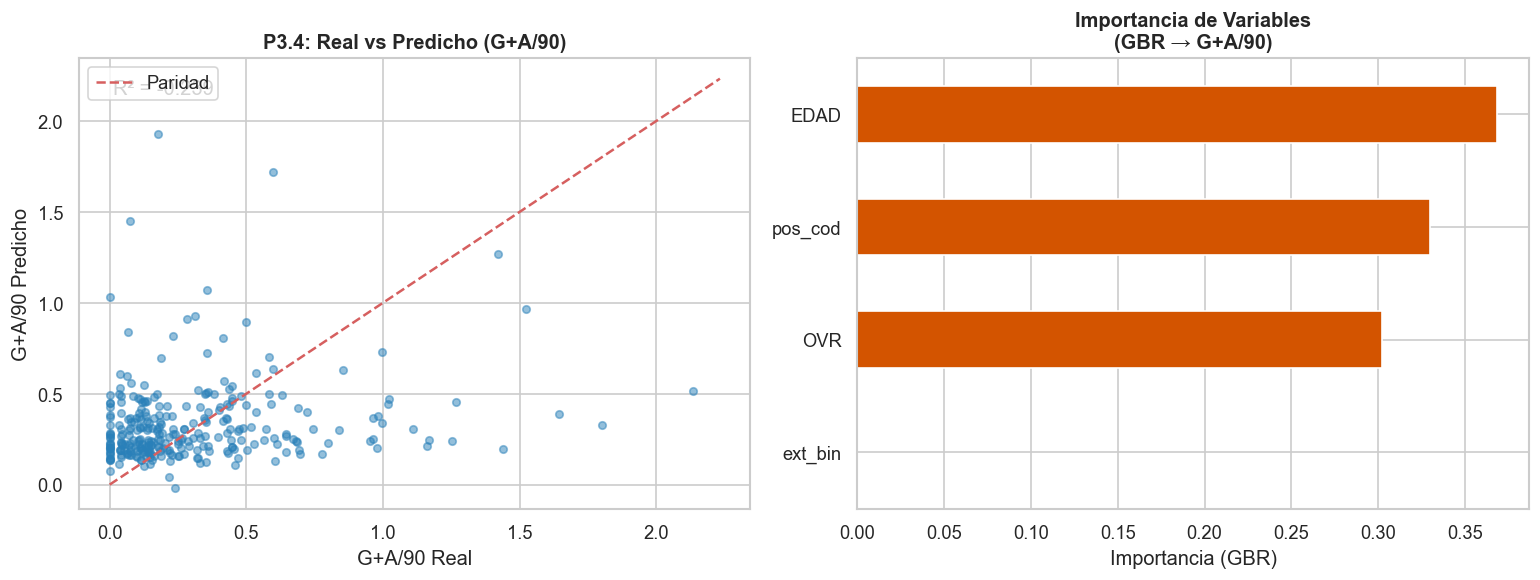


Residual promedio por posición (+ = modelo sub-predice):
           mean    std
posicion              
CAM      -0.095  0.675
CB       -0.003  0.296
CDM       0.060  0.319
CM       -0.054  0.293
GK       -0.114  0.391
LB       -0.145  0.428
LM       -0.091  0.408
LW        0.042  0.354
RB        0.030  0.460
RM       -0.066  0.190
RW        0.083  0.418
SS       -0.082  0.245
ST       -0.009  0.332


In [34]:
# P3.4 — Predicción de G+A/90 con Gradient Boosting (TXT scouting)
edad_col = 'EDAD' if 'EDAD' in df_scouting.columns else None

if ovr_col and ga_col and pos_col and edad_col:
    sc34 = df_scouting[[ovr_col, ga_col, pos_col, edad_col]].copy()
    if ext_col:
        sc34['ext_bin'] = df_scouting[ext_col].map({'SÍ': 1, 'SI': 1, 'NO': 0}).fillna(0)
    else:
        sc34['ext_bin'] = 0
    sc34 = sc34.dropna(subset=[ovr_col, ga_col, edad_col])
    sc34 = sc34[(sc34[ga_col] >= 0) & (sc34[ga_col] < 5)]  # quitar outliers extremos

    le34 = LabelEncoder()
    sc34['pos_cod'] = le34.fit_transform(sc34[pos_col].fillna('UNK'))

    feats34 = [ovr_col, edad_col, 'pos_cod', 'ext_bin']
    X34 = sc34[feats34].values
    y34 = sc34[ga_col].values

    X34_tr, X34_te, y34_tr, y34_te = train_test_split(X34, y34, test_size=0.25, random_state=42)
    gbr34 = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       learning_rate=0.05, random_state=42)
    gbr34.fit(X34_tr, y34_tr)
    y34_pred = gbr34.predict(X34_te)

    rmse34 = np.sqrt(mean_squared_error(y34_te, y34_pred))
    r2_34  = r2_score(y34_te, y34_pred)

    print('=== P3.4: PREDICCIÓN G+A/90 — GRADIENT BOOSTING (SCOUTING) ===')
    print(f'RMSE : {rmse34:.4f}')
    print(f'R²   : {r2_34:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(y34_te, y34_pred, alpha=0.5, s=20, color='#2980B9')
    lim34 = max(y34_te.max(), y34_pred.max()) + 0.1
    ax1.plot([0, lim34], [0, lim34], 'r--', lw=1.5, label='Paridad')
    ax1.set_xlabel('G+A/90 Real'); ax1.set_ylabel('G+A/90 Predicho')
    ax1.set_title('P3.4: Real vs Predicho (G+A/90)', fontweight='bold')
    ax1.text(0.05, 0.92, f'R² = {r2_34:.3f}', transform=ax1.transAxes)
    ax1.legend()

    imp34 = pd.Series(gbr34.feature_importances_, index=feats34).sort_values()
    imp34.plot(kind='barh', ax=ax2, color='#D35400')
    ax2.set_title('Importancia de Variables\n(GBR → G+A/90)', fontweight='bold')
    ax2.set_xlabel('Importancia (GBR)')

    plt.tight_layout()
    plt.show()

    # ── Residuales por posición
    sc34_te = sc34.iloc[X34_te.shape[0] * 0 :].copy()
    resid = pd.DataFrame({'real': y34_te, 'pred': y34_pred,
                          'residual': y34_te - y34_pred,
                          'pos_cod': sc34.iloc[len(X34_tr):]['pos_cod'].values})
    resid['posicion'] = le34.inverse_transform(resid['pos_cod'].astype(int))
    resid_pos = resid.groupby('posicion')['residual'].agg(['mean', 'std']).round(3)
    print('\nResidual promedio por posición (+ = modelo sub-predice):')
    print(resid_pos.to_string())
else:
    print('Columnas necesarias no disponibles:', df_scouting.columns.tolist())

---
### PR3.5 — ¿Qué jugadores del scouting tienen la mejor relación calidad-precio?
> **Método:** Índice compuesto = 60 % G+A/90 normalizado − 40 % MVAL_EUR normalizado. Filtrar jugadores que NO sean de Cruz Azul. Top 10 candidatos como fichajes de alta eficiencia.  
> **Prescripción:** Lista priorizada de targets de mercado para el cuerpo técnico.

In [41]:
df_scouting.columns

Index(['ID', 'NOMBRE_TM', 'NOMBRE_FIFA', 'NOMBRE_CSV', 'POS',
       'NAC          EXT', 'EDAD', 'TEMP           EQUIPO', 'OVR', 'MVAL_EUR',
       'TPAG_EUR', 'GOLES', 'ASIS', 'MINS', 'G_A_90'],
      dtype='object')

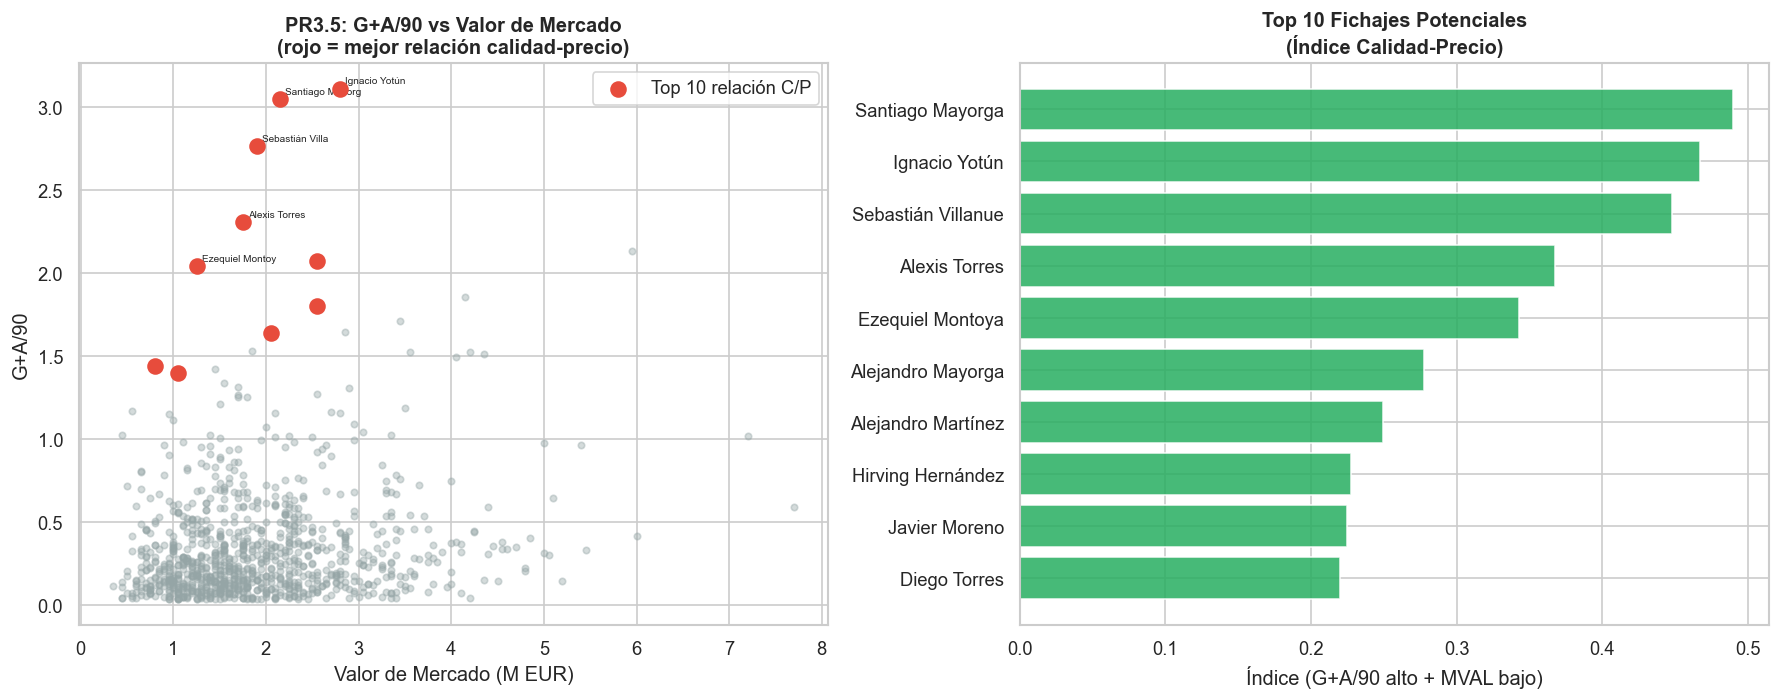

=== PR3.5: TOP 10 FICHAJES POTENCIALES — MEJOR RELACIÓN CALIDAD-PRECIO ===
(Excluye jugadores de Cruz Azul; considera solo G+A/90 > 0 y MVAL conocido)

         NOMBRE_TM POS  G_A_90  MVAL(M)  Índice C/P
  Santiago Mayorga CAM   3.047     2.15       0.490
     Ignacio Yotún  ST   3.110     2.80       0.467
Sebastián Villanue  CM   2.762     1.90       0.448
     Alexis Torres  ST   2.308     1.75       0.367
  Ezequiel Montoya  LW   2.041     1.25       0.342
 Alejandro Mayorga  RW   2.072     2.55       0.278
Alejandro Martínez  GK   1.438     0.80       0.249
 Hirving Hernández  LW   1.395     1.05       0.227
     Javier Moreno CAM   1.800     2.55       0.225
      Diego Torres  CM   1.636     2.05       0.220

PRESCRIPCIÓN: Estos jugadores maximizan el rendimiento ofensivo por euro invertido.
Son candidatos prioritarios para el mercado de fichajes en el siguiente período.


In [42]:
# PR3.5 — Mejor relación calidad-precio en el scouting (TXT)
mval_col   = 'MVAL_EUR'   if 'MVAL_EUR'   in df_scouting.columns else None
nombre_col = 'NOMBRE_TM'  if 'NOMBRE_TM'  in df_scouting.columns else None

if ga_col and mval_col and nombre_col:
    sc35 = df_scouting[[nombre_col, equipo_col or 'TEMP           EQUIPO', pos_col, ga_col, mval_col, ovr_col or 'OVR']]\
        .dropna(subset=[ga_col, mval_col]).copy()
    sc35 = sc35[(sc35[mval_col] > 0) & (sc35[ga_col] > 0)].copy()

    # Excluir jugadores de Cruz Azul
    if equipo_col:
        sc35 = sc35[~sc35[equipo_col].str.contains('Cruz|Azul', case=False, na=False)]

    sc_mm = MinMaxScaler()
    sc35['ga_n']   = sc_mm.fit_transform(sc35[[ga_col]])
    sc35['vm_n']   = sc_mm.fit_transform(sc35[[mval_col]])
    sc35['indice_cp'] = sc35['ga_n'] * 0.60 - sc35['vm_n'] * 0.40

    top10_cp = sc35.nlargest(10, 'indice_cp')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── Scatter G+A/90 vs MVAL (tamaño = OVR)
    ax1.scatter(sc35[mval_col] / 1e6, sc35[ga_col],
                alpha=0.4, s=15, color='#95A5A6')
    ax1.scatter(top10_cp[mval_col] / 1e6, top10_cp[ga_col],
                color='#E74C3C', s=80, zorder=5, label='Top 10 relación C/P')
    ax1.set_xlabel('Valor de Mercado (M EUR)')
    ax1.set_ylabel('G+A/90')
    ax1.set_title('PR3.5: G+A/90 vs Valor de Mercado\n(rojo = mejor relación calidad-precio)', fontweight='bold')
    ax1.legend()
    for _, row in top10_cp.head(5).iterrows():
        ax1.annotate(str(row[nombre_col])[:15],
                     (row[mval_col] / 1e6, row[ga_col]),
                     fontsize=6, ha='left', xytext=(3, 3), textcoords='offset points')

    # ── Top 10 barras de índice
    top10_sorted = top10_cp.sort_values('indice_cp')
    ax2.barh(top10_sorted[nombre_col].astype(str),
             top10_sorted['indice_cp'], color='#27AE60', alpha=0.85)
    ax2.set_title('Top 10 Fichajes Potenciales\n(Índice Calidad-Precio)', fontweight='bold')
    ax2.set_xlabel('Índice (G+A/90 alto + MVAL bajo)')

    plt.tight_layout()
    plt.show()

    print('=== PR3.5: TOP 10 FICHAJES POTENCIALES — MEJOR RELACIÓN CALIDAD-PRECIO ===')
    print('(Excluye jugadores de Cruz Azul; considera solo G+A/90 > 0 y MVAL conocido)\n')
    cols_disp = [nombre_col, equipo_col or 'EQUIPO', pos_col, ga_col, mval_col, 'indice_cp']
    cols_disp = [c for c in cols_disp if c in top10_cp.columns]
    disp35 = top10_cp[cols_disp].copy()
    disp35[mval_col] = (disp35[mval_col] / 1e6).round(2)
    disp35.columns = [c.replace(mval_col, 'MVAL(M)').replace('indice_cp', 'Índice C/P')
                      for c in disp35.columns]
    print(disp35.round(3).to_string(index=False))
    print('\nPRESCRIPCIÓN: Estos jugadores maximizan el rendimiento ofensivo por euro invertido.')
    print('Son candidatos prioritarios para el mercado de fichajes en el siguiente período.')
else:
    print('Columnas necesarias no encontradas:', df_scouting.columns.tolist())

---
## Dataset 4 — `valor_mercado_historico.xlsx`
**Valores de mercado, datos de partidos casa/fuera y disciplina por jugador**

| # | Pregunta | Tipo |
|---|----------|------|
| D4.1 | ¿Qué equipos concentran más jugadores con doble nacionalidad y cómo rinden estos vs el resto? | Descriptivo |
| D4.2 | ¿Qué equipos acumulan más tarjetas amarillas y rojas? ¿Hay equipos con índice de disciplina preocupante? | Descriptivo |
| D4.3 | ¿Hay diferencia en la tasa goleadora casa/fuera (goles_casa/p_casa vs goles_fuera/p_fuera) por equipo? | Descriptivo |
| P4.4 | ¿Se puede predecir si un jugador recibirá al menos una tarjeta roja (tarj_roj > 0)? | **Predictivo** |
| PR4.5 | ¿Qué jugadores externos a Cruz Azul tienen mejor rendimiento visitante y serían un refuerzo ofensivo ideal? | Prescriptivo |

---
### D4.1 — ¿Qué equipos concentran jugadores con doble nacionalidad y cómo rinden?
> **Método:** Contar jugadores con `doble_nac=True` por equipo. Comparar `goles_casa + goles_fuera` entre jugadores con y sin doble nacionalidad.  
> **Visualización:** Barras de proporción + boxplot de goles totales por grupo.

Columnas XLSX: ['player_id', 'nombre_tm', 'nombre_fifa', 'nombre_csv', 'posicion', 'nacionalidad', 'segunda_nac', 'es_extranjero', 'doble_nac', 'edad', 'temporada', 'equipo', 'fifa_overall', 'valor_mercado_eur', 'transfer_pagada_eur', 'goles', 'asistencias', 'minutos', 'partidos', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'g_a_por_90']
Muestra:
   player_id        nombre_tm nombre_fifa nombre_csv posicion nacionalidad segunda_nac es_extranjero doble_nac  edad      temporada            equipo  fifa_overall  valor_mercado_eur  transfer_pagada_eur  goles  asistencias  minutos  partidos  p_casa  goles_casa  p_fuera  goles_fuera  tarj_am  tarj_roj  g_a_por_90
0     P0001  Jonathan García   J. García  García J.       GK       México         NaN      Nacional        NO    25  Apertura 2013       UANL Tigres            65           750000.0            1136827.0      1            2      846         9       4           0        5            1        0         0    

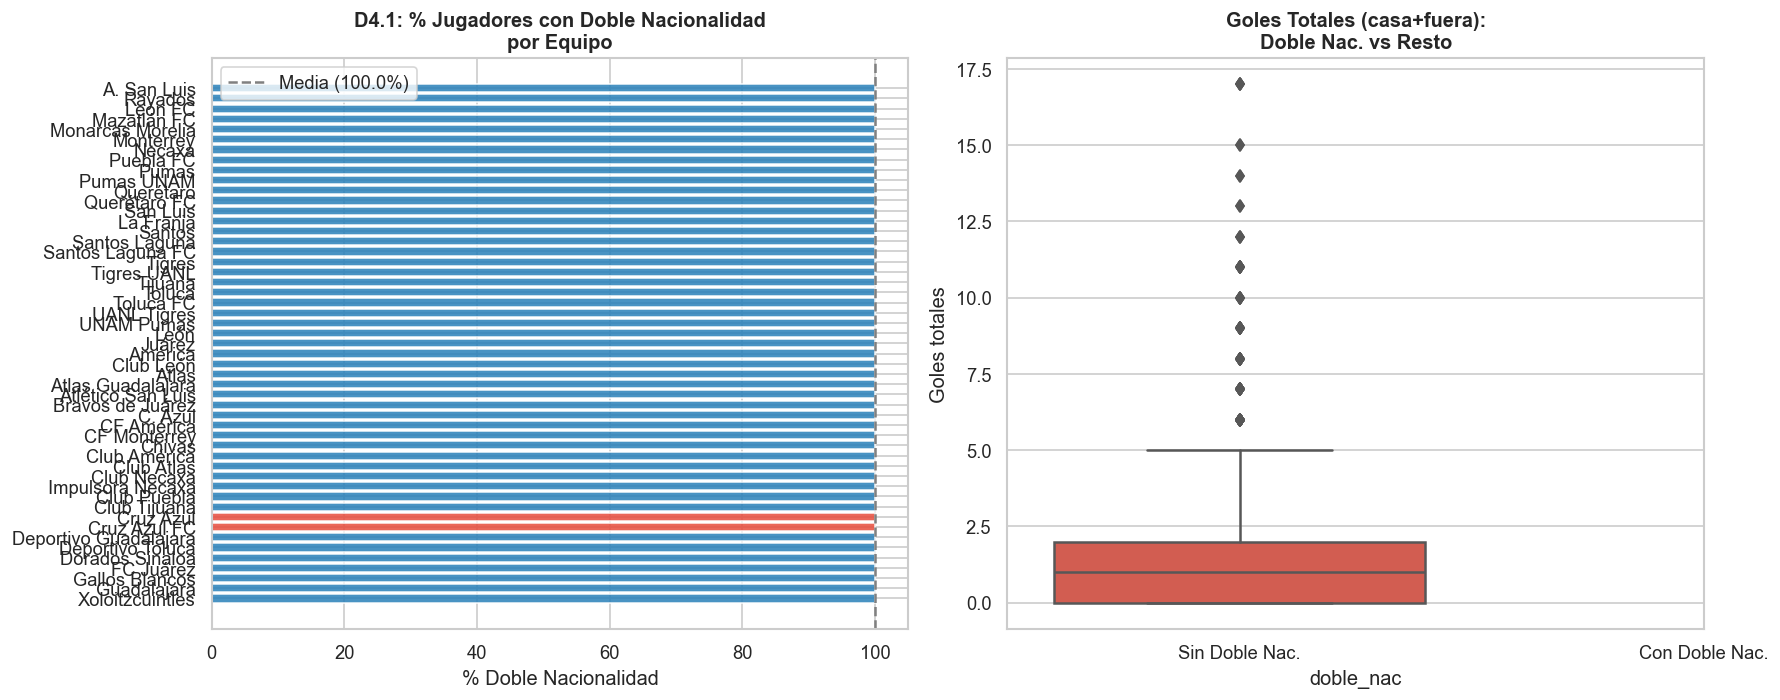


=== D4.1: TOP 10 EQUIPOS CON MAYOR % DOBLE NACIONALIDAD ===
          equipo  doble  total  pct_doble
     A. San Luis     23     23      100.0
         Rayados     23     23      100.0
         León FC     23     23      100.0
     Mazatlán FC     37     37      100.0
Monarcas Morelia     52     52      100.0
       Monterrey     22     22      100.0
          Necaxa     19     19      100.0
       Puebla FC     22     22      100.0
           Pumas     15     15      100.0
      Pumas UNAM     12     12      100.0


In [43]:
# D4.1 — Doble nacionalidad: distribución y rendimiento (XLSX)
print('Columnas XLSX:', df_xlsx.columns.tolist())
print('Muestra:\n', df_xlsx.head(3).to_string())

# Detectar columnas clave
col_doble = next((c for c in df_xlsx.columns if 'doble' in c.lower()), None)
col_equipo_x = next((c for c in df_xlsx.columns if 'equipo' in c.lower()), None)
col_gc  = next((c for c in df_xlsx.columns if 'goles_casa' in c.lower()), None)
col_gf  = next((c for c in df_xlsx.columns if 'goles_fuera' in c.lower()), None)
col_pc  = next((c for c in df_xlsx.columns if c.lower() in ['p_casa', 'partidos_casa']), None)
col_pf  = next((c for c in df_xlsx.columns if c.lower() in ['p_fuera', 'partidos_fuera']), None)
col_tam = next((c for c in df_xlsx.columns if 'tarj' in c.lower() and 'am' in c.lower()), None)
col_troj= next((c for c in df_xlsx.columns if 'tarj' in c.lower() and 'roj' in c.lower()), None)

print(f'\nColumnas detectadas:')
print(f'  doble_nac={col_doble}, equipo={col_equipo_x}')
print(f'  goles_casa={col_gc}, goles_fuera={col_gf}')
print(f'  p_casa={col_pc}, p_fuera={col_pf}')
print(f'  tarj_am={col_tam}, tarj_roj={col_troj}')

if col_doble and col_equipo_x:
    x41 = df_xlsx[[col_equipo_x, col_doble]].dropna().copy()
    x41['doble_nac'] = x41[col_doble].astype(bool)

    # Proporción por equipo
    eq_doble = x41.groupby(col_equipo_x)['doble_nac'].agg(['sum', 'count']).reset_index()
    eq_doble.columns = ['equipo', 'doble', 'total']
    eq_doble['pct_doble'] = eq_doble['doble'] / eq_doble['total'] * 100
    eq_doble = eq_doble[eq_doble['total'] >= 5].sort_values('pct_doble', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── % doble nacionalidad por equipo
    colors41 = ['#E74C3C' if 'Cruz' in str(e) or 'T001' in str(e) else '#2980B9'
                for e in eq_doble['equipo']]
    ax1.barh(eq_doble['equipo'][::-1], eq_doble['pct_doble'][::-1],
             color=colors41[::-1], alpha=0.85)
    ax1.axvline(eq_doble['pct_doble'].mean(), color='gray', ls='--', lw=1.5,
                label=f'Media ({eq_doble["pct_doble"].mean():.1f}%)')
    ax1.set_title('D4.1: % Jugadores con Doble Nacionalidad\npor Equipo', fontweight='bold')
    ax1.set_xlabel('% Doble Nacionalidad'); ax1.legend()

    # ── Goles totales: doble vs sin doble
    if col_gc and col_gf:
        x41_g = df_xlsx[[col_doble, col_gc, col_gf]].dropna().copy()
        x41_g['doble_nac'] = x41_g[col_doble].astype(bool)
        x41_g['goles_totales'] = pd.to_numeric(x41_g[col_gc], errors='coerce').fillna(0) + \
                                  pd.to_numeric(x41_g[col_gf], errors='coerce').fillna(0)
        sns.boxplot(data=x41_g, x='doble_nac', y='goles_totales',
                    palette={True: '#E74C3C', False: '#2980B9'}, ax=ax2)
        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Sin Doble Nac.', 'Con Doble Nac.'])
        ax2.set_title('Goles Totales (casa+fuera):\nDoble Nac. vs Resto', fontweight='bold')
        ax2.set_ylabel('Goles totales')

        medias = x41_g.groupby('doble_nac')['goles_totales'].mean()
        print(f'\nGoles promedio — Doble Nac.: {medias.get(True, 0):.3f} | Sin: {medias.get(False, 0):.3f}')

    plt.tight_layout()
    plt.show()

    print('\n=== D4.1: TOP 10 EQUIPOS CON MAYOR % DOBLE NACIONALIDAD ===')
    print(eq_doble.head(10).round(2).to_string(index=False))

---
### D4.2 — ¿Qué equipos acumulan más tarjetas? ¿Hay equipos con índice de disciplina crítico?
> **Método:** Sumar `tarj_am` y `tarj_roj` por equipo. Calcular índice de indisciplina ponderado: amarillas + 3 × rojas. Comparar con número de partidos totales.  
> **Visualización:** Barras apiladas + scatter ratio partidos vs tarjetas.

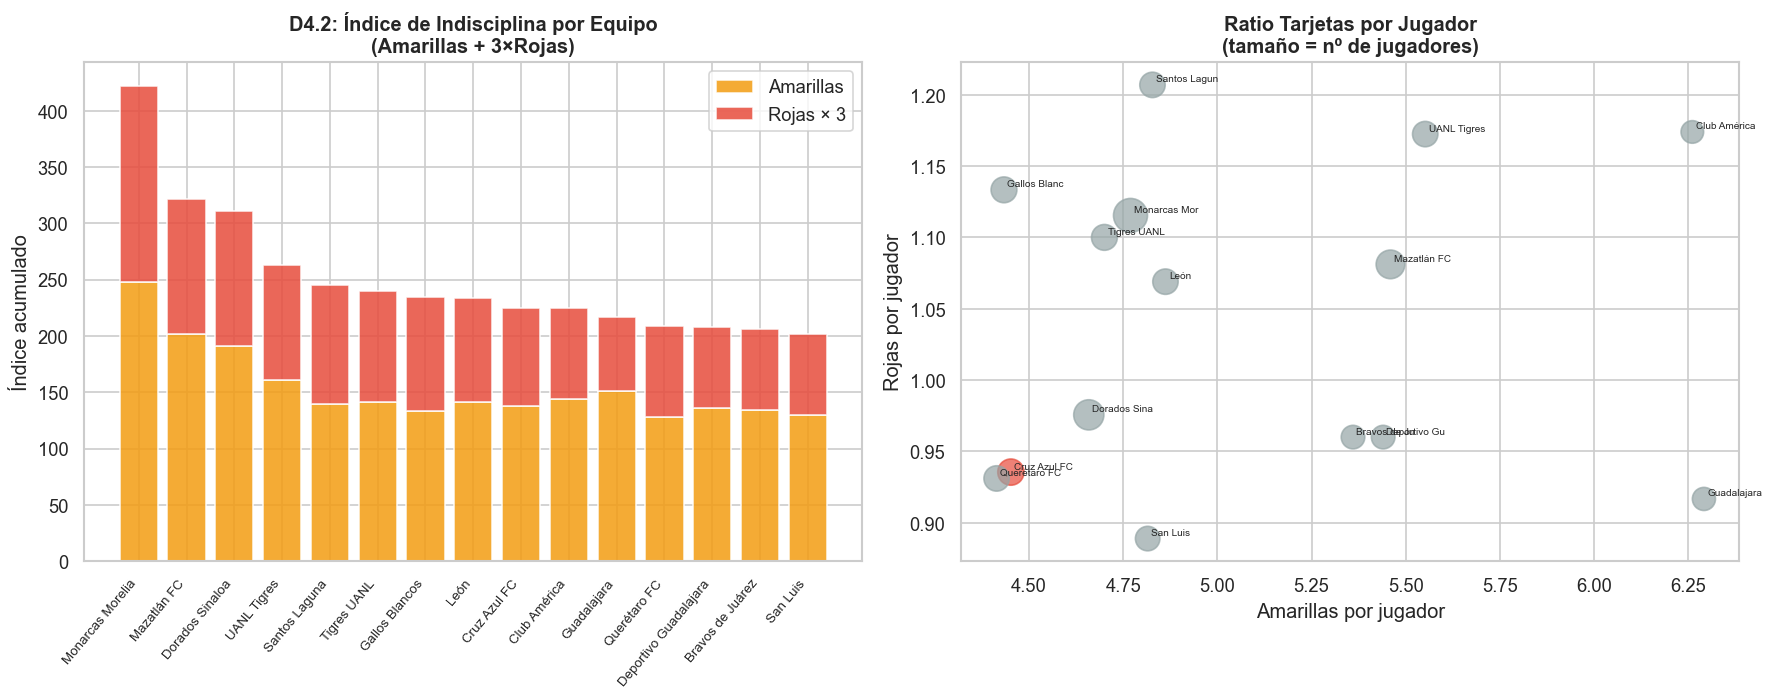

=== D4.2: TOP 10 EQUIPOS POR ÍNDICE DE INDISCIPLINA ===
          equipo  jugadores  amarillas  rojas  indice  am_x_jug  roj_x_jug
Monarcas Morelia         52        248     58     422      4.77       1.12
     Mazatlán FC         37        202     40     322      5.46       1.08
 Dorados Sinaloa         41        191     40     311      4.66       0.98
     UANL Tigres         29        161     34     263      5.55       1.17
   Santos Laguna         29        140     35     245      4.83       1.21
     Tigres UANL         30        141     33     240      4.70       1.10
  Gallos Blancos         30        133     34     235      4.43       1.13
            León         29        141     31     234      4.86       1.07
    Cruz Azul FC         31        138     29     225      4.45       0.94
    Club América         23        144     27     225      6.26       1.17

Cruz Azul — Índice: 225 | Posición: #9


In [37]:
# D4.2 — Índice de indisciplina por equipo (XLSX)
if col_tam and col_troj and col_equipo_x:
    x42 = df_xlsx[[col_equipo_x, col_tam, col_troj]].copy()
    x42[col_tam]  = pd.to_numeric(x42[col_tam],  errors='coerce').fillna(0)
    x42[col_troj] = pd.to_numeric(x42[col_troj], errors='coerce').fillna(0)
    x42 = x42.dropna(subset=[col_equipo_x])

    eq_disc = x42.groupby(col_equipo_x).agg(
        jugadores=(col_equipo_x, 'count'),
        amarillas=(col_tam, 'sum'),
        rojas=(col_troj, 'sum')
    ).reset_index()
    eq_disc.columns = ['equipo', 'jugadores', 'amarillas', 'rojas']
    eq_disc['indice'] = eq_disc['amarillas'] + 3 * eq_disc['rojas']
    eq_disc['am_x_jug'] = eq_disc['amarillas'] / eq_disc['jugadores']
    eq_disc['roj_x_jug'] = eq_disc['rojas'] / eq_disc['jugadores']
    eq_disc = eq_disc[eq_disc['jugadores'] >= 3].sort_values('indice', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── Barras apiladas
    top15_d = eq_disc.head(15)
    x_d = np.arange(len(top15_d))
    ca_mask42 = [bool(pd.Series([e]).str.contains('Cruz|Azul|T001', case=False, na=False).any())
                 for e in top15_d['equipo']]
    ax1.bar(x_d, top15_d['amarillas'], label='Amarillas', color='#F39C12', alpha=0.85)
    ax1.bar(x_d, top15_d['rojas'] * 3, bottom=top15_d['amarillas'],
            label='Rojas × 3', color='#E74C3C', alpha=0.85)
    ax1.set_xticks(x_d)
    ax1.set_xticklabels(top15_d['equipo'], rotation=50, ha='right', fontsize=8)
    ax1.set_title('D4.2: Índice de Indisciplina por Equipo\n(Amarillas + 3×Rojas)', fontweight='bold')
    ax1.set_ylabel('Índice acumulado'); ax1.legend()

    # ── Amarillas/jugador vs Rojas/jugador
    colors42 = ['#E74C3C' if m else '#95A5A6' for m in ca_mask42]
    ax2.scatter(top15_d['am_x_jug'], top15_d['roj_x_jug'],
                s=top15_d['jugadores'] * 8, c=colors42, alpha=0.7)
    for _, row in top15_d.iterrows():
        ax2.annotate(str(row['equipo'])[:12], (row['am_x_jug'], row['roj_x_jug']),
                     fontsize=6, ha='left', xytext=(2, 2), textcoords='offset points')
    ax2.set_xlabel('Amarillas por jugador'); ax2.set_ylabel('Rojas por jugador')
    ax2.set_title('Ratio Tarjetas por Jugador\n(tamaño = nº de jugadores)', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print('=== D4.2: TOP 10 EQUIPOS POR ÍNDICE DE INDISCIPLINA ===')
    print(eq_disc.head(10).round(2).to_string(index=False))
    ca_rows = eq_disc[eq_disc['equipo'].str.contains('Cruz|Azul', case=False, na=False)]
    if len(ca_rows) > 0:
        ca_rank42 = eq_disc.index.get_loc(ca_rows.index[0]) + 1
        print(f'\nCruz Azul — Índice: {ca_rows.iloc[0]["indice"]:.0f} | Posición: #{ca_rank42}')
elif not col_tam:
    print('Columnas de tarjetas no detectadas en el XLSX. Columnas disponibles:', df_xlsx.columns.tolist())

---
### D4.3 — ¿Difiere la tasa goleadora casa/fuera entre equipos?
> **Método:** Calcular `tasa_casa = goles_casa / p_casa` y `tasa_fuera = goles_fuera / p_fuera` por equipo. Identificar equipos con mayor caída de rendimiento en visita.  
> **Visualización:** Barras agrupadas + scatter tasa_casa vs tasa_fuera.

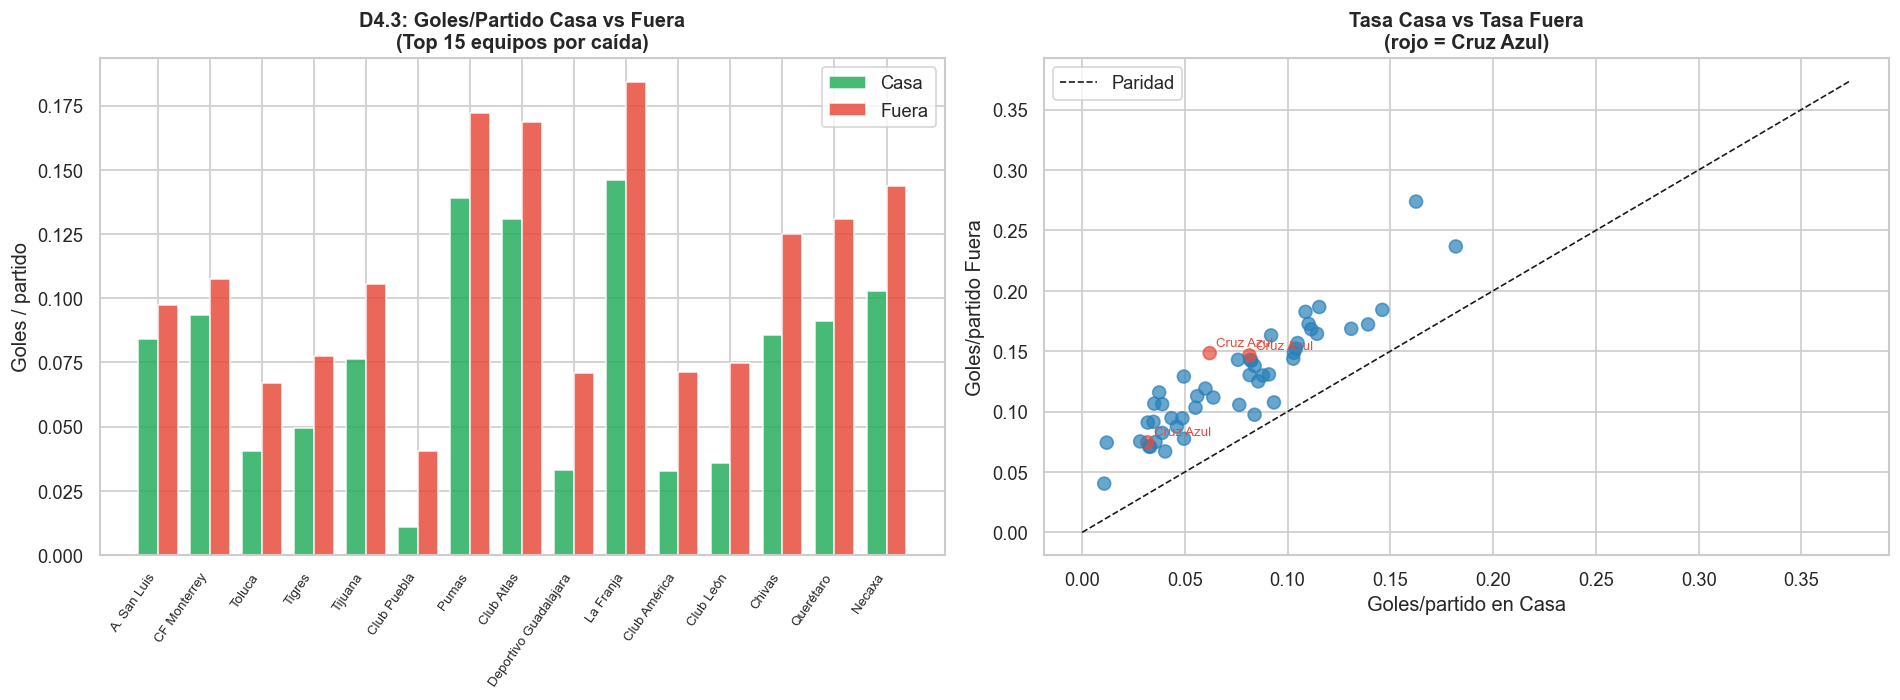

=== D4.3: TASA GOLEADORA CASA vs FUERA POR EQUIPO ===
               equipo  goles_casa  p_casa  goles_fuera  p_fuera  tasa_casa  tasa_fuera  caida
          A. San Luis          12     143           15      154      0.084       0.097 -0.013
         CF Monterrey          14     150           17      158      0.093       0.108 -0.014
               Toluca           8     198           14      209      0.040       0.067 -0.027
               Tigres           6     121           10      129      0.050       0.078 -0.028
              Tijuana          13     170           19      180      0.076       0.106 -0.029
          Club Puebla           1      93            4       99      0.011       0.040 -0.030
                Pumas          16     115           21      122      0.139       0.172 -0.033
           Club Atlas          22     168           30      178      0.131       0.169 -0.038
Deportivo Guadalajara           7     211           16      226      0.033       0.071 -0.038
      

In [38]:
# D4.3 — Tasa goleadora casa vs fuera por equipo (XLSX)
if col_gc and col_gf and col_pc and col_pf and col_equipo_x:
    x43 = df_xlsx[[col_equipo_x, col_gc, col_gf, col_pc, col_pf]].copy()
    for c in [col_gc, col_gf, col_pc, col_pf]:
        x43[c] = pd.to_numeric(x43[c], errors='coerce')
    x43 = x43.dropna()
    x43 = x43[(x43[col_pc] > 0) & (x43[col_pf] > 0)]

    eq43 = x43.groupby(col_equipo_x).agg(
        goles_casa=(col_gc, 'sum'), partidos_casa=(col_pc, 'sum'),
        goles_fuera=(col_gf, 'sum'), partidos_fuera=(col_pf, 'sum')
    ).reset_index()
    eq43.columns = ['equipo', 'goles_casa', 'p_casa', 'goles_fuera', 'p_fuera']
    eq43['tasa_casa']  = eq43['goles_casa']  / eq43['p_casa']
    eq43['tasa_fuera'] = eq43['goles_fuera'] / eq43['p_fuera']
    eq43['caida']      = eq43['tasa_casa'] - eq43['tasa_fuera']
    eq43 = eq43[eq43['p_casa'] >= 10].sort_values('caida', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ── Barras agrupadas
    top15_43 = eq43.head(15)
    x43_idx  = np.arange(len(top15_43))
    w43      = 0.38
    ax1.bar(x43_idx - w43/2, top15_43['tasa_casa'],  w43, label='Casa',    color='#27AE60', alpha=0.85)
    ax1.bar(x43_idx + w43/2, top15_43['tasa_fuera'], w43, label='Fuera',   color='#E74C3C', alpha=0.85)
    ax1.set_xticks(x43_idx)
    ax1.set_xticklabels(top15_43['equipo'], rotation=55, ha='right', fontsize=8)
    ax1.set_title('D4.3: Goles/Partido Casa vs Fuera\n(Top 15 equipos por caída)', fontweight='bold')
    ax1.set_ylabel('Goles / partido'); ax1.legend()

    # ── Scatter tasa_casa vs tasa_fuera
    ca_mask43 = eq43['equipo'].str.contains('Cruz|Azul', case=False, na=False)
    ax2.scatter(eq43['tasa_casa'], eq43['tasa_fuera'],
                c=['#E74C3C' if m else '#2980B9' for m in ca_mask43],
                s=60, alpha=0.7)
    lim43 = max(eq43['tasa_casa'].max(), eq43['tasa_fuera'].max()) + 0.1
    ax2.plot([0, lim43], [0, lim43], 'k--', lw=1, label='Paridad')
    ax2.set_xlabel('Goles/partido en Casa'); ax2.set_ylabel('Goles/partido Fuera')
    ax2.set_title('Tasa Casa vs Tasa Fuera\n(rojo = Cruz Azul)', fontweight='bold')
    ax2.legend()
    for _, row in eq43[ca_mask43].iterrows():
        ax2.annotate('Cruz Azul', (row['tasa_casa'], row['tasa_fuera']),
                     fontsize=8, color='#E74C3C', xytext=(4, 4), textcoords='offset points')

    plt.tight_layout()
    plt.show()

    print('=== D4.3: TASA GOLEADORA CASA vs FUERA POR EQUIPO ===')
    print(eq43.sort_values('caida', ascending=False).round(3).to_string(index=False))
    ca43 = eq43[ca_mask43]
    if len(ca43) > 0:
        print(f'\nCruz Azul — Casa: {ca43.iloc[0]["tasa_casa"]:.3f} | Fuera: {ca43.iloc[0]["tasa_fuera"]:.3f}'
              f' | Caída: {ca43.iloc[0]["caida"]:.3f}')
elif not (col_gc and col_gf):
    print('Columnas goles_casa/goles_fuera no detectadas. Disponibles:', df_xlsx.columns.tolist())

---
### P4.4 — ¿Se puede predecir si un jugador recibirá tarjeta roja?
> **Método:** Clasificación binaria (tarj_roj > 0 = 1). Features: `tarj_am`, `p_casa`, `p_fuera`, `goles_casa`, `goles_fuera`. Regresión Logística + Random Forest.  
> **Evaluación:** AUC-ROC + matriz de confusión.

Distribución target: Sin roja=398 | Con roja=767
=== P4.4: PREDICCIÓN TARJETA ROJA (XLSX) ===
              precision    recall  f1-score   support

    Sin roja       0.38      0.54      0.44       100
    Con roja       0.69      0.53      0.60       192

    accuracy                           0.53       292
   macro avg       0.53      0.54      0.52       292
weighted avg       0.58      0.53      0.55       292

AUC-ROC: 0.5436


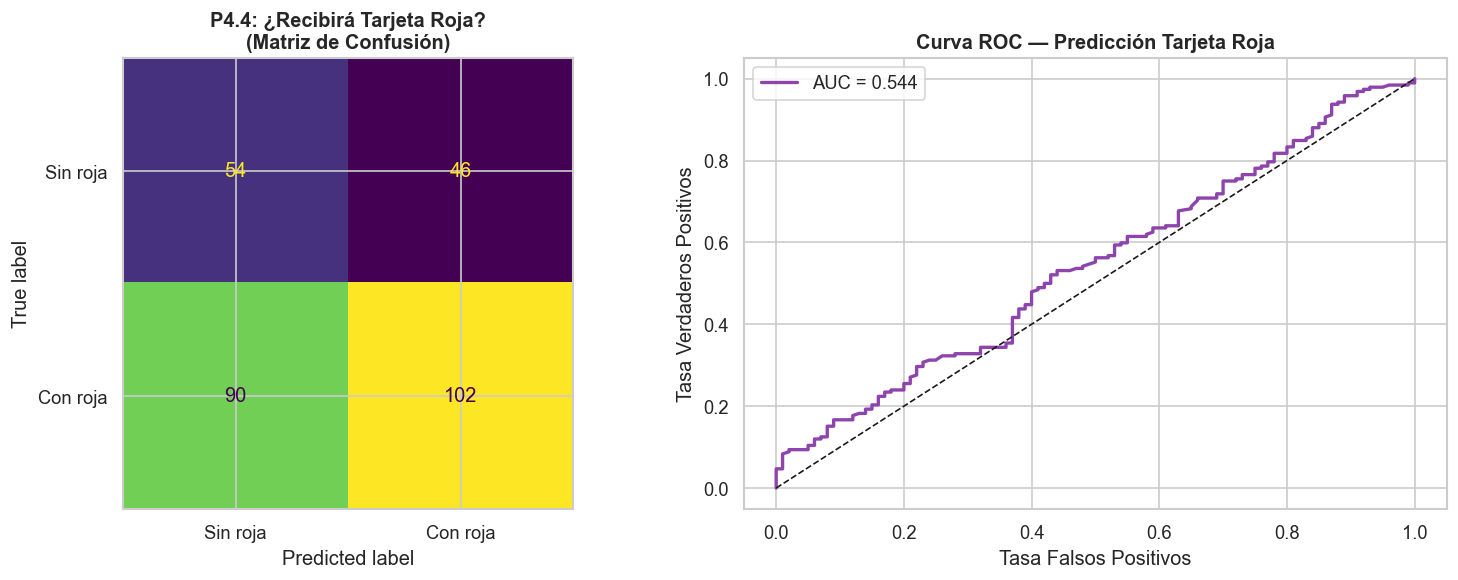


Importancia de variables:
tarj_am        0.2799
p_fuera        0.2249
p_casa         0.1852
goles_fuera    0.1735
goles_casa     0.1364


In [39]:
# P4.4 — Predicción de tarjeta roja (XLSX)
feats44_cols = [c for c in [col_tam, col_pc, col_pf, col_gc, col_gf] if c is not None]

if col_troj and len(feats44_cols) >= 2:
    x44 = df_xlsx[feats44_cols + [col_troj]].copy()
    for c in feats44_cols + [col_troj]:
        x44[c] = pd.to_numeric(x44[c], errors='coerce')
    x44 = x44.dropna()
    x44['target'] = (x44[col_troj] > 0).astype(int)

    X44 = x44[feats44_cols].values
    y44 = x44['target'].values

    print(f'Distribución target: Sin roja={( y44==0).sum()} | Con roja={(y44==1).sum()}')

    X44_tr, X44_te, y44_tr, y44_te = train_test_split(X44, y44, test_size=0.25,
                                                        random_state=42, stratify=y44)
    rf44 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42,
                                   class_weight='balanced')
    rf44.fit(X44_tr, y44_tr)
    y44_pred = rf44.predict(X44_te)
    y44_prob = rf44.predict_proba(X44_te)[:, 1]
    auc44    = roc_auc_score(y44_te, y44_prob)

    print('=== P4.4: PREDICCIÓN TARJETA ROJA (XLSX) ===')
    print(classification_report(y44_te, y44_pred, target_names=['Sin roja', 'Con roja']))
    print(f'AUC-ROC: {auc44:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    cm44 = confusion_matrix(y44_te, y44_pred)
    ConfusionMatrixDisplay(cm44, display_labels=['Sin roja', 'Con roja']).plot(ax=ax1, colorbar=False)
    ax1.set_title('P4.4: ¿Recibirá Tarjeta Roja?\n(Matriz de Confusión)', fontweight='bold')

    fpr44, tpr44, _ = roc_curve(y44_te, y44_prob)
    ax2.plot(fpr44, tpr44, color='#8E44AD', lw=2, label=f'AUC = {auc44:.3f}')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1)
    ax2.set_xlabel('Tasa Falsos Positivos'); ax2.set_ylabel('Tasa Verdaderos Positivos')
    ax2.set_title('Curva ROC — Predicción Tarjeta Roja', fontweight='bold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    imp44 = pd.Series(rf44.feature_importances_, index=feats44_cols).sort_values(ascending=False)
    print('\nImportancia de variables:')
    print(imp44.round(4).to_string())
else:
    print('Columnas de tarjetas insuficientes:', df_xlsx.columns.tolist())

---
### PR4.5 — ¿Qué jugadores externos a Cruz Azul tienen mejor rendimiento ofensivo en visita?
> **Método:** Calcular `tasa_goles_visita = goles_fuera / p_fuera` por jugador. Filtrar jugadores con al menos 5 partidos fuera, excluir los de Cruz Azul. Índice combinado con tasa_goles_visita y tasa_goles_total.  
> **Prescripción:** Top 10 refuerzos ofensivos para mejorar el rendimiento de Cruz Azul como visitante.

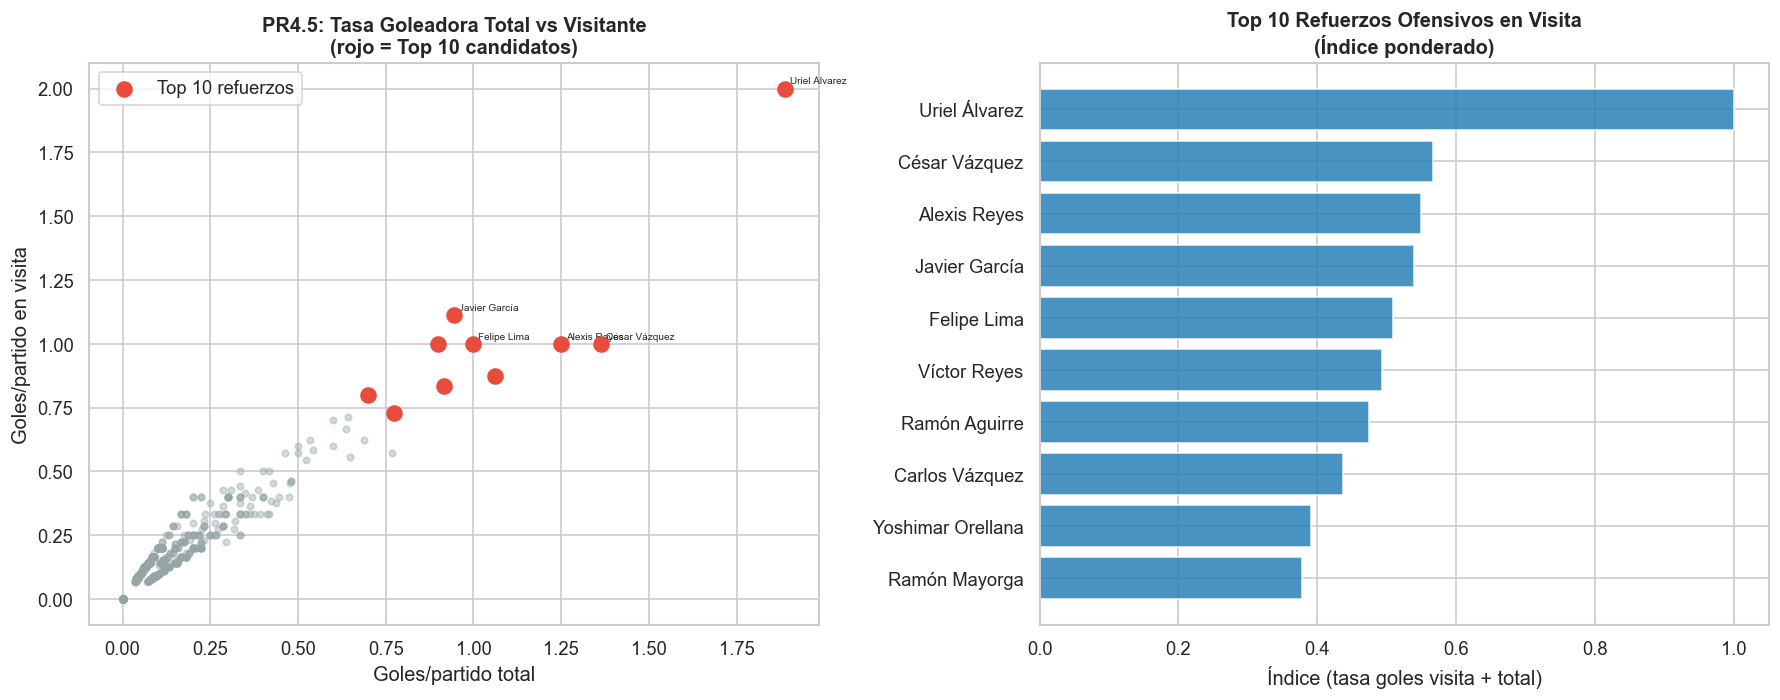

=== PR4.5: TOP 10 REFUERZOS OFENSIVOS PARA CRUZ AZUL (RENDIMIENTO VISITANTE) ===
(Jugadores con ≥5 partidos fuera, excluidos los de Cruz Azul)

        nombre_tm           equipo  goles_casa  p_casa  goles_fuera  p_fuera  tasa_goles_visita  indice_visita
    Uriel Álvarez       Club Atlas           7       4           10        5              2.000          1.000
    César Vázquez        La Franja           9       5            6        6              1.000          0.567
     Alexis Reyes      Mazatlán FC           9       6            6        6              1.000          0.549
    Javier García        FC Juárez           7       9           10        9              1.111          0.539
      Felipe Lima      Guadalajara           5       5            6        6              1.000          0.509
     Víctor Reyes     Querétaro FC           4       5            5        5              1.000          0.493
    Ramón Aguirre      Tigres UANL          10       8            7        8   

In [40]:
# PR4.5 — Mejores refuerzos ofensivos en visita para Cruz Azul (XLSX)
nombre_x_col = next((c for c in df_xlsx.columns if 'nombre' in c.lower() and 'tm' in c.lower()), None)
if nombre_x_col is None:
    nombre_x_col = next((c for c in df_xlsx.columns if 'nombre' in c.lower()), None)

if col_gf and col_pf and col_equipo_x:
    x45 = df_xlsx.copy()
    for c in [col_gf, col_pf, col_gc, col_pc]:
        if c:
            x45[c] = pd.to_numeric(x45[c], errors='coerce')
    x45 = x45.dropna(subset=[col_gf, col_pf])
    x45 = x45[(x45[col_pf] >= 5)]  # al menos 5 partidos fuera

    # Excluir Cruz Azul
    x45 = x45[~x45[col_equipo_x].str.contains('Cruz|Azul|T001', case=False, na=False)]

    x45['tasa_goles_visita'] = x45[col_gf] / x45[col_pf]
    if col_gc and col_pc:
        x45 = x45[x45[col_pc] > 0]
        x45['tasa_goles_total'] = (x45[col_gc].fillna(0) + x45[col_gf]) / \
                                   (x45[col_pc].fillna(0) + x45[col_pf])
    else:
        x45['tasa_goles_total'] = x45['tasa_goles_visita']

    # Índice: 70% visita + 30% total
    sc45 = MinMaxScaler()
    x45['tv_n'] = sc45.fit_transform(x45[['tasa_goles_visita']])
    x45['tt_n'] = sc45.fit_transform(x45[['tasa_goles_total']])
    x45['indice_visita'] = x45['tv_n'] * 0.70 + x45['tt_n'] * 0.30

    top10_v = x45.nlargest(10, 'indice_visita')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── Scatter tasa_visita vs tasa_total
    ax1.scatter(x45['tasa_goles_total'], x45['tasa_goles_visita'],
                alpha=0.4, s=15, color='#95A5A6')
    ax1.scatter(top10_v['tasa_goles_total'], top10_v['tasa_goles_visita'],
                color='#E74C3C', s=80, zorder=5, label='Top 10 refuerzos')
    ax1.set_xlabel('Goles/partido total'); ax1.set_ylabel('Goles/partido en visita')
    ax1.set_title('PR4.5: Tasa Goleadora Total vs Visitante\n(rojo = Top 10 candidatos)', fontweight='bold')
    ax1.legend()
    if nombre_x_col:
        for _, row in top10_v.head(5).iterrows():
            ax1.annotate(str(row[nombre_x_col])[:14],
                         (row['tasa_goles_total'], row['tasa_goles_visita']),
                         fontsize=6, xytext=(3, 3), textcoords='offset points')

    # ── Barras índice top 10
    top10_s = top10_v.sort_values('indice_visita')
    nombre_label = nombre_x_col if nombre_x_col else col_equipo_x
    ax2.barh(top10_s[nombre_label].astype(str),
             top10_s['indice_visita'], color='#2980B9', alpha=0.85)
    ax2.set_title('Top 10 Refuerzos Ofensivos en Visita\n(Índice ponderado)', fontweight='bold')
    ax2.set_xlabel('Índice (tasa goles visita + total)')

    plt.tight_layout()
    plt.show()

    print('=== PR4.5: TOP 10 REFUERZOS OFENSIVOS PARA CRUZ AZUL (RENDIMIENTO VISITANTE) ===')
    print('(Jugadores con ≥5 partidos fuera, excluidos los de Cruz Azul)\n')
    cols_show = [c for c in [nombre_x_col, col_equipo_x, col_gc, col_pc, col_gf, col_pf,
                              'tasa_goles_visita', 'indice_visita'] if c and c in top10_v.columns]
    disp45 = top10_v[cols_show].round(3)
    print(disp45.to_string(index=False))
    print('\nPRESCRIPCIÓN: Estos jugadores mantienen una alta producción goleadora fuera de casa.')
    print('Cruz Azul debería priorizarlos en el mercado de invierno para reforzar su ataque visitante.')
else:
    print('Columnas goles_fuera/p_fuera no detectadas:', df_xlsx.columns.tolist())